<a href="https://colab.research.google.com/github/zinniadagla/tandoor-report/blob/main/tandoor_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluating the Tandoor Intervention on Winter Revenue

## SECTION 1: EXECUTIVE SUMMARY

In [188]:
# SECTION 1: EXECUTIVE SUMMARY

print("=" * 80)
print("  SECTION 1: EXECUTIVE SUMMARY")
print("=" * 80)
print("""  This report examines whether installing a tandoor at The Taste
  Restaurant & Cafe raised winter revenue, and whether the gain was large
  enough to be worth the added cost. Before the tandoor, winter revenue ran
  about 28,1% below the non-winter level, with the sharpest drop in January
  and February. The tandoor was installed to sell winter-specific items and
  lift that weak season.

  The analysis compares two baseline winters (2023 and 2024) against the
  first post-intervention winter (2025). It describes the baseline, describes
  what happened after the tandoor, tests whether the difference is larger
  than normal year-to-year variation, translates the revenue change into
  profit after the added coal and staffing cost, checks whether the result
  survives different assumptions, and projects the coming winter (2026).

  Main result:
  Mean daily winter revenue rose from ₹7.684 in the pooled baseline to
  ₹9.341 in Winter 2025, a mean difference of about ₹1.657 per operating day
  (+21,6%). A Welch t-test gives t = 5,1304 (p < 0,001), and Cohen's d = 0,5936,
  a medium effect. Set against the tandoor's own coal and staffing cost, the
  extra revenue leaves a net of ₹69.458 over the clean winter window.

  The seasonal gap narrowed but did not close: winter ran 28,1% below
  non-winter before the tandoor and 26,5% after. The January-February weak
  season, the main reason for the intervention, rose by ₹1.315 per day
  (+20,1%), but on its own it does not cover the tandoor's running cost.
  Under stated assumptions, Winter 2026 is projected at about ₹10.828 per day.
  The forecast is a single-step-ahead projection from one observed winter, so
  it is reported with its uncertainty rather than as a firm prediction.

  Verdict: PARTIAL HIT - the revenue rise is significant, medium in size, and
  holds under the alternative assumptions tested in Section 7, and the full
  winter is profitable overall (+₹69.458). It falls short on its narrowest
  target: the January-February weak season does not clear its own running cost,
  and the seasonal gap narrowed only slightly. The intervention succeeds on the
  whole winter; the specific season it was aimed at improved but did not
  pay for itself, while the winter as a whole did.

  Note: Winter 2025 is a single post-intervention winter (n = 1). The results
  below are consistent with a positive tandoor effect but cannot rule out
  other year-specific causes. Claims are stated as association, not proof, and
  the 2026 figure is a projection under stated assumptions, not a prediction.""")
print()
print("=" * 80)

  SECTION 1: EXECUTIVE SUMMARY
  This report examines whether installing a tandoor at The Taste
  Restaurant & Cafe raised winter revenue, and whether the gain was large
  enough to be worth the added cost. Before the tandoor, winter revenue ran
  about 28,1% below the non-winter level, with the sharpest drop in January
  and February. The tandoor was installed to sell winter-specific items and
  lift that weak season.

  The analysis compares two baseline winters (2023 and 2024) against the
  first post-intervention winter (2025). It describes the baseline, describes
  what happened after the tandoor, tests whether the difference is larger
  than normal year-to-year variation, translates the revenue change into
  profit after the added coal and staffing cost, checks whether the result
  survives different assumptions, and projects the coming winter (2026).

  Main result:
  Mean daily winter revenue rose from ₹7.684 in the pooled baseline to
  ₹9.341 in Winter 2025, a mean difference 

## SECTION 2: METHODOLOGY & DATA INTEGRITY

In [189]:
# Imports and data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats

FILE = "restaurant_data.xlsx"
daily_sales = pd.read_excel(FILE, sheet_name="daily_sales")
monthly_expenses = pd.read_excel(FILE, sheet_name="monthly_expenses")

In [190]:
# DATA CLEANING

# Daily sales
daily_sales.columns = [c.strip() for c in daily_sales.columns]

# the sheet repeats its header as a data row; drop it before type conversion
daily_sales = daily_sales[daily_sales["date"] != "date"].copy()

daily_sales["date"] = pd.to_datetime(daily_sales["date"], errors="coerce")
daily_sales["revenue"] = pd.to_numeric(daily_sales["revenue"], errors="coerce")
daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month_num"] = daily_sales["date"].dt.month
daily_sales["day_name"] = daily_sales["day"].str.strip().str.capitalize()
# closed days have no revenue, so a missing value marks a closure
daily_sales["is_closed"] = daily_sales["revenue"].isna()

# Monthly expenses
monthly_expenses.columns = [c.strip() for c in monthly_expenses.columns]
monthly_expenses = monthly_expenses[monthly_expenses["month"] != "month"].copy()

# short names so the expense columns are easier to reference later
monthly_expenses = monthly_expenses.rename(columns={
    "food costing": "food_cost",
    "labour costing": "labour_cost",
    "utility and maintenance": "utility_maint",
    "GST Tax": "gst_tax",
    "ttl expenses": "total_expenses",
})

monthly_expenses["month"] = pd.to_datetime(monthly_expenses["month"], errors="coerce")
monthly_expenses["year"] = monthly_expenses["month"].dt.year
monthly_expenses["month_num"] = monthly_expenses["month"].dt.month

print("Data cleaning complete.")
print(f"  Closed days (non-operating) : {daily_sales['is_closed'].sum()}")
print(f"  Operating days              : {(~daily_sales['is_closed']).sum()}")
print(f"  Expense columns             : {list(monthly_expenses.columns)}")
print(f"  Date range                  : {daily_sales['date'].min().date()} to {daily_sales['date'].max().date()}")


Data cleaning complete.
  Closed days (non-operating) : 27
  Operating days              : 1220
  Expense columns             : ['month', 'food_cost', 'labour_cost', 'utility_maint', 'gst_tax', 'total_expenses', 'year', 'month_num']
  Date range                  : 2023-01-01 to 2026-05-31


In [191]:
# CONSTANTS AND HELPER FUNCTIONS

# tandoor was activated 27 Oct 2025; winter analysis starts 1 Nov
INTERVENTION_DATE = pd.Timestamp("2025-10-27")

WINTER_MONTHS = [11, 12, 1, 2]

# Diwali windows (per owner specification)
DIWALI_WINDOWS = {
    2023: (pd.Timestamp("2023-11-10"), pd.Timestamp("2023-11-14")),
    2024: (pd.Timestamp("2024-10-30"), pd.Timestamp("2024-11-03")),
    2025: (pd.Timestamp("2025-10-18"), pd.Timestamp("2025-10-23")),
    2026: (pd.Timestamp("2026-11-06"), pd.Timestamp("2026-11-10")),
}

# Sunday first, to match the restaurant's week
DAY_ORDER = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

ALPHA = 0.05

# European number formatting (thousands = period, decimal = comma)
def fmt(value, decimals=0):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "N/A"
    if decimals == 0:
        s = f"{value:,.0f}"
    else:
        s = f"{value:,.{decimals}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")

print("Constants and helper functions defined.")
print(f"Number formatting ready: ₹{fmt(1234567)} | ₹{fmt(9876.5, 2)}")

Constants and helper functions defined.
Number formatting ready: ₹1.234.567 | ₹9.876,50


In [192]:
# SECTION 2.1 TO 2.4: DATA INTEGRITY

print("=" * 70)
print("  SECTION 2: METHODOLOGY & DATA INTEGRITY")
print("=" * 70)

# 2.1 Data Completeness
total_rows = len(daily_sales)
closed_rows = daily_sales["is_closed"].sum()
operating_rows = total_rows - closed_rows
completeness = (operating_rows / total_rows) * 100

print("\n  2.1  Data Completeness")
print("  " + "-" * 65)
print(f"  Total calendar days in dataset   : {fmt(total_rows):>5}")
print(f"  Closed days (non-operating)      : {fmt(closed_rows):>5}")
print(f"  Operating days (revenue recorded): {fmt(operating_rows):>5}")
print(f"  Completeness rate                : {fmt(completeness, 1)}%")
print("""\n  Closed days represent operational closures when staff were
  given rest before or after high-volume festival periods. All festival
  days themselves (including Diwali) appear as operating days with
  elevated revenue. The distinction matters because the restaurant's
  closure pattern is strategic staffing, not holidays.""")
print()

# 2.2 Closed days by year
print("\n  2.2  Closed Days by Calendar Year")
print("  " + "-" * 60)
print(f"  {'Year':<8} {'Calendar Days':>14} {'Closed Days':>13} {'Operating Days':>16}")
print("  " + "-" * 60)
for yr in sorted(daily_sales["year"].unique()):
    cal = daily_sales[daily_sales["year"] == yr].shape[0]
    closed = daily_sales[(daily_sales["year"] == yr) & daily_sales["is_closed"]].shape[0]
    op = cal - closed
    print(f"  {yr:<8} {fmt(cal):>14} {fmt(closed):>13} {fmt(op):>16}")
print()

# 2.3 Date coverage
print("\n  2.3  Date Coverage")
print("  " + "-" * 60)
print(f"  From : {daily_sales['date'].min().strftime('%d %b %Y')}")
print(f"  To   : {daily_sales['date'].max().strftime('%d %b %Y')}")
print(f"  Span : {fmt((daily_sales['date'].max() - daily_sales['date'].min()).days)} calendar days")
print()

# 2.4 Duplicate check
dup_sales = daily_sales.duplicated(subset="date").sum()
dup_expenses = monthly_expenses.duplicated(subset="month").sum()

print("\n  2.4  Duplicate Records Check")
print("  " + "-" * 60)
print(f"  daily_sales duplicates      : {dup_sales}")
print(f"  monthly_expenses duplicates : {dup_expenses}")
print()

  SECTION 2: METHODOLOGY & DATA INTEGRITY

  2.1  Data Completeness
  -----------------------------------------------------------------
  Total calendar days in dataset   : 1.247
  Closed days (non-operating)      :    27
  Operating days (revenue recorded): 1.220
  Completeness rate                : 97,8%

  Closed days represent operational closures when staff were
  given rest before or after high-volume festival periods. All festival
  days themselves (including Diwali) appear as operating days with
  elevated revenue. The distinction matters because the restaurant's
  closure pattern is strategic staffing, not holidays.


  2.2  Closed Days by Calendar Year
  ------------------------------------------------------------
  Year      Calendar Days   Closed Days   Operating Days
  ------------------------------------------------------------
  2023                365             9              356
  2024                366             7              359
  2025                365       

In [193]:
# SECTION 2.5 TO 2.6: DEFINITIONS AND CONTEXT

# 2.5 Winter window definition
print("\n  2.5  Winter Window Definition")
print("  " + "-" * 70)
print("""  Winter is defined as November through February, spanning two
  calendar years. This reflects the restaurant's observed seasonal
  revenue cycle, in which March to October generate higher daily revenue
  than the November to February period.

  Winter revenue is lower than the rest of the year. Inside winter,
  November and December are the better months, because Diwali falls in
  November and Christmas and New Year fall in December. These festivals
  bring extra customers. January and February are weaker and have no
  such support, so in a normal year November and December carry the
  winter season.

  Diwali does not fall on the same dates every year. In Winter 2025 it
  fell fully in October, before the winter window, so that year November
  lost its usual festival support and the winter dip could spread across
  the full season instead of being softened by Diwali. The tandoor was
  installed to support revenue across the whole winter. Because Winter
  2025 had no Diwali inside the window, it also gives a clean before-and-
  after comparison, since the baseline years and Winter 2025 can both be
  compared on non-Diwali days.

  Convention used throughout this report:
    Winter 2023 = November to December 2023 + January to February 2024
    Winter 2024 = November to December 2024 + January to February 2025
    Winter 2025 = November to December 2025 + January to February 2026
    Winter 2026 = November to December 2026 + January to February 2027 (forecast)

  The tandoor was activated on 27 October 2025. All analysis of the
  intervention effect is restricted to the winter window (November
  onwards) to keep the before-after comparison clean.

  Note: 2024 is a leap year; February 2024 contains 29 days, making
  Winter 2023 a 121-day calendar window rather than the standard 120 days.""")
print()


# 2.6 Diwali treatment
print("\n  2.6  Diwali Treatment")
print("  " + "-" * 70)
print("""  Diwali generates a distinct revenue spike unrelated to the tandoor
  and also drives sales for a few days before and after the festival.
  It is treated as a confound and handled as follows:

    Winter 2023 - Diwali: 10 to 14 Nov 2023 (5 days within winter window)
    Winter 2024 - Diwali: 30 Oct to 3 Nov 2024; only 1 to 3 Nov fall in winter
                          (3 days within winter window)
    Winter 2025 - Diwali: 18 to 23 Oct 2025, entirely before Nov 1
                          (0 days within winter window, cleaner test)
    Winter 2026 - Diwali: 6 to 10 Nov 2026, entirely within winter window
                          (5 days within winter window, adjustment needed)

  Two sets of baseline metrics are calculated:
    Table A - Full winter (Diwali days included): captures business reality
    Table B - Non-Diwali winter (Diwali days excluded): primary baseline
               used for statistical comparison with Winter 2025, which
               contains no Diwali effect by definition.

  The Diwali Premium (mean Diwali revenue minus non-Diwali baseline) is
  calculated separately and used for the Winter 2026 forecast in Section 8.

  Diwali 2024: 30 October to 3 November. Only 1 to 3 November fall within
  the winter window; 30 and 31 October fall just outside. Only for the Diwali
  premium calculation, we use the full festival period (five days) to
  estimate the complete festival effect. This gives a fuller estimate
  for the Winter 2026 forecast, when Diwali (6 to 10 November) falls
  entirely within the winter window. All the remaining calculations use
  the Diwali days falling in the winter window, therefore 1 to 3 Nov.""")
print()


  2.5  Winter Window Definition
  ----------------------------------------------------------------------
  Winter is defined as November through February, spanning two
  calendar years. This reflects the restaurant's observed seasonal
  revenue cycle, in which March to October generate higher daily revenue
  than the November to February period.

  Winter revenue is lower than the rest of the year. Inside winter,
  November and December are the better months, because Diwali falls in
  November and Christmas and New Year fall in December. These festivals
  bring extra customers. January and February are weaker and have no
  such support, so in a normal year November and December carry the
  winter season.

  Diwali does not fall on the same dates every year. In Winter 2025 it
  fell fully in October, before the winter window, so that year November
  lost its usual festival support and the winter dip could spread across
  the full season instead of being softened by Diwali. The tandoor 

In [194]:
# 2.7 Operational context
print("\n  2.7  Operational & Financial Context")
print("  " + "-" * 60)
print("""  Restaurant  : The Taste Restaurant & Cafe - fully vegetarian
  Location    : Tandoor placed at building entrance (visible from street)
                as shown in figure 1.
  Marketing   : No paid marketing was conducted for the tandoor. Customer
                awareness came from the physical placement of the tandoor
                at the restaurant entrance, where passing customers could
                see it in operation.

  Tandoor menu function (dual role):
    Winter only: Tandoori rotis (Naan, Missi Roti, Kulcha) and parathas
                 (Lachha Paratha, Aloo Paratha, Paneer Paratha).
                 In addition, Soya chaap, paneer tikka, tandoori aloo; their demand peaks
                 November to February and becomes negligible by March to April.
                 This seasonal demand pattern is the main business case
                 for the winter intervention study.
    Year-round : Tandoori rotis and parathas, used as a substitute for
                 tawa rotis during periods when commercial LPG supply was
                 constrained.

  Equipment history:
    The tandoor was bought in 2021 for about ₹20.000 as a single unit purchase
    in a larger kitchen equipment order. It was kept idle on operational cost
    grounds until Winter 2025, when the potential revenue from winter-specific
    items justified its use. The purchase cost is treated as a sunk cost, and the
    profitability analysis (Section 6) considers only marginal operational costs.

  Expense data:
    All figures are pre-income-tax. Income tax is excluded because government
    rebate thresholds (₹7 lakh or ₹12 lakh) make tax liability inconsistent
    across years, not because of business performance.

  Currency used:
    All monetary values are reported in Indian Rupees (₹) as the restaurant operates
    completely within the Indian market (revenue, expenses, and profit). At the time
    of writing, the rate was ₹110,30 = €1,00. No currency conversion is
    applied in any calculation.

  Number Formatting:
    All numbers use European formatting: period = thousands separator, comma = decimal
    separator (e.g., ₹1.234,56 = one thousand two hundred thirty-four rupees and fifty-six paise).""")
print()





  2.7  Operational & Financial Context
  ------------------------------------------------------------
  Restaurant  : The Taste Restaurant & Cafe - fully vegetarian
  Location    : Tandoor placed at building entrance (visible from street)
                as shown in figure 1.
  Marketing   : No paid marketing was conducted for the tandoor. Customer
                awareness came from the physical placement of the tandoor
                at the restaurant entrance, where passing customers could
                see it in operation.

  Tandoor menu function (dual role):
    Winter only: Tandoori rotis (Naan, Missi Roti, Kulcha) and parathas
                 (Lachha Paratha, Aloo Paratha, Paneer Paratha).
                 In addition, Soya chaap, paneer tikka, tandoori aloo; their demand peaks
                 November to February and becomes negligible by March to April.
                 This seasonal demand pattern is the main business case
                 for the winter intervention s

![Close-up of the tandoor at the restaurant entrance, in operation](images/tandoor.jpg)

**Figure 1:** Close-up of the tandoor at the restaurant entrance, in operation, with the tandoor chef working behind the counter. The placement and visibility are described in Section 2.7.

In [195]:
# SECTION 2.8: PRE-INTERVENTION SEASONAL PATTERN

# Pooled seasonal pattern across the two baseline winters (2023 and 2024).
# Winter YYYY = Nov-Dec of that year + Jan-Feb of the next, matching the
# convention in Section 2.5. Diwali days are excluded from winter; non-winter
# is Mar-Oct operating days of the same start year.

winter_parts = []
for yr in [2023, 2024]:
    nov_dec = daily_sales[
        (daily_sales["year"] == yr) &
        (daily_sales["month_num"].isin([11, 12])) &
        ~daily_sales["is_closed"]
    ].copy()
    jan_feb = daily_sales[
        (daily_sales["year"] == yr + 1) &
        (daily_sales["month_num"].isin([1, 2])) &
        ~daily_sales["is_closed"]
    ].copy()
    w = pd.concat([nov_dec, jan_feb], ignore_index=True)
    if yr in DIWALI_WINDOWS:
        dw_start, dw_end = DIWALI_WINDOWS[yr]
        w = w[~w["date"].between(dw_start, dw_end)]
    winter_parts.append(w)
winter_pre = pd.concat(winter_parts, ignore_index=True)["revenue"]

non_winter_pre = daily_sales[
    daily_sales["year"].isin([2023, 2024]) &
    (daily_sales["month_num"].isin([3, 4, 5, 6, 7, 8, 9, 10])) &
    ~daily_sales["is_closed"]
]["revenue"]

non_winter_avg = non_winter_pre.mean()
winter_avg = winter_pre.mean()
seasonal_gap = ((non_winter_avg - winter_avg) / non_winter_avg) * 100

print("\n  2.8  Pre-Intervention Seasonal Revenue Pattern (2023-2024)")
print("  " + "-" * 65)
print(f"  Average daily revenue - Non-Winter (Mar-Oct) : ₹{fmt(non_winter_avg)}")
print(f"  Average daily revenue - Winter    (Nov-Feb)  : ₹{fmt(winter_avg)}")
print(f"  Winter shortfall vs non-winter               : {fmt(seasonal_gap, 1)}%")
print()
print("  This confirms the seasonal revenue problem that motivated the")
print("  tandoor intervention. Winter revenue runs approximately")
print(f"  {fmt(seasonal_gap, 0)}% below the non-winter baseline, a gap of")
print(f"  ₹{fmt(non_winter_avg - winter_avg)} per operating day.")
print()
print("""  Winter is the weakest season of the year. Within winter, November
  and December stay higher because Diwali falls in November and
  Christmas and New Year fall in December. January and February have
  no such support, which makes them the weakest months of the whole
  year, with January the lowest. The effect of the tandoor on these
  weak Jan-Feb months is examined in Section 4.4, and the change in
  the overall seasonal gap after the tandoor in Section 4.5.""")
print()
print("""  Note: This is a broad seasonal indicator combining post-Diwali
  demand contraction with winter-specific operational challenges.
  It is not intended as a precise causal estimate but as
  justification for the winter-focused intervention.""")
print()



  2.8  Pre-Intervention Seasonal Revenue Pattern (2023-2024)
  -----------------------------------------------------------------
  Average daily revenue - Non-Winter (Mar-Oct) : ₹10.688
  Average daily revenue - Winter    (Nov-Feb)  : ₹7.684
  Winter shortfall vs non-winter               : 28,1%

  This confirms the seasonal revenue problem that motivated the
  tandoor intervention. Winter revenue runs approximately
  28% below the non-winter baseline, a gap of
  ₹3.004 per operating day.

  Winter is the weakest season of the year. Within winter, November
  and December stay higher because Diwali falls in November and
  Christmas and New Year fall in December. January and February have
  no such support, which makes them the weakest months of the whole
  year, with January the lowest. The effect of the tandoor on these
  weak Jan-Feb months is examined in Section 4.4, and the change in
  the overall seasonal gap after the tandoor in Section 4.5.

  Note: This is a broad seasonal indi

In [196]:
# WINTER SEGMENTATION FUNCTION
# One reusable function so the same slice logic is not repeated per winter.

def get_winter_operating(year_start):
    """
    Return operating-day DataFrame for one winter season.
    Winter YYYY = Nov-Dec of year_start + Jan-Feb of (year_start + 1).
    Excludes closed days (NaN revenue). Tags Diwali days using DIWALI_WINDOWS.
    """
    nov_dec = daily_sales[
        (daily_sales["year"]  == year_start) &
        (daily_sales["month_num"].isin([11, 12])) &
        ~daily_sales["is_closed"]
    ].copy()

    jan_feb = daily_sales[
        (daily_sales["year"]  == year_start + 1) &
        (daily_sales["month_num"].isin([1, 2])) &
        ~daily_sales["is_closed"]
    ].copy()

    df = pd.concat([nov_dec, jan_feb], ignore_index=True)
    df["is_diwali"] = False
    if year_start in DIWALI_WINDOWS:
        dw_start, dw_end = DIWALI_WINDOWS[year_start]
        df["is_diwali"] = df["date"].between(dw_start, dw_end)
    return df

w2023 = get_winter_operating(2023)
w2024 = get_winter_operating(2024)
w2025 = get_winter_operating(2025)

print("Winter slices built:")
print(f"  Winter 2023 : {len(w2023):>3} operating days | Diwali days: {w2023['is_diwali'].sum()}")
print(f"  Winter 2024 : {len(w2024):>3} operating days | Diwali days: {w2024['is_diwali'].sum()}")
print(f"  Winter 2025 : {len(w2025):>3} operating days | Diwali days: {w2025['is_diwali'].sum()} "
      f"(Diwali fell before Nov 1)")

Winter slices built:
  Winter 2023 : 116 operating days | Diwali days: 5
  Winter 2024 : 117 operating days | Diwali days: 3
  Winter 2025 : 117 operating days | Diwali days: 0 (Diwali fell before Nov 1)


## SECTION 3: DESCRIPTIVE BASELINE (WINTERS 2023 & 2024)

In [197]:
# DESCRIPTIVE METRICS FUNCTION

def describe_winter(df, label):
    """
    Compute descriptive metrics for one winter revenue series.
    Returns a dict of metrics; caller decides how to print or store them.
    """
    rev = df["revenue"].dropna()
    return {
        "label"  : label,
        "n_days" : len(rev),
        "mean"   : rev.mean(),
        "median" : rev.median(),
        "sd"     : rev.std(ddof=1),
        "cv"     : rev.std(ddof=1) / rev.mean() * 100,
        "p25"    : rev.quantile(0.25),
        "p75"    : rev.quantile(0.75),
        "total"  : rev.sum(),
    }

In [198]:
# SECTION 3: DESCRIPTIVE BASELINE (WINTERS 2023 & 2024)

# non-Diwali subsets are the baseline used for the statistical tests later
w2023_nd = w2023[~w2023["is_diwali"]]
w2024_nd = w2024[~w2024["is_diwali"]]
w_comb = pd.concat([w2023_nd, w2024_nd], ignore_index=True)

m_23_full = describe_winter(w2023, "Winter 2023 (Full)")
m_24_full = describe_winter(w2024, "Winter 2024  (Full)")
m_23_nd = describe_winter(w2023_nd, "Winter 2023  (Non-Diwali)")
m_24_nd = describe_winter(w2024_nd, "Winter 2024  (Non-Diwali)")
m_comb = describe_winter(w_comb, "Combined 2023+2024  (Non-Diwali)")

# Diwali revenue is taken from daily_sales, not the winter slices. For 2024 the
# winter slice omits 30-31 Oct, so querying daily_sales recovers the full 5-day
# festival and gives a fuller premium for the Winter 2026 forecast, where Diwali
# (6-10 Nov) falls fully inside the window.
dw_2023_start, dw_2023_end = DIWALI_WINDOWS[2023]
dw_2024_start, dw_2024_end = DIWALI_WINDOWS[2024]

full_diwali_2023 = daily_sales[
    daily_sales["date"].between(dw_2023_start, dw_2023_end) &
    ~daily_sales["is_closed"]
]
full_diwali_2024 = daily_sales[
    daily_sales["date"].between(dw_2024_start, dw_2024_end) &
    ~daily_sales["is_closed"]
]

diwali_mean_23 = full_diwali_2023["revenue"].mean()
diwali_mean_24 = full_diwali_2024["revenue"].mean()

# day-of-week averages, to check for weekend effects that predate the tandoor
dow_23 = w2023_nd.groupby("day_name")["revenue"].mean().reindex(DAY_ORDER)
dow_24 = w2024_nd.groupby("day_name")["revenue"].mean().reindex(DAY_ORDER)

exp_cols = ["food_cost", "labour_cost", "utility_maint", "gst_tax", "total_expenses"]

print()
print("=" * 70)
print("  SECTION 3: DESCRIPTIVE BASELINE (WINTERS 2023 & 2024)")
print("=" * 70)


# Table 3.1: Full-Winter (Diwali included)
print()
print("  TABLE 3.1  Full-Winter Metrics (Diwali days included)")
print("  " + "-" * 65)
print("  Total seasonal revenue as experienced by the business")
print()
print(f"  {'Metric':<32} {'Winter 2023':>12} {'Winter 2024':>14}")
print("  " + "-" * 65)

rows_31 = [
    ("Operating Days",             m_23_full["n_days"],  m_24_full["n_days"],  "int"),
    ("Mean Daily Revenue",         m_23_full["mean"],    m_24_full["mean"],    "money"),
    ("Median Daily Revenue",       m_23_full["median"],  m_24_full["median"],  "money"),
    ("Standard Deviation",         m_23_full["sd"],      m_24_full["sd"],      "money"),
    ("CV  (Coefficient of Var.)",  m_23_full["cv"],      m_24_full["cv"],      "pct"),
    ("P25  (Bad-day floor)",       m_23_full["p25"],     m_24_full["p25"],     "money"),
    ("P75  (Good-day ceiling)",    m_23_full["p75"],     m_24_full["p75"],     "money"),
    ("Total Winter Revenue",       m_23_full["total"],   m_24_full["total"],   "money"),
]

for label, v23, v24, typ in rows_31:
    if typ == "int":
        c23, c24 = str(int(v23)), str(int(v24))
    elif typ == "pct":
        c23 = fmt(v23, 1) + "%"
        c24 = fmt(v24, 1) + "%"
    else:
        c23 = "₹" + fmt(v23)
        c24 = "₹" + fmt(v24)
    print(f"  {label:<32} {c23:>12} {c24:>14}")

print("  " + "-" * 65)
print()


# Table 3.2: Non-Diwali (Primary comparison baseline)
print()
print("  TABLE 3.2  Non-Diwali Metrics (primary comparison baseline)")
print("  " + "-" * 65)
print("  Diwali days are excluded to isolate the underlying winter")
print("  performance. This is the baseline used for all statistical tests.")
print()
print(f"  {'Metric':<32} {'Winter 2023':>9} {'Winter 2024':>14} {'Combined':>12}")
print("  " + "-" * 75)

rows_32 = [
    ("Operating Days",             m_23_nd["n_days"],  m_24_nd["n_days"],  m_comb["n_days"],  "int"),
    ("Mean Daily Revenue",         m_23_nd["mean"],    m_24_nd["mean"],    m_comb["mean"],    "money"),
    ("Median Daily Revenue",       m_23_nd["median"],  m_24_nd["median"],  m_comb["median"],  "money"),
    ("Standard Deviation",         m_23_nd["sd"],      m_24_nd["sd"],      m_comb["sd"],      "money"),
    ("CV  (Coefficient of Var.)",  m_23_nd["cv"],      m_24_nd["cv"],      m_comb["cv"],      "pct"),
    ("P25  (Bad-day floor)",       m_23_nd["p25"],     m_24_nd["p25"],     m_comb["p25"],     "money"),
    ("P75  (Good-day ceiling)",    m_23_nd["p75"],     m_24_nd["p75"],     m_comb["p75"],     "money"),
    ("Total Revenue",              m_23_nd["total"],   m_24_nd["total"],   m_comb["total"],   "money"),
]

for label, v23, v24, vc, typ in rows_32:
    if typ == "int":
        c23, c24, cc = str(int(v23)), str(int(v24)), str(int(vc))
    elif typ == "pct":
        c23 = fmt(v23, 1) + "%"
        c24 = fmt(v24, 1) + "%"
        cc  = fmt(vc, 1) + "%"
    else:
        c23 = "₹" + fmt(v23)
        c24 = "₹" + fmt(v24)
        cc  = "₹" + fmt(vc)
    print(f"  {label:<32} {c23:>9} {c24:>14} {cc:>13}")

print("  " + "-" * 75)
print("  Combined = pooled 2023 + 2024 Non-Diwali operating days")
print()


# Table 3.3: Diwali Premium
print()
print("  TABLE 3.3  Diwali Premium (festival lift above non-Diwali baseline)")
print("  " + "-" * 70)
print("  Winter 2025 contains no Diwali days (Diwali fell in October),")
print("  which keeps the Winter 2025 comparison clean.")
print()
print(f"  {'Metric':<38} {'Winter 2023':>10} {'Winter 2024':>14}")
print("  " + "-" * 70)

premium_23 = diwali_mean_23 - m_23_nd["mean"]
premium_24 = diwali_mean_24 - m_24_nd["mean"]
avg_premium = (premium_23 + premium_24) / 2

rows_33 = [
    ("Diwali Days (full festival period)",  len(full_diwali_2023),  len(full_diwali_2024),  "int"),
    ("Mean Revenue, Diwali days",           diwali_mean_23,         diwali_mean_24,         "money"),
    ("Mean Revenue, Non-Diwali days",       m_23_nd["mean"],        m_24_nd["mean"],        "money"),
    ("Diwali Premium above baseline",       premium_23,             premium_24,             "money"),
]

for label, v23, v24, typ in rows_33:
    if typ == "int":
        c23, c24 = str(int(v23)), str(int(v24))
    else:
        c23 = "₹" + fmt(v23)
        c24 = "₹" + fmt(v24)
    print(f"  {label:<38} {c23:>10} {c24:>13}")

print("  " + "-" * 70)
print()
print(f"  The average Diwali premium of ₹{fmt(avg_premium)} per day will be")
print(f"  used in Section 8 to adjust the Winter 2026 forecast.")
print()
print("""  Note: For Diwali 2024, the full festival period (30 Oct-3 Nov, 5 days)
  is used to estimate the complete festival effect. Only 1-3 Nov fall within the
  winter window; 30-31 Oct fall just outside. The premium calculation uses the
  complete 5-day period to give a fuller estimate for the Winter 2026
  forecast, when Diwali (6-10 Nov) falls entirely within the winter window.""")
print()


# Table 3.4: Day-of-Week averages
print()
print("  TABLE 3.4  Day-of-Week Average Revenue (Non-Diwali operating days)")
print("  " + "-" * 70)
print("""  The weekend check confirms whether a day-of-week pattern already
  existed before the tandoor, so it is not later mistaken for its effect.""")
print()
print(f"  {'Day':<8} {'Winter 2023':>16} {'Winter 2024':>16} {'YoY Change':>12}")
print("  " + "-" * 60)

for day in DAY_ORDER:
    v23 = dow_23.get(day, np.nan)
    v24 = dow_24.get(day, np.nan)
    chg = (v24 - v23) / v23 * 100
    chg_str = ('+' if chg >= 0 else '') + fmt(chg, 1) + '%'
    print(f"  {day:<8} {'₹'+fmt(v23):>15} {'₹'+fmt(v24):>15} {chg_str:>10}")

print("  " + "-" * 60)
print()


# Table 3.5: Annual expense summary
print()
print("  TABLE 3.5  Annual Expense Breakdown (2023 & 2024, pre-income-tax)")
print("  " + "-" * 70)
print("  All figures are reported before income tax, consistent with the")
print("  rest of the analysis.")
print()

exp_row_labels = [
    ("Food Costing", "food_cost"),
    ("Labour Costing", "labour_cost"),
    ("Utility & Maintenance", "utility_maint"),
    ("GST / Tax", "gst_tax"),
    ("Total Expenses", "total_expenses"),
]

for yr in [2023, 2024]:
    yr_exp = monthly_expenses[monthly_expenses["year"] == yr]
    totals = yr_exp[exp_cols].sum()
    print(f"  {yr}")
    print("  " + "-" * 50)
    for label, col in exp_row_labels:
        print(f"    {label:<28} ₹{fmt(totals[col]):>10}")
    print()

print()
print("""  Note: Annual figures are calendar-year totals (January-December),
  not winter-window totals. Expense data is presented here for completeness;
  detailed profitability analysis follows in Section 6.""")
print()
print("=" * 70)


  SECTION 3: DESCRIPTIVE BASELINE (WINTERS 2023 & 2024)

  TABLE 3.1  Full-Winter Metrics (Diwali days included)
  -----------------------------------------------------------------
  Total seasonal revenue as experienced by the business

  Metric                            Winter 2023    Winter 2024
  -----------------------------------------------------------------
  Operating Days                            116            117
  Mean Daily Revenue                     ₹7.667         ₹8.356
  Median Daily Revenue                   ₹6.899         ₹7.581
  Standard Deviation                     ₹3.016         ₹3.399
  CV  (Coefficient of Var.)               39,3%          40,7%
  P25  (Bad-day floor)                   ₹5.727         ₹5.478
  P75  (Good-day ceiling)                ₹8.799        ₹10.458
  Total Winter Revenue                 ₹889.407       ₹977.620
  -----------------------------------------------------------------


  TABLE 3.2  Non-Diwali Metrics (primary comparison base

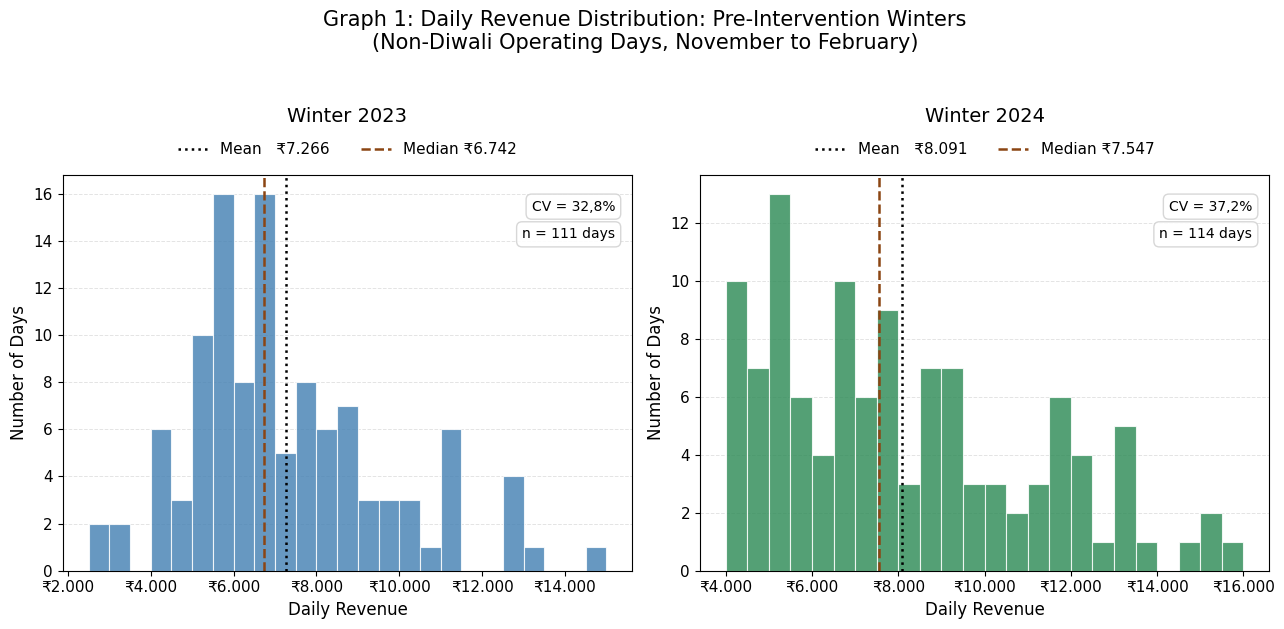


  GRAPH 1 INTERPRETATION

  Each panel shows how daily revenue was spread across the operating days of
  one baseline winter, with Diwali days left out. Both panels use the same
  ₹500 bin width, so the two shapes can be read side by side.

  Winter 2023 centres on a mean of ₹7.266 against a
  median of ₹6.742. The mean sitting a little above
  the median means a few high-revenue days raised the average, while most days
  fell below it. The CV of 32,8% over
  111 days shows the day-to-day variation was
  moderate.

  Winter 2024 moves to the right by about ₹826 a day,
  reaching a mean of ₹8.091. On its own that looks like
  healthy growth. But the CV rises too, by 4,5 points to
  37,2%. So the typical day earned more while daily
  revenue became less consistent from one day to the next. The average went up
  and the spread widened at the same time.

  This is the picture before the tandoor. Revenue was already climbing year on
  year without it, and getting less consistent as it clim

In [199]:
# GRAPH 1
# Daily revenue histograms, pre-intervention baseline (non-Diwali days)

# Small ₹-axis formatter, reused by the later graphs (defined once, like fmt)
def rupee_axis(value, _position):
    return "₹" + fmt(value)

g1_rev_2023    = w2023_nd["revenue"].dropna()
g1_rev_2024    = w2024_nd["revenue"].dropna()
g1_metric_2023 = m_23_nd
g1_metric_2024 = m_24_nd

g1_bin_width = 500     # rupees per histogram bar
g1_bin_pad   = 1.5

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

g1_panels = [
    (axes[0], g1_rev_2023, g1_metric_2023, "steelblue", "Winter 2023"),
    (axes[1], g1_rev_2024, g1_metric_2024, "seagreen",  "Winter 2024"),
]

for ax, rev_series, metric, bar_colour, panel_title in g1_panels:
    bin_edges = np.arange(
        (rev_series.min() // g1_bin_width) * g1_bin_width,
        rev_series.max() + g1_bin_width * g1_bin_pad,
        g1_bin_width,
    )
    ax.hist(rev_series, bins=bin_edges, color=bar_colour,
            edgecolor="white", linewidth=0.8, alpha=0.82)

    ax.axvline(metric["mean"], color="black", linewidth=1.8,
               linestyle=":", label="Mean   ₹" + fmt(metric["mean"]))
    ax.axvline(metric["median"], color="saddlebrown", linewidth=1.8,
               linestyle="--", label="Median ₹" + fmt(metric["median"]))

    ax.set_title(panel_title, fontsize=14, pad=38)
    ax.set_xlabel("Daily Revenue", fontsize=12)
    ax.set_ylabel("Number of Days", fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
    ax.tick_params(labelsize=11)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=11, framealpha=0.92,
              loc="lower center", bbox_to_anchor=(0.5, 1.01),
              ncol=2, frameon=False)

    ax.text(0.97, 0.92, "CV = " + fmt(metric["cv"], 1) + "%",
            transform=ax.transAxes, ha="right", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="lightgray", alpha=0.9))
    ax.text(0.97, 0.85, "n = " + str(int(metric["n_days"])) + " days",
            transform=ax.transAxes, ha="right", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="lightgray", alpha=0.9))

fig.suptitle(
    "Graph 1: Daily Revenue Distribution: Pre-Intervention Winters\n"
    "(Non-Diwali Operating Days, November to February)",
    fontsize=15, y=1.04,
)
plt.tight_layout()
plt.savefig("graph1_baseline_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

g1_mean_gap_2024 = g1_metric_2024["mean"] - g1_metric_2023["mean"]
g1_cv_gap_2024   = g1_metric_2024["cv"]   - g1_metric_2023["cv"]

print()
print("=" * 70)
print("  GRAPH 1 INTERPRETATION")
print("=" * 70)
print(f"""
  Each panel shows how daily revenue was spread across the operating days of
  one baseline winter, with Diwali days left out. Both panels use the same
  ₹{fmt(g1_bin_width)} bin width, so the two shapes can be read side by side.

  Winter 2023 centres on a mean of ₹{fmt(g1_metric_2023['mean'])} against a
  median of ₹{fmt(g1_metric_2023['median'])}. The mean sitting a little above
  the median means a few high-revenue days raised the average, while most days
  fell below it. The CV of {fmt(g1_metric_2023['cv'], 1)}% over
  {int(g1_metric_2023['n_days'])} days shows the day-to-day variation was
  moderate.

  Winter 2024 moves to the right by about ₹{fmt(g1_mean_gap_2024)} a day,
  reaching a mean of ₹{fmt(g1_metric_2024['mean'])}. On its own that looks like
  healthy growth. But the CV rises too, by {fmt(g1_cv_gap_2024, 1)} points to
  {fmt(g1_metric_2024['cv'], 1)}%. So the typical day earned more while daily
  revenue became less consistent from one day to the next. The average went up
  and the spread widened at the same time.

  This is the picture before the tandoor. Revenue was already climbing year on
  year without it, and getting less consistent as it climbed. A rise in Winter
  2025 therefore cannot be credited to the tandoor on its own. The intervention
  has to be measured against a baseline that was already moving. A real
  stability gain would have to show the spread tightening, which is the opposite
  of what these two winters do by themselves.
""")

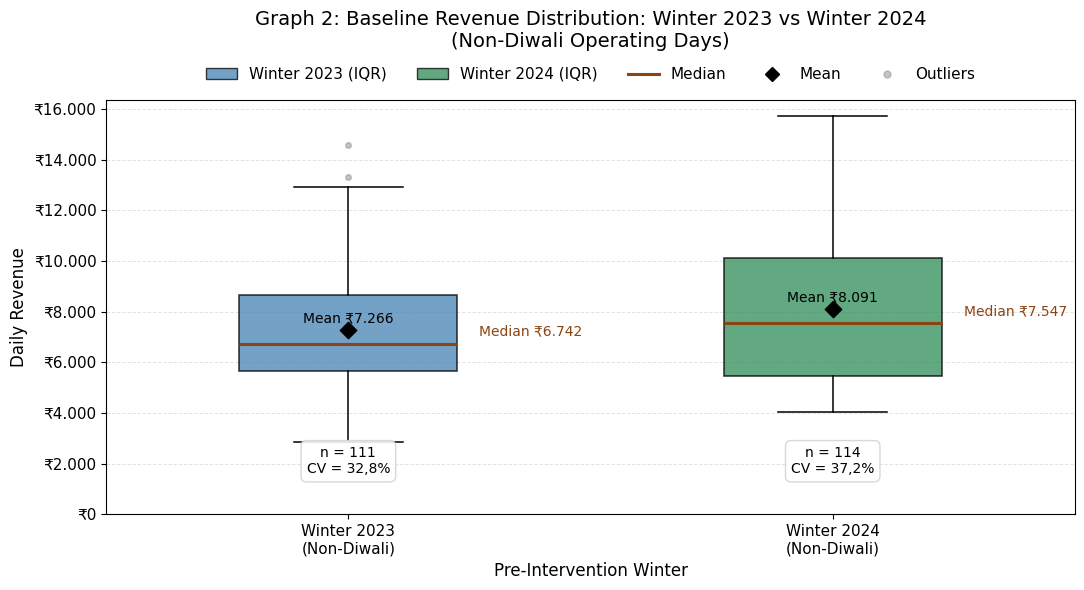


  GRAPH 2 INTERPRETATION

  This box plot looks at the same two baseline winters as Graph 1, from a
  different angle. Instead of the full histogram shape, it shows the middle
  half of each winter's days, the median line inside it, and the days that
  sat far from the rest. The mean is marked separately so it can be read
  against the median.

  In both winters the mean sits above the median, the same mild pull from a
  few strong days that Graph 1 showed. What changes between the two is the
  height of the box. The interquartile range widens from about
  ₹2.992 in Winter 2023 to about ₹4.646 in Winter
  2024, so the gap between an ordinary slow day and an ordinary busy day grew.
  This matches the CV moving from 32,8% to
  37,2%.

  The grey dots are the days that fell outside the usual range. They are not
  errors, just unusually strong days, and a box plot keeps them visible
  instead of folding them into an average.

  Read together with Graph 1, the picture is the same. The base

In [200]:
# GRAPH 2
g2_rev_2023    = w2023_nd["revenue"].dropna()
g2_rev_2024    = w2024_nd["revenue"].dropna()
g2_metric_2023 = m_23_nd
g2_metric_2024 = m_24_nd

g2_box_width   = 0.45
g2_label_pad   = 200      # vertical gap (₹) between a marker and its text
g2_median_xpad = 0.27     # horizontal gap from box centre to median label
g2_info_y      = 1500     # y-position (₹) for the n / CV info boxes

g2_positions   = [1, 2]
g2_box_labels  = ["Winter 2023\n(Non-Diwali)", "Winter 2024\n(Non-Diwali)"]
g2_box_colours = ["steelblue", "seagreen"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_axisbelow(True)

bp = ax.boxplot(
    [g2_rev_2023, g2_rev_2024],
    tick_labels=g2_box_labels,
    patch_artist=True,
    widths=g2_box_width,
    showfliers=True,
    flierprops=dict(marker="o", markersize=4, alpha=0.45,
                    markerfacecolor="gray", markeredgecolor="gray"),
)

for patch, box_colour in zip(bp["boxes"], g2_box_colours):
    patch.set_facecolor(box_colour)
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.2)
for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.1)
for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.1)
for median in bp["medians"]:
    median.set(color="saddlebrown", linewidth=2.2)

# mean diamond and the median / info labels, drawn the same way for both boxes
g2_annotations = [
    (g2_positions[0], g2_metric_2023),
    (g2_positions[1], g2_metric_2024),
]
for x_pos, metric in g2_annotations:
    ax.scatter(x_pos, metric["mean"], marker="D", s=70, color="black", zorder=5)
    ax.text(x_pos, metric["mean"] + g2_label_pad, "Mean ₹" + fmt(metric["mean"]),
            ha="center", va="bottom", fontsize=10, color="black")
    ax.text(x_pos + g2_median_xpad, metric["median"] + g2_label_pad,
            "Median ₹" + fmt(metric["median"]),
            ha="left", va="bottom", fontsize=10, color="saddlebrown")
    ax.text(x_pos, g2_info_y,
            "n = " + str(int(metric["n_days"])) + "\nCV = " + fmt(metric["cv"], 1) + "%",
            ha="center", va="bottom", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="lightgray", alpha=0.88))

ax.set_title("Graph 2: Baseline Revenue Distribution: Winter 2023 vs Winter 2024\n"
             "(Non-Diwali Operating Days)",
             fontsize=14, pad=38)
ax.set_ylabel("Daily Revenue", fontsize=12)
ax.set_xlabel("Pre-Intervention Winter", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax.tick_params(labelsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)
ax.set_ylim(bottom=0)

g2_legend = [
    Patch(facecolor="steelblue", edgecolor="black", alpha=0.75, label="Winter 2023 (IQR)"),
    Patch(facecolor="seagreen",  edgecolor="black", alpha=0.75, label="Winter 2024 (IQR)"),
    Line2D([0], [0], color="saddlebrown", linewidth=2.2, label="Median"),
    Line2D([0], [0], marker="D", color="white", markerfacecolor="black",
           markeredgecolor="black", markersize=7, label="Mean"),
    Line2D([0], [0], marker="o", color="white", markerfacecolor="gray",
           markeredgecolor="gray", markersize=5, alpha=0.45, label="Outliers"),
]
ax.legend(handles=g2_legend, fontsize=11, framealpha=0.92,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          ncol=5, frameon=False)

plt.tight_layout()
plt.savefig("graph2_baseline_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

g2_iqr_2023 = g2_metric_2023["p75"] - g2_metric_2023["p25"]
g2_iqr_2024 = g2_metric_2024["p75"] - g2_metric_2024["p25"]

print()
print("=" * 70)
print("  GRAPH 2 INTERPRETATION")
print("=" * 70)
print(f"""
  This box plot looks at the same two baseline winters as Graph 1, from a
  different angle. Instead of the full histogram shape, it shows the middle
  half of each winter's days, the median line inside it, and the days that
  sat far from the rest. The mean is marked separately so it can be read
  against the median.

  In both winters the mean sits above the median, the same mild pull from a
  few strong days that Graph 1 showed. What changes between the two is the
  height of the box. The interquartile range widens from about
  ₹{fmt(g2_iqr_2023)} in Winter 2023 to about ₹{fmt(g2_iqr_2024)} in Winter
  2024, so the gap between an ordinary slow day and an ordinary busy day grew.
  This matches the CV moving from {fmt(g2_metric_2023['cv'], 1)}% to
  {fmt(g2_metric_2024['cv'], 1)}%.

  The grey dots are the days that fell outside the usual range. They are not
  errors, just unusually strong days, and a box plot keeps them visible
  instead of folding them into an average.

  Read together with Graph 1, the picture is the same. The baseline was not
  steady before the tandoor. The centre was drifting up while the spread was
  getting wider, so Winter 2025 has to be judged against a moving, widening
  baseline, not a flat one. A real stability gain would show up here as a
  shorter box, not just a higher one.
""")

## SECTION 4: POST-INTERVENTION ANALYSIS (WINTER 2025)


In [201]:
# SECTION 4: POST-INTERVENTION ANALYSIS (WINTER 2025)

# PREREQUISITE

# m_25 is read here and again in Sections 5 and 6, so it is built once up top
m_25 = describe_winter(w2025, "Winter 2025")

print()
print("=" * 70)
print("  SECTION 4: POST-INTERVENTION ANALYSIS (WINTER 2025)")
print("=" * 70)
print("""  This section reads Winter 2025, the first winter with the tandoor,
  against the pooled Non-Diwali baseline from Section 3. It works down
  from the whole winter to the day-of-week pattern, then to the weak
  Jan-Feb months, and finally to the seasonal gap after the tandoor.""")

print()
print("  4.1  Overview")
print("  " + "-" * 70)
print("""  Winter 2025: November to December 2025 and January to February 2026.
  The tandoor was activated on 27 October 2025, five days before the
  winter window opened. All operating days in this window had the
  tandoor available. Diwali fell on 18 to 23 October, before the
  winter window. Winter 2025 revenue carries no festival uplift.""")
print()
print("  TABLE 4.1.1  Winter 2025 Metrics vs Combined Baseline")
print("  " + "-" * 73)
print("  Baseline = pooled Non-Diwali operating days, Winters 2023+2024")
print()

# computed once so the table and the text below use the same figures
mean_pct = (m_25['mean'] - m_comb['mean']) / m_comb['mean'] * 100
med_pct = (m_25['median'] - m_comb['median']) / m_comb['median'] * 100
sd_pct = (m_25['sd'] - m_comb['sd']) / m_comb['sd'] * 100
cv_diff = m_25['cv'] - m_comb['cv']
p25_pct = (m_25['p25'] - m_comb['p25']) / m_comb['p25'] * 100
p75_pct = (m_25['p75'] - m_comb['p75']) / m_comb['p75'] * 100
mean_diff_main = m_25['mean'] - m_comb['mean']

print(f"  {'Metric':<32} {'Baseline (23+24)':>15} {'Winter 2025':>13} {'Change':>9}")
print("  " + "-" * 73)

rows_411 = [
    ("Operating Days",             m_comb["n_days"],  m_25["n_days"],  "int"),
    ("Mean Daily Revenue",         m_comb["mean"],    m_25["mean"],    "money"),
    ("Median Daily Revenue",       m_comb["median"],  m_25["median"],  "money"),
    ("Standard Deviation",         m_comb["sd"],      m_25["sd"],      "money"),
    ("CV (Coefficient of Var.)",   m_comb["cv"],      m_25["cv"],      "pct"),
    ("P25 (Bad-day floor)",        m_comb["p25"],     m_25["p25"],     "money"),
    ("P75 (Good-day ceiling)",     m_comb["p75"],     m_25["p75"],     "money"),
]

for label, vbase, v25, typ in rows_411:
    if typ == "money":
        cb = "₹" + fmt(vbase)
        c25 = "₹" + fmt(v25)
        pct = (v25 - vbase) / vbase * 100 if vbase != 0 else 0
        chg = ("+" if pct >= 0 else "") + fmt(pct, 1) + "%"
    elif typ == "pct":
        cb = fmt(vbase, 1) + "%"
        c25 = fmt(v25, 1) + "%"
        chg = ("+" if v25 - vbase >= 0 else "") + fmt(v25 - vbase, 1) + "pp"
    else:  # int
        cb, c25, chg = str(int(vbase)), str(int(v25)), "-"
    print(f"  {label:<32} {cb:>14} {c25:>13} {chg:>10}")

print("  " + "-" * 73)
print()

print(f"""  Observations:
  - Median rose more than mean (+{fmt(med_pct, 1)}% vs +{fmt(mean_pct, 1)}%). The lower half of
    the distribution shifted up more than the upper half.
  - P25 rose more than P75 (+{fmt(p25_pct, 1)}% vs +{fmt(p75_pct, 1)}%). Weak days improved
    more than strong days.
  - CV fell {fmt(abs(cv_diff), 1)} percentage points. Relative variability decreased
    even though absolute variability rose slightly.""")
print()


print()
print("  4.2  Diwali Offset (Why Winter 2025 Is a Cleaner Test)")
print("  " + "-" * 70)

# bad-day rate = share of days below the baseline P25 floor. computed on the
# same formula for both periods rather than assuming the 25% P25 gives.
bad_day_rate_base = (w_comb["revenue"] < m_comb['p25']).sum() / len(w_comb) * 100
bad_day_rate_2025 = (w2025["revenue"] < m_comb['p25']).sum() / len(w2025) * 100
bad_day_reduction = bad_day_rate_base - bad_day_rate_2025

print(f"""
  Diwali (5 days) fell within the winter window in 2023 and 2024, adding
  ₹{fmt(avg_premium)} per day above the non-Diwali baseline. In Winter 2025,
  Diwali occurred on 18 to 23 October, before the winter window opened.
  No festival adjustment is needed. Revenue differences cannot be
  attributed to Diwali timing.

  Bad-day rate:
  P25 = ₹{fmt(m_comb['p25'])}. In Winter 2025, {fmt(bad_day_rate_2025, 1)}%
  of days fell below this level, a reduction of {fmt(bad_day_reduction, 1)}
  percentage points from the {fmt(bad_day_rate_base, 1)}% baseline rate.""")
print()


print()
print("  4.3  Day-of-Week Pattern")
print("  " + "-" * 70)

# day-of-week averages are used only here, so they are built in this sub-section
dow_25 = w2025.groupby("day_name")["revenue"].mean().reindex(DAY_ORDER)
dow_comb = w_comb.groupby("day_name")["revenue"].mean().reindex(DAY_ORDER)

print()
print("  TABLE 4.3.1  Day-of-Week Average Revenue: Baseline vs Winter 2025")
print("  " + "-" * 70)
print("  Baseline = pooled Non-Diwali operating days, 2023+2024")
print()
print(f"  {'Day':<8} {'Baseline':>13} {'Winter 2025':>18} {'Change':>12} {'Change (%)':>14}")
print("  " + "-" * 70)

pct_changes = []
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri"]
weekend_names = ["Sat", "Sun"]
weekday_total = 0
weekend_total = 0

for day in DAY_ORDER:
    vb = dow_comb.get(day, np.nan)
    v25 = dow_25.get(day, np.nan)
    abs_chg = v25 - vb
    pct_chg = abs_chg / vb * 100
    pct_str = ('+' if pct_chg >= 0 else '') + fmt(pct_chg, 1) + '%'
    print(f"  {day:<8} {'₹'+fmt(vb):>13} {'₹'+fmt(v25):>17} {'₹'+fmt(abs_chg):>13} {pct_str:>11}")
    pct_changes.append(pct_chg)
    if day in weekday_names:
        weekday_total = weekday_total + pct_chg
    if day in weekend_names:
        weekend_total = weekend_total + pct_chg

# DAY_ORDER matches the order pct_changes was built in, so the index lines up
min_pct = min(pct_changes)
min_day = DAY_ORDER[pct_changes.index(min_pct)]
max_pct = max(pct_changes)
max_day = DAY_ORDER[pct_changes.index(max_pct)]

weekday_avg = weekday_total / len(weekday_names)
weekend_avg = weekend_total / len(weekend_names)

print(f"""  Revenue rose on all days. The lift ranges from {fmt(min_pct, 1)}% ({min_day})
  to {fmt(max_pct, 1)}% ({max_day}). Weekends rose more on average
  ({fmt(weekend_avg, 1)}%) than weekdays ({fmt(weekday_avg, 1)}%), but weekdays
  also rose, so the gain is spread across the week and not driven by weekends
  alone.""")
print()


  SECTION 4: POST-INTERVENTION ANALYSIS (WINTER 2025)
  This section reads Winter 2025, the first winter with the tandoor,
  against the pooled Non-Diwali baseline from Section 3. It works down
  from the whole winter to the day-of-week pattern, then to the weak
  Jan-Feb months, and finally to the seasonal gap after the tandoor.

  4.1  Overview
  ----------------------------------------------------------------------
  Winter 2025: November to December 2025 and January to February 2026.
  The tandoor was activated on 27 October 2025, five days before the
  winter window opened. All operating days in this window had the
  tandoor available. Diwali fell on 18 to 23 October, before the
  winter window. Winter 2025 revenue carries no festival uplift.

  TABLE 4.1.1  Winter 2025 Metrics vs Combined Baseline
  -------------------------------------------------------------------------
  Baseline = pooled Non-Diwali operating days, Winters 2023+2024

  Metric                           Baselin

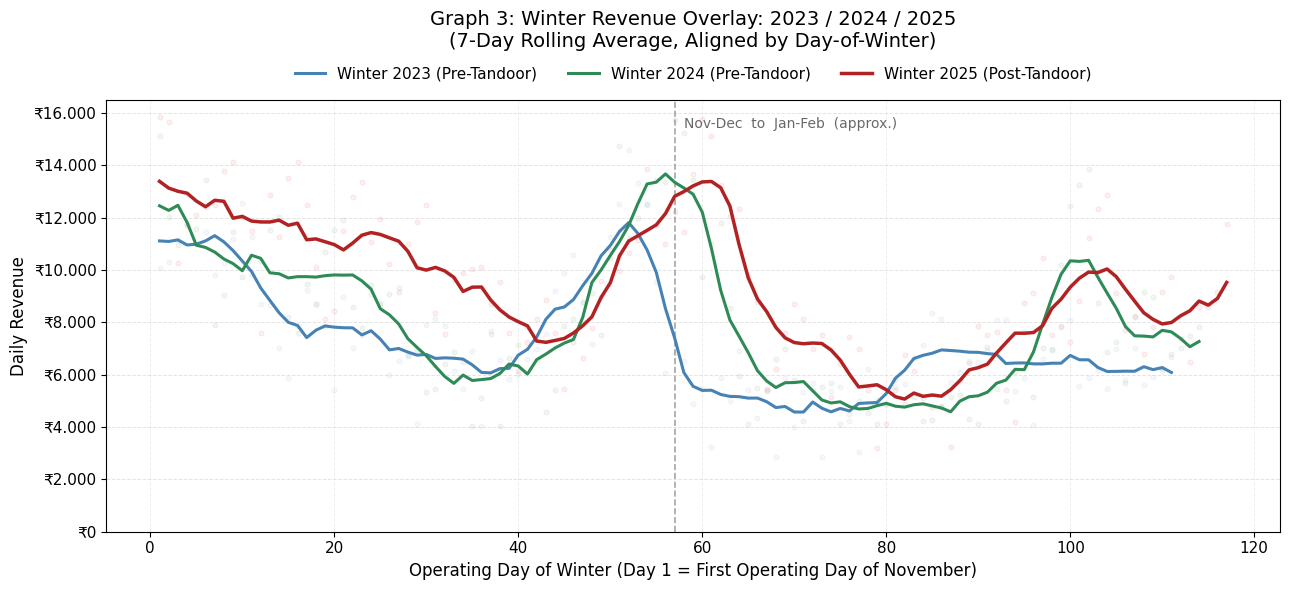


  GRAPH 3 INTERPRETATION

  This is the first time all three winters appear together. Each winter is
  lined up by its own operating day, so day one is the first November day of
  that season regardless of the calendar date. That removes the date offset, so
  what remains is a comparison of revenue level. The faint dots are the raw
  daily figures; the solid lines are a 7-day rolling average that
  smooths the day-to-day swings so the shape of each season is readable.

  Winter 2025, the post-tandoor season, is the red line. It sits above both
  pre-tandoor winters for most of the run, and on the days it dips below one of
  them it stays close. Its weakest stretch holds up better than theirs: the
  lowest point of its rolling average is about ₹5.071, against
  roughly ₹4.576 in 2023 and ₹4.585 in 2024. The
  lift at the bottom of the range matters more than the peaks here, because the
  slow days were where winter revenue was weakest.

  The dashed vertical line marks the rough move f

In [202]:
# GRAPH 3
# Three winters aligned by day-of-season, so the comparison is about
# revenue level, not calendar date.

def add_day_index(df):
    df_sorted = df.copy().sort_values("date").reset_index(drop=True)
    df_sorted["day_num"] = range(1, len(df_sorted) + 1)
    return df_sorted

g3_win_2023 = add_day_index(w2023_nd)
g3_win_2024 = add_day_index(w2024_nd)
g3_win_2025 = add_day_index(w2025)

g3_roll_window   = 7      # days in the rolling average
g3_roll_minobs   = 3      # keep the line going near the season edges
g3_scatter_size  = 12
g3_scatter_alpha = 0.12   # raw days kept faint so the rolling lines read clearly
g3_label_y_frac  = 0.96   # divider label height as a fraction of the y-axis top

# (series, line colour, line width, raw-scatter colour, legend label)
g3_series = [
    (g3_win_2023, "steelblue", 2.2, "lightsteelblue", "Winter 2023 (Pre-Tandoor)"),
    (g3_win_2024, "seagreen",  2.2, "darkseagreen",   "Winter 2024 (Pre-Tandoor)"),
    (g3_win_2025, "firebrick", 2.5, "lightcoral",     "Winter 2025 (Post-Tandoor)"),
]

for win in (g3_win_2023, g3_win_2024, g3_win_2025):
    win["roll"] = win["revenue"].rolling(
        g3_roll_window, min_periods=g3_roll_minobs, center=True).mean()

# Each winter starts January on a different day, so the divider is the average
# of the three Jan-start positions and is shown as an approximate marker only.
g3_jan_start_2023 = g3_win_2023[g3_win_2023["month_num"] == 1]["day_num"].min()
g3_jan_start_2024 = g3_win_2024[g3_win_2024["month_num"] == 1]["day_num"].min()
g3_jan_start_2025 = g3_win_2025[g3_win_2025["month_num"] == 1]["day_num"].min()
g3_jan_divider = int(round(
    (g3_jan_start_2023 + g3_jan_start_2024 + g3_jan_start_2025) / 3))

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_axisbelow(True)

# raw days at zorder 2, rolling lines at zorder 3, so no season's line is
# buried under another season's dots
for win, line_colour, line_width, scatter_colour, label in g3_series:
    ax.scatter(win["day_num"], win["revenue"],
               alpha=g3_scatter_alpha, s=g3_scatter_size, color=scatter_colour, zorder=2)
    ax.plot(win["day_num"], win["roll"],
            color=line_colour, linewidth=line_width, label=label, zorder=3)

ax.axvline(g3_jan_divider, color="gray", linewidth=1.2, linestyle="--", alpha=0.7)
g3_divider_label_y = ax.get_ylim()[1] * g3_label_y_frac
ax.text(g3_jan_divider + 1, g3_divider_label_y,
        "Nov-Dec  to  Jan-Feb  (approx.)",
        fontsize=10, color="dimgray", va="top")

ax.set_title("Graph 3: Winter Revenue Overlay: 2023 / 2024 / 2025\n"
             "(7-Day Rolling Average, Aligned by Day-of-Winter)",
             fontsize=14, pad=38)
ax.set_xlabel("Operating Day of Winter (Day 1 = First Operating Day of November)",
              fontsize=12)
ax.set_ylabel("Daily Revenue", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax.tick_params(labelsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)
ax.grid(axis="x", alpha=0.2,  linestyle="--", linewidth=0.7)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, framealpha=0.92,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("graph3_winter_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

g3_floor_2023 = g3_win_2023["roll"].min()
g3_floor_2024 = g3_win_2024["roll"].min()
g3_floor_2025 = g3_win_2025["roll"].min()

print()
print("=" * 70)
print("  GRAPH 3 INTERPRETATION")
print("=" * 70)
print(f"""
  This is the first time all three winters appear together. Each winter is
  lined up by its own operating day, so day one is the first November day of
  that season regardless of the calendar date. That removes the date offset, so
  what remains is a comparison of revenue level. The faint dots are the raw
  daily figures; the solid lines are a {g3_roll_window}-day rolling average that
  smooths the day-to-day swings so the shape of each season is readable.

  Winter 2025, the post-tandoor season, is the red line. It sits above both
  pre-tandoor winters for most of the run, and on the days it dips below one of
  them it stays close. Its weakest stretch holds up better than theirs: the
  lowest point of its rolling average is about ₹{fmt(g3_floor_2025)}, against
  roughly ₹{fmt(g3_floor_2023)} in 2023 and ₹{fmt(g3_floor_2024)} in 2024. The
  lift at the bottom of the range matters more than the peaks here, because the
  slow days were where winter revenue was weakest.

  The dashed vertical line marks the rough move from November-December into
  January-February. It is approximate, since each winter crosses into January on
  a slightly different operating day, so it is a guide rather than an exact
  boundary. To its right is the weak late-winter stretch, and that is the region
  the next graphs look at directly.

  One caution carries over from Graphs 1 and 2. The two baseline winters were
  already drifting apart in level and spread, so the fact that Winter 2025 sits
  higher is a starting observation, not proof on its own. The formal tests later
  separate a real tandoor effect from the upward drift that was already in the
  baseline.
""")

In [203]:
# SECTION 4.4: JAN-FEB WEAK SEASON ANALYSIS

# per-month series for the month-by-month table
jan_23 = w2023[w2023["month_num"] == 1]["revenue"]
feb_23 = w2023[w2023["month_num"] == 2]["revenue"]
jan_24 = w2024[w2024["month_num"] == 1]["revenue"]
feb_24 = w2024[w2024["month_num"] == 2]["revenue"]
jan_25 = w2025[w2025["month_num"] == 1]["revenue"]
feb_25 = w2025[w2025["month_num"] == 2]["revenue"]

# combined Jan-Feb per winter
jf_23 = w2023[w2023["month_num"].isin([1, 2])]["revenue"]
jf_24 = w2024[w2024["month_num"].isin([1, 2])]["revenue"]
jf_25 = w2025[w2025["month_num"].isin([1, 2])]["revenue"]

# w_comb = pooled Non-Diwali baseline from Section 3 (Winters 2023+2024)
jf_comb_rev = w_comb[w_comb["month_num"].isin([1, 2])]["revenue"]
nd_comb_rev = w_comb[w_comb["month_num"].isin([11, 12])]["revenue"]

# Winter 2025 Nov-Dec, for the internal winter gap in 4.4.4
nd_2025_rev = w2025[w2025["month_num"].isin([11, 12])]["revenue"]

# means used more than once below
jan_23_mean = jan_23.mean()
jan_24_mean = jan_24.mean()
jan_25_mean = jan_25.mean()
feb_23_mean = feb_23.mean()
feb_24_mean = feb_24.mean()
feb_25_mean = feb_25.mean()
jf_23_mean = jf_23.mean()
jf_24_mean = jf_24.mean()
jf_25_mean = jf_25.mean()
nd_comb_mean = nd_comb_rev.mean()
nd_2025_mean = nd_2025_rev.mean()

print()
print("  4.4  January-February Weak Season Analysis")
print("  " + "-" * 75)
print("""  January and February are the weakest months of the year for the
  restaurant. This sub-section examines whether the intervention had any
  effect on them.""")


print()
print("  TABLE 4.4.1  January & February Revenue (All Three Winters)")
print("  " + "-" * 75)
print()

# year-over-year growth rates
g_jan_23_24 = (jan_24_mean - jan_23_mean) / jan_23_mean * 100
g_jan_24_25 = (jan_25_mean - jan_24_mean) / jan_24_mean * 100
g_feb_23_24 = (feb_24_mean - feb_23_mean) / feb_23_mean * 100
g_feb_24_25 = (feb_25_mean - feb_24_mean) / feb_24_mean * 100
g_jf_23_24 = (jf_24_mean - jf_23_mean) / jf_23_mean * 100
g_jf_24_25 = (jf_25_mean - jf_24_mean) / jf_24_mean * 100

print(f"  {'Month':<10} {'Winter 2023':>14} {'Winter 2024':>14} {'Winter 2025':>14} {'23-24':>10} {'24-25':>10}")
print("  " + "-" * 75)

print(f"  {'January':<10} {'₹'+fmt(jan_23_mean):>14} {'₹'+fmt(jan_24_mean):>14} {'₹'+fmt(jan_25_mean):>14} {('+' if g_jan_23_24 >= 0 else '')+fmt(g_jan_23_24, 1)+'%':>10} {('+' if g_jan_24_25 >= 0 else '')+fmt(g_jan_24_25, 1)+'%':>10}")
print(f"  {'February':<10} {'₹'+fmt(feb_23_mean):>14} {'₹'+fmt(feb_24_mean):>14} {'₹'+fmt(feb_25_mean):>14} {('+' if g_feb_23_24 >= 0 else '')+fmt(g_feb_23_24, 1)+'%':>10} {('+' if g_feb_24_25 >= 0 else '')+fmt(g_feb_24_25, 1)+'%':>10}")
print("  " + "-" * 75)
print(f"  {'Jan+Feb':<10} {'₹'+fmt(jf_23_mean):>14} {'₹'+fmt(jf_24_mean):>14} {'₹'+fmt(jf_25_mean):>14} {('+' if g_jf_23_24 >= 0 else '')+fmt(g_jf_23_24, 1)+'%':>10} {('+' if g_jf_24_25 >= 0 else '')+fmt(g_jf_24_25, 1)+'%':>10}")
print("  " + "-" * 75)
print()


print()
print("  TABLE 4.4.2  Jan-Feb Per-Day Metrics (Winter 2025 vs Pooled Baseline)")
print("  " + "-" * 75)
print("  Baseline = pooled Jan-Feb operating days, 2023+2024")
print()

jf_base_mean = jf_comb_rev.mean()
jf_base_median = jf_comb_rev.median()
jf_2025_median = jf_25.median()
jf_base_sd = jf_comb_rev.std(ddof=1)
jf_2025_sd = jf_25.std(ddof=1)
jf_base_cv = jf_base_sd / jf_base_mean * 100
jf_2025_cv = jf_2025_sd / jf_25_mean * 100
cv_diff_jf = jf_2025_cv - jf_base_cv
jf_mean_pct = (jf_25_mean - jf_base_mean) / jf_base_mean * 100

print(f"  {'Metric':<38} {'Baseline':>12} {'Winter 2025':>12} {'Change':>10}")
print("  " + "-" * 75)

rows_442 = [
    ("Operating Days (Jan+Feb)", len(jf_comb_rev),  len(jf_25),      "int"),
    ("Mean Daily Revenue",       jf_base_mean,      jf_25_mean,      "money"),
    ("Median Daily Revenue",     jf_base_median,    jf_2025_median,  "money"),
    ("Standard Deviation",       jf_base_sd,        jf_2025_sd,      "money"),
    ("CV",                       jf_base_cv,        jf_2025_cv,      "pct"),
]

for label, va, vb, typ in rows_442:
    if typ == "money":
        ca, cb = "₹" + fmt(va), "₹" + fmt(vb)
        pct = (vb - va) / va * 100 if va != 0 else 0
        chg = ("+" if pct >= 0 else "") + fmt(pct, 1) + "%"
    elif typ == "pct":
        ca, cb = fmt(va, 1) + "%", fmt(vb, 1) + "%"
        chg = ("+" if vb - va >= 0 else "") + fmt(vb - va, 1) + "pp"
    else:  # int
        ca, cb, chg = str(int(va)), str(int(vb)), "-"
    print(f"  {label:<38} {ca:>12} {cb:>12} {chg:>10}")

print("  " + "-" * 75)
print()


print()
print("  TABLE 4.4.3  Jan-Feb Total Revenue by Winter (Year-over-Year)")
print("  " + "-" * 85)
print("  Each winter stands alone. Totals are scale-dependent, so they are not pooled.")
print()

total_jan_23 = jan_23.sum()
total_feb_23 = feb_23.sum()
total_jan_24 = jan_24.sum()
total_feb_24 = feb_24.sum()
total_jan_25 = jan_25.sum()
total_feb_25 = feb_25.sum()
total_jf_23 = total_jan_23 + total_feb_23
total_jf_24 = total_jan_24 + total_feb_24
total_jf_25 = total_jan_25 + total_feb_25
g_tot_jan_23_24 = (total_jan_24 - total_jan_23) / total_jan_23 * 100
g_tot_jan_24_25 = (total_jan_25 - total_jan_24) / total_jan_24 * 100
g_tot_feb_23_24 = (total_feb_24 - total_feb_23) / total_feb_23 * 100
g_tot_feb_24_25 = (total_feb_25 - total_feb_24) / total_feb_24 * 100
g_tot_jf_23_24 = (total_jf_24 - total_jf_23) / total_jf_23 * 100
g_tot_jf_24_25 = (total_jf_25 - total_jf_24) / total_jf_24 * 100

print(f"  {'Month':<12} {'Winter 2023':>16} {'Winter 2024':>16} {'Winter 2025':>16} {'23-24':>10} {'24-25':>10}")
print("  " + "-" * 85)

print(f"  {'January':<12} {'₹'+fmt(total_jan_23):>16} {'₹'+fmt(total_jan_24):>16} {'₹'+fmt(total_jan_25):>16} {('+' if g_tot_jan_23_24 >= 0 else '')+fmt(g_tot_jan_23_24, 1)+'%':>10} {('+' if g_tot_jan_24_25 >= 0 else '')+fmt(g_tot_jan_24_25, 1)+'%':>10}")
print(f"  {'February':<12} {'₹'+fmt(total_feb_23):>16} {'₹'+fmt(total_feb_24):>16} {'₹'+fmt(total_feb_25):>16} {('+' if g_tot_feb_23_24 >= 0 else '')+fmt(g_tot_feb_23_24, 1)+'%':>10} {('+' if g_tot_feb_24_25 >= 0 else '')+fmt(g_tot_feb_24_25, 1)+'%':>10}")
print("  " + "-" * 85)
print(f"  {'Jan+Feb':<12} {'₹'+fmt(total_jf_23):>16} {'₹'+fmt(total_jf_24):>16} {'₹'+fmt(total_jf_25):>16} {('+' if g_tot_jf_23_24 >= 0 else '')+fmt(g_tot_jf_23_24, 1)+'%':>10} {('+' if g_tot_jf_24_25 >= 0 else '')+fmt(g_tot_jf_24_25, 1)+'%':>10}")
print("  " + "-" * 85)
print(f"""  Operating days: Winter 2023: {len(jf_23)}, Winter 2024: {len(jf_24)}, Winter 2025: {len(jf_25)}.""")
print()


print()
print("  TABLE 4.4.4  Internal Winter Gap (Nov-Dec vs Jan-Feb)")
print("  " + "-" * 75)
print("  Baseline = pooled Non-Diwali operating days, 2023+2024")
print()

# gap between the strong months (Nov-Dec) and weak months (Jan-Feb)
winter_internal_gap_base = (nd_comb_mean - jf_base_mean) / nd_comb_mean * 100
winter_internal_gap_2025 = (nd_2025_mean - jf_25_mean) / nd_2025_mean * 100

print(f"  {'Winter':<20} {'Nov-Dec avg':>14} {'Jan-Feb avg':>14} {'Gap':>10}")
print("  " + "-" * 75)

rows_444 = [
    ("Baseline (23+24)", nd_comb_mean, jf_base_mean, winter_internal_gap_base),
    ("Winter 2025",      nd_2025_mean, jf_25_mean,   winter_internal_gap_2025),
]

for label, nd_avg, jf_avg, gap in rows_444:
    print(f"  {label:<20} {'₹'+fmt(nd_avg):>14} {'₹'+fmt(jf_avg):>14} {fmt(gap, 1)+'%':>10}")

print("  " + "-" * 75)
print("  Gap = how much lower Jan-Feb runs than Nov-Dec, within the same winter.")
print()


print()
print("  Interpretation")
print("  " + "-" * 65)

jf_abs_change = jf_25_mean - jf_base_mean

print(f"""
  The combined Jan-Feb mean rose from ₹{fmt(jf_base_mean)} (pooled baseline)
  to ₹{fmt(jf_25_mean)} in Winter 2025, an increase of
  ₹{fmt(jf_abs_change)} per day ({('+' if jf_mean_pct >= 0 else '') + fmt(jf_mean_pct, 1)}%). The weak-month
  revenue sits higher than in both prior winters.

  The CV fell from {fmt(jf_base_cv, 1)}% to
  {fmt(jf_2025_cv, 1)}%, so revenue in the weak months was not only higher
  on average but also steadier from day to day.

  On a total-revenue basis (Table 4.4.3), Jan-Feb combined revenue grew
  {('+' if g_tot_jf_23_24 >= 0 else '') + fmt(g_tot_jf_23_24, 1)}% from Winter 2023 to 2024, and a further
  {('+' if g_tot_jf_24_25 >= 0 else '') + fmt(g_tot_jf_24_25, 1)}% from Winter 2024 to 2025.

  The internal winter gap (Table 4.4.4) is almost unchanged
  ({fmt(winter_internal_gap_base, 1)}% vs {fmt(winter_internal_gap_2025, 1)}%). Nov-Dec and Jan-Feb rose by
  similar proportions, so the tandoor lifted the weak months along with the
  rest of the winter rather than closing the gap between them. This is an
  association from a single post-intervention winter, not proof on its own;
  the formal tests for the weak months follow in Section 5.7.""")
print()


  4.4  January-February Weak Season Analysis
  ---------------------------------------------------------------------------
  January and February are the weakest months of the year for the
  restaurant. This sub-section examines whether the intervention had any
  effect on them.

  TABLE 4.4.1  January & February Revenue (All Three Winters)
  ---------------------------------------------------------------------------

  Month         Winter 2023    Winter 2024    Winter 2025      23-24      24-25
  ---------------------------------------------------------------------------
  January            ₹5.781         ₹6.455         ₹7.213     +11,7%     +11,7%
  February           ₹6.567         ₹7.474         ₹8.550     +13,8%     +14,4%
  ---------------------------------------------------------------------------
  Jan+Feb            ₹6.167         ₹6.956         ₹7.870     +12,8%     +13,1%
  ---------------------------------------------------------------------------


  TABLE 4.4.2  Jan-Fe

In [204]:
# SECTION 4.5: POST-INTERVENTION SEASONAL PATTERN (WINTER 2025)

# same method as Section 2.8, extended to the post-tandoor winter so the
# seasonal gap can be read before and after on one measure.
# non-winter is Mar-Oct operating days of the start year.

nw_2023_rev = daily_sales[
    (daily_sales["year"] == 2023) &
    (daily_sales["month_num"].isin([3, 4, 5, 6, 7, 8, 9, 10])) &
    ~daily_sales["is_closed"]
]["revenue"]
nw_2024_rev = daily_sales[
    (daily_sales["year"] == 2024) &
    (daily_sales["month_num"].isin([3, 4, 5, 6, 7, 8, 9, 10])) &
    ~daily_sales["is_closed"]
]["revenue"]
nw_2025_rev = daily_sales[
    (daily_sales["year"] == 2025) &
    (daily_sales["month_num"].isin([3, 4, 5, 6, 7, 8, 9, 10])) &
    ~daily_sales["is_closed"]
]["revenue"]

# winter revenue, Diwali excluded (Diwali only tagged in Nov)
wi_2023_rev = w2023[~w2023["is_diwali"]]["revenue"]
wi_2024_rev = w2024[~w2024["is_diwali"]]["revenue"]
wi_2025_rev = w2025[~w2025["is_diwali"]]["revenue"]

nw_23_mean = nw_2023_rev.mean()
nw_24_mean = nw_2024_rev.mean()
nw_25_mean = nw_2025_rev.mean()
wi_23_mean = wi_2023_rev.mean()
wi_24_mean = wi_2024_rev.mean()
wi_25_mean = wi_2025_rev.mean()

# seasonal gap: how much lower winter runs than non-winter
gap_2023 = (nw_23_mean - wi_23_mean) / nw_23_mean * 100
gap_2024 = (nw_24_mean - wi_24_mean) / nw_24_mean * 100
gap_2025 = (nw_25_mean - wi_25_mean) / nw_25_mean * 100

# pooled baseline, same pooling as Section 2.8 so the two agree
pooled_nw_rev = pd.concat([nw_2023_rev, nw_2024_rev], ignore_index=True)
pooled_wi_rev = pd.concat([wi_2023_rev, wi_2024_rev], ignore_index=True)
pooled_nw_mean = pooled_nw_rev.mean()
pooled_wi_mean = pooled_wi_rev.mean()
gap_pooled = (pooled_nw_mean - pooled_wi_mean) / pooled_nw_mean * 100

print()
print("  4.5  Post-Intervention Seasonal Revenue Pattern (Winter 2025)")
print("  " + "-" * 60)
print("  Non-Winter = Mar-Oct operating days. Winter = Nov-Feb operating")
print("  days with Diwali excluded. Same method as Section 2.8.")
print()
print(f"  {'Winter':<20} {'Non-Winter avg':>16} {'Winter avg':>14} {'Gap':>10}")
print("  " + "-" * 65)
print(f"  {'Winter 2023':<20} {'₹'+fmt(nw_23_mean):>16} {'₹'+fmt(wi_23_mean):>14} {fmt(gap_2023, 1)+'%':>10}")
print(f"  {'Winter 2024':<20} {'₹'+fmt(nw_24_mean):>16} {'₹'+fmt(wi_24_mean):>14} {fmt(gap_2024, 1)+'%':>10}")
print(f"  {'Baseline (pooled)':<20} {'₹'+fmt(pooled_nw_mean):>16} {'₹'+fmt(pooled_wi_mean):>14} {fmt(gap_pooled, 1)+'%':>10}")
print(f"  {'Winter 2025':<20} {'₹'+fmt(nw_25_mean):>16} {'₹'+fmt(wi_25_mean):>14} {fmt(gap_2025, 1)+'%':>10}")
print("  " + "-" * 65)
print("  Gap = how much lower winter runs than non-winter, within the same year.")
print()

gap_narrowing = gap_pooled - gap_2025

print(f"""  Before the tandoor, winter ran below the rest of the year. The gap was
  {fmt(gap_2023, 1)}% in Winter 2023 and {fmt(gap_2024, 1)}% in Winter 2024, with a pooled
  baseline of {fmt(gap_pooled, 1)}%. The gap is close in both baseline years, which
  shows the seasonal problem was steady, not a one-off.

  In Winter 2025, the first winter with the tandoor, the gap narrowed to
  {fmt(gap_2025, 1)}%. Winter revenue moved closer to the non-winter level, a
  reduction of {fmt(gap_narrowing, 1)} percentage points against the pooled baseline.
  This is the seasonal problem from Section 2.8 read again after the tandoor,
  on the same measure, and it is smaller.

  Note: The non-winter side of Winter 2025 is March-October 2025, which is
  before the tandoor was activated on 27 October 2025, so it is a clean
  pre-tandoor summer level. Only the winter side carries the tandoor.""")
print()
print("=" * 70)


  4.5  Post-Intervention Seasonal Revenue Pattern (Winter 2025)
  ------------------------------------------------------------
  Non-Winter = Mar-Oct operating days. Winter = Nov-Feb operating
  days with Diwali excluded. Same method as Section 2.8.

  Winter                 Non-Winter avg     Winter avg        Gap
  -----------------------------------------------------------------
  Winter 2023                   ₹10.107         ₹7.266      28,1%
  Winter 2024                   ₹11.274         ₹8.091      28,2%
  Baseline (pooled)             ₹10.688         ₹7.684      28,1%
  Winter 2025                   ₹12.716         ₹9.341      26,5%
  -----------------------------------------------------------------
  Gap = how much lower winter runs than non-winter, within the same year.

  Before the tandoor, winter ran below the rest of the year. The gap was
  28,1% in Winter 2023 and 28,2% in Winter 2024, with a pooled
  baseline of 28,1%. The gap is close in both baseline years, which
  s

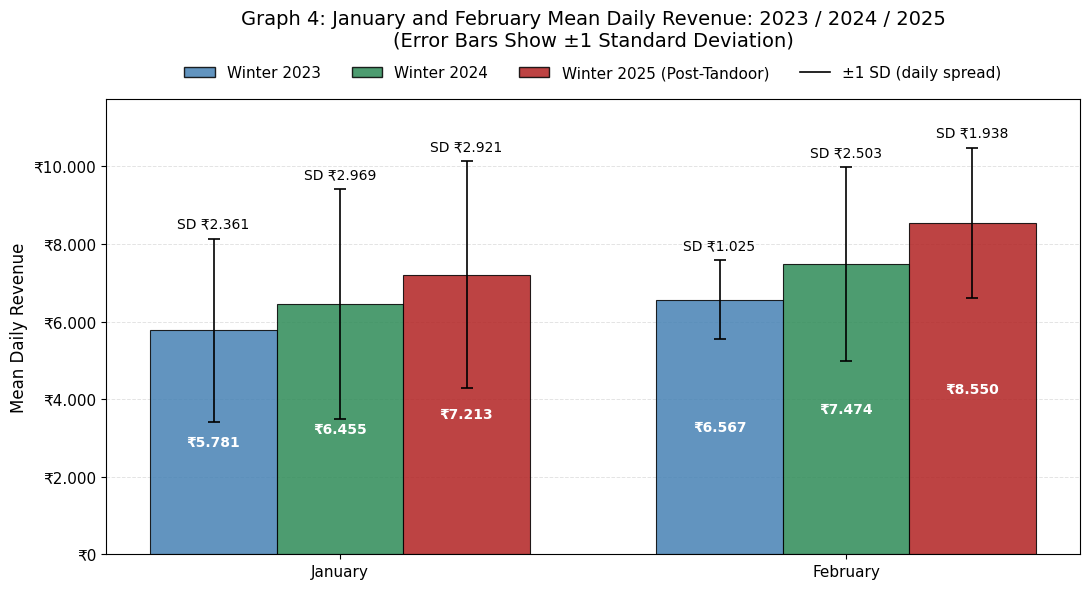


  GRAPH 4 INTERPRETATION

  This chart narrows to January and February, the two weakest months of the
  winter, and puts the three winters side by side within each month. Each bar is
  the mean daily revenue for that month, and the black line through it shows one
  standard deviation either side, so the bar is the typical day and the line is
  how much the days moved around it.

  In both months the bars step up from one winter to the next. January rises
  from ₹5.781 to ₹6.455 to ₹7.213, and
  February from ₹6.567 to ₹7.474 to ₹8.550.
  The post-tandoor winter is the highest in each case. The step from Winter 2024
  to Winter 2025 is ₹758 in January and ₹1.075
  in February.

  The error bars are wide. These months have few operating days, and the spread
  runs from about ₹1.025 to ₹2.969 across the six bars, so
  the bars for adjacent winters overlap. On this chart alone the rise could still
  be ordinary year-to-year movement rather than a real shift.

  Two things temper the readi

In [205]:
# GRAPH 4
# January and February, the two weakest months, with the three winters side
# by side so the post-tandoor month reads against the two baseline years.

# means reuse the Section 4.4 figures; only the month-level spread is new here
g4_means = [
    [jan_23_mean, feb_23_mean],
    [jan_24_mean, feb_24_mean],
    [jan_25_mean, feb_25_mean],
]
g4_sds = [
    [jan_23.std(ddof=1), feb_23.std(ddof=1)],
    [jan_24.std(ddof=1), feb_24.std(ddof=1)],
    [jan_25.std(ddof=1), feb_25.std(ddof=1)],
]
g4_colours = ["steelblue", "seagreen", "firebrick"]

g4_group_pos   = np.array([0, 1])    # x centre for January, February
g4_bar_width   = 0.25
g4_offsets     = [-g4_bar_width, 0, g4_bar_width]
g4_sd_cap      = 4                    # error-bar cap size
g4_label_frac  = 0.5                  # inside-bar label sits at half bar height
g4_label_floor = 3000                 # bars shorter than this get the label above
g4_label_lift  = 150                  # gap (₹) above a short bar for its mean label
g4_sd_gap      = 200                  # gap (₹) above an error cap for its SD label
g4_headroom    = 1.12                 # multiplier for headroom above the tallest SD label

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_axisbelow(True)

for i in range(3):
    month_means = g4_means[i]
    month_sds   = g4_sds[i]
    bars = ax.bar(
        g4_group_pos + g4_offsets[i],
        month_means,
        width=g4_bar_width,
        color=g4_colours[i],
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        yerr=month_sds,
        capsize=g4_sd_cap,
        error_kw=dict(elinewidth=1.2, ecolor="black", capthick=1.2),
    )
    # tall bars carry a white mean label inside, short bars carry it above in
    # dark text; the spread is printed above each error cap
    for bar, mean_val, sd_val in zip(bars, month_means, month_sds):
        x_centre = bar.get_x() + bar.get_width() / 2
        if mean_val >= g4_label_floor:
            ax.text(x_centre, mean_val * g4_label_frac, "₹" + fmt(mean_val),
                    ha="center", va="center", fontsize=10,
                    color="white", fontweight="bold")
        else:
            ax.text(x_centre, mean_val + g4_label_lift, "₹" + fmt(mean_val),
                    ha="center", va="bottom", fontsize=10, color="black")
        ax.text(x_centre, mean_val + sd_val + g4_sd_gap, "SD ₹" + fmt(sd_val),
                ha="center", va="bottom", fontsize=10, color="black")

ax.set_title("Graph 4: January and February Mean Daily Revenue: 2023 / 2024 / 2025\n"
             "(Error Bars Show ±1 Standard Deviation)",
             fontsize=14, pad=38)
ax.set_ylabel("Mean Daily Revenue", fontsize=12)
ax.set_xticks(g4_group_pos)
ax.set_xticklabels(["January", "February"], fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)

# headroom above the tallest cap, so the SD labels clear the legend row above
g4_all_caps = []
for i in range(3):
    for m in range(2):
        g4_all_caps.append(g4_means[i][m] + g4_sds[i][m])
g4_top_cap = max(g4_all_caps)
ax.set_ylim(bottom=0, top=g4_top_cap * g4_headroom)

g4_legend = [
    Patch(facecolor="steelblue", edgecolor="black", alpha=0.85, label="Winter 2023"),
    Patch(facecolor="seagreen",  edgecolor="black", alpha=0.85, label="Winter 2024"),
    Patch(facecolor="firebrick", edgecolor="black", alpha=0.85, label="Winter 2025 (Post-Tandoor)"),
    Line2D([0], [0], color="black", linewidth=1.2, label="±1 SD (daily spread)"),
]
ax.legend(handles=g4_legend, fontsize=11, framealpha=0.92,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          ncol=4, frameon=False)

plt.tight_layout()
plt.savefig("graph4_janfeb_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# gaps the prose needs, from the reused means
g4_jan_step_2425 = jan_25_mean - jan_24_mean
g4_feb_step_2425 = feb_25_mean - feb_24_mean

# spread range across the six bars, from the SDs above rather than read off the chart
g4_all_sds = [g4_sds[i][m] for i in range(3) for m in range(2)]
g4_sd_low  = min(g4_all_sds)
g4_sd_high = max(g4_all_sds)

print()
print("=" * 70)
print("  GRAPH 4 INTERPRETATION")
print("=" * 70)
print(f"""
  This chart narrows to January and February, the two weakest months of the
  winter, and puts the three winters side by side within each month. Each bar is
  the mean daily revenue for that month, and the black line through it shows one
  standard deviation either side, so the bar is the typical day and the line is
  how much the days moved around it.

  In both months the bars step up from one winter to the next. January rises
  from ₹{fmt(jan_23_mean)} to ₹{fmt(jan_24_mean)} to ₹{fmt(jan_25_mean)}, and
  February from ₹{fmt(feb_23_mean)} to ₹{fmt(feb_24_mean)} to ₹{fmt(feb_25_mean)}.
  The post-tandoor winter is the highest in each case. The step from Winter 2024
  to Winter 2025 is ₹{fmt(g4_jan_step_2425)} in January and ₹{fmt(g4_feb_step_2425)}
  in February.

  The error bars are wide. These months have few operating days, and the spread
  runs from about ₹{fmt(g4_sd_low)} to ₹{fmt(g4_sd_high)} across the six bars, so
  the bars for adjacent winters overlap. On this chart alone the rise could still
  be ordinary year-to-year movement rather than a real shift.

  Two things temper the reading. Part of the climb was already happening between
  the two baseline winters, before the tandoor existed, so not all of the final
  step can be put down to it. And the overlap in the error bars is why the weak
  months get their own formal test in Section 5, which measures the difference
  properly instead of relying on the eye.
""")

## SECTION 5: STATISTICAL TESTING

In [206]:
# SECTION 5: STATISTICAL TESTING

# PREREQUISITE
# Arrays and helpers used by every test below, and again in Sections 7 and 8.
baseline_rev = w_comb["revenue"].dropna().values
post_rev     = w2025["revenue"].dropna().values
pre_23_rev   = w2023_nd["revenue"].dropna().values
pre_24_rev   = w2024_nd["revenue"].dropna().values

def effect_size_label(d):
    if abs(d) < 0.20:
        return "Negligible"
    elif abs(d) < 0.50:
        return "Small"
    elif abs(d) < 0.80:
        return "Medium"
    else:
        return "Large"

def p_value_str(p):
    if p < 0.001:
        return "< 0,001"
    else:
        return fmt(p, 4)

print()
print("=" * 70)
print("  SECTION 5: STATISTICAL TESTING")
print("=" * 70)
print("""  This section tests whether the Winter 2025 revenue lift is larger
  than normal year-to-year movement. It first checks the baseline holds
  together, then compares baseline against Winter 2025 with a parametric
  and a distribution-free test, and closes with the effect size and a
  confidence interval for the difference.""")


# 5.1  Shapiro-Wilk Normality Test

shapiro_base_stat, shapiro_base_pval = stats.shapiro(baseline_rev)
shapiro_post_stat, shapiro_post_pval = stats.shapiro(post_rev)
shapiro_23_stat,   shapiro_23_pval   = stats.shapiro(pre_23_rev)
shapiro_24_stat,   shapiro_24_pval   = stats.shapiro(pre_24_rev)

print()
print("  5.1  Shapiro-Wilk Normality Test")
print("  " + "-" * 60)
print("""
  The Shapiro-Wilk test evaluates H0: the data are drawn from a
  normally distributed population. A p-value below 0,05 leads to
  rejection of this assumption.""")
print()
print(f"  {'Series':<38} {'W statistic':>12} {'p-value':>12} {'Decision':>10}")
print("  " + "-" * 75)
normality_results = [
    ("Baseline - Winter 2023 Non-Diwali", len(pre_23_rev),   shapiro_23_stat,   shapiro_23_pval),
    ("Baseline - Winter 2024 Non-Diwali", len(pre_24_rev),   shapiro_24_stat,   shapiro_24_pval),
    ("Baseline - Combined 2023+2024 ND",  len(baseline_rev), shapiro_base_stat, shapiro_base_pval),
    ("Post-intervention - Winter 2025",   len(post_rev),     shapiro_post_stat, shapiro_post_pval),
]
for label, n, w_stat, p_val in normality_results:
    decision = "Normal" if p_val >= ALPHA else "Non-normal"
    p_str = p_value_str(p_val)
    print(f"  {label:<38} {fmt(w_stat, 4):>12} {p_str:>12} {decision:>10}  (n={n})")
print("  " + "-" * 75)
print(f"""
  The three pre-intervention series reject normality (p < 0,001).
  Winter 2025 does not reject normality (p = {fmt(shapiro_post_pval, 4)}), but
  the baseline, the larger group, is non-normal. We therefore report
  Welch's t-test as the parametric benchmark and Mann-Whitney U as the
  distribution-free robustness check. Agreement between both tests
  supports the conclusion regardless of the normality assumption.""")
print()


# 5.2  Baseline Comparability Test: Winter 2023 vs Winter 2024

# 2024 first so the t-statistic is positive (2024 mean > 2023 mean)
ttest_base_comp_stat, ttest_base_comp_pval = stats.ttest_ind(pre_24_rev, pre_23_rev, equal_var=False)
mwu_base_comp_stat,   mwu_base_comp_pval   = stats.mannwhitneyu(pre_24_rev, pre_23_rev, alternative="two-sided")

n_23, n_24 = m_23_nd["n_days"], m_24_nd["n_days"]
s_23, s_24 = m_23_nd["sd"], m_24_nd["sd"]

pooled_sd_base     = np.sqrt(((n_23-1)*s_23**2 + (n_24-1)*s_24**2) / (n_23+n_24-2))
diff_base          = m_24_nd["mean"] - m_23_nd["mean"]
cohens_d_base_comp = diff_base / pooled_sd_base
pct_diff_base      = diff_base / m_23_nd["mean"] * 100

d_label_base = effect_size_label(cohens_d_base_comp)

p_base_t_str  = p_value_str(ttest_base_comp_pval)
p_base_mw_str = p_value_str(mwu_base_comp_pval)

print()
print("  5.2  Baseline Comparability Test: Winter 2023 vs Winter 2024")
print("  " + "-" * 60)
print(f"""
  Before testing the intervention effect we verify that the two
  pre-intervention winters are comparable enough to be pooled.
  H0: the mean daily revenue of Winter 2023 (Non-Diwali) equals that
  of Winter 2024 (Non-Diwali).

  Observed difference: ₹{fmt(m_24_nd["mean"])} - ₹{fmt(m_23_nd["mean"])} = ₹{fmt(diff_base)} ({'+' if pct_diff_base >= 0 else ''}{fmt(pct_diff_base, 1)}%)

  Cohen's d expresses the mean difference in units of the pooled
  standard deviation, so it does not depend on the revenue scale.""")

print()
print(f"  {'Test':<28} {'Statistic':>14} {'p-value':>14} {'Result':>13}")
print("  " + "-" * 70)
print(f"  {'Welch t-test':<28} {'t = '+fmt(ttest_base_comp_stat, 4):>14} {p_base_t_str:>14} "
      f"{'Yes' if ttest_base_comp_pval < ALPHA else 'No':>13}")
print(f"  {'Mann-Whitney U':<28} {'U = '+fmt(mwu_base_comp_stat):>14} {p_base_mw_str:>14} "
      f"{'Yes' if mwu_base_comp_pval < ALPHA else 'No':>13}")
print(f"  {'Cohen\'s d (effect size)':<28} {'d = '+fmt(cohens_d_base_comp, 4):>14} {'-':>14} "
      f"{d_label_base:>13}")
print("  " + "-" * 70)
print(f"""
  Welch's t-test finds a marginally significant difference (p = {fmt(ttest_base_comp_pval, 4)}),
  while Mann-Whitney does not (p = {fmt(mwu_base_comp_pval, 4)}). Because the baseline distributions
  are non-normal (Section 5.1), Mann-Whitney is the better guide for the pooling question, and it
  finds no significant difference between the two winters.
  Cohen's d = {fmt(cohens_d_base_comp, 3)} indicates a {d_label_base.lower()} effect. The 2024 winter mean is
  {'+' if pct_diff_base >= 0 else ''}{fmt(pct_diff_base, 1)}% higher than 2023, consistent with the restaurant's
  growth rather than an unstable baseline.

  Pooling 2023 and 2024 is therefore reasonable. Mann-Whitney finds no
  significant difference, and the observed gap is modest and in the same
  direction as the restaurant's growth trend. Pooling also gives a
  conservative baseline, since the higher pooled variance makes it harder
  to reject the null in the main test.

  The 2024 baseline exceeds 2023 by {'+' if pct_diff_base >= 0 else ''}{fmt(pct_diff_base, 1)}% (₹{fmt(diff_base)}/day).
  Section 7.2 tests whether the 2025 improvement merely continues this
  trend, using 2024-only as a more conservative baseline.""")
print()


# 5.3  Welch's t-Test: Combined Baseline vs Winter 2025

# post_rev first so the t-statistic is positive (2025 > baseline)
ttest_main = stats.ttest_ind(post_rev, baseline_rev, equal_var=False)
ttest_main_stat, ttest_main_pval = ttest_main.statistic, ttest_main.pvalue
mwu_main_stat,   mwu_main_pval   = stats.mannwhitneyu(post_rev, baseline_rev, alternative="two-sided")

n_base, n_post = m_comb["n_days"], m_25["n_days"]
s_base, s_post = m_comb["sd"], m_25["sd"]

# Welch degrees of freedom, as returned by scipy
df_welch = ttest_main.df

p_main_t_str  = p_value_str(ttest_main_pval)
p_main_mw_str = p_value_str(mwu_main_pval)

# decision follows the data, so it updates if the inputs change
decision_53 = "Reject H0" if ttest_main_pval < ALPHA else "Fail to Reject H0"

# name only the levels the p-value actually clears, so the prose stays correct
# if the data changes
if ttest_main_pval < 0.001:
    sig_levels_53 = "the 5%, 1%, and 0,1% significance levels"
elif ttest_main_pval < 0.01:
    sig_levels_53 = "the 5% and 1% significance levels"
elif ttest_main_pval < ALPHA:
    sig_levels_53 = "the 5% significance level"
else:
    sig_levels_53 = "no conventional significance level"

print()
print("  5.3  Welch's t-Test: Combined Baseline vs Winter 2025")
print("  " + "-" * 60)
print(f"""
  H0: mean(baseline) = mean(Winter 2025)
  H1: mean(baseline) is not equal to mean(Winter 2025)   [two-tailed, alpha = {fmt(ALPHA, 2)}]
  Welch's t-test does not assume equal variances between groups, which
  suits this case, where the sample sizes and standard deviations differ.""")

print()
print(f"  {'Parameter':<38} {'Value':>16}")
print("  " + "-" * 56)
print(f"  {'Baseline mean':<38} {'₹'+fmt(m_comb['mean']):>16}")
print(f"  {'Winter 2025 mean':<38} {'₹'+fmt(m_25['mean']):>16}")
print(f"  {'Observed mean difference':<38} {'₹'+fmt(mean_diff_main):>16}")
print(f"  {'Baseline n':<38} {n_base:>16}")
print(f"  {'Winter 2025 n':<38} {n_post:>16}")
print(f"  {'Baseline SD':<38} {'₹'+fmt(s_base):>16}")
print(f"  {'Winter 2025 SD':<38} {'₹'+fmt(s_post):>16}")
print(f"  {'Degrees of freedom (df)':<38} {fmt(df_welch, 2):>16}")
print(f"  {'t-statistic':<38} {fmt(ttest_main_stat, 4):>16}")
print(f"  {'p-value (two-tailed)':<38} {p_main_t_str:>16}")
print(f"  {'Decision at alpha = '+fmt(ALPHA, 2):<38} {decision_53:>16}")
print("  " + "-" * 56)
print(f"""
  The t-statistic of {fmt(ttest_main_stat, 4)} with p {p_main_t_str} is strong evidence against the null hypothesis.
  We reject H0 at {sig_levels_53}. The observed mean difference of
  ₹{fmt(mean_diff_main)} is {fmt(ttest_main_stat, 2)} standard errors above zero.""")
print()


# 5.4  Mann-Whitney U Test: Combined Baseline vs Winter 2025

decision_54 = "Reject H0" if mwu_main_pval < ALPHA else "Fail to Reject H0"

print()
print("  5.4  Mann-Whitney U Test: Combined Baseline vs Winter 2025")
print("  " + "-" * 65)
print("""
  The Mann-Whitney U test is a non-parametric alternative that makes
  no assumption about the shape of the underlying distributions. It
  tests whether a randomly selected day from Winter 2025 is more
  likely to bring in higher revenue than a randomly selected day from
  the baseline. Given non-normal baseline distributions (Section 5.1),
  this test gives a distribution-free check on the parametric result.""")

print()
print(f"  {'Parameter':<38} {'Value':>16}")
print("  " + "-" * 56)
print(f"  {'U statistic':<38} {fmt(mwu_main_stat):>16}")
print(f"  {'p-value (two-tailed)':<38} {p_main_mw_str:>16}")
print(f"  {'Decision at alpha = '+fmt(ALPHA, 2):<38} {decision_54:>16}")
print("  " + "-" * 56)
print(f"""
  Welch's t-test and Mann-Whitney U agree: the revenue distributions
  in Winter 2025 and the pre-intervention baseline are not consistent
  with being drawn from the same population. The agreement matters,
  because if only one test had flagged significance the result would be
  easier to doubt. Both tests reject H0 (Welch p {p_main_t_str},
  Mann-Whitney p {p_main_mw_str}), so the conclusion does not depend on
  the choice of test.""")
print()


# 5.5  Cohen's d: Effect Size

pooled_sd_main = np.sqrt(((n_base-1)*s_base**2 + (n_post-1)*s_post**2) / (n_base+n_post-2))
cohens_d_main = mean_diff_main / pooled_sd_main
se_diff = np.sqrt(s_base**2/n_base + s_post**2/n_post)
t_crit = stats.t.ppf(1 - ALPHA/2, df=df_welch)
ci_lower = mean_diff_main - t_crit * se_diff
ci_upper = mean_diff_main + t_crit * se_diff

d_label_main = effect_size_label(cohens_d_main)

print()
print("  5.5  Cohen's d: Effect Size")
print("  " + "-" * 56)

print(f"  {'Parameter':<38} {'Value':>16}")
print("  " + "-" * 56)
print(f"  {'Mean difference':<38} {'₹'+fmt(mean_diff_main):>16}")
print(f"  {'Pooled SD':<38} {'₹'+fmt(pooled_sd_main):>16}")
print(f"  {'Cohen\'s d':<38} {fmt(cohens_d_main, 4):>16}")
print(f"  {'Effect size category':<38} {d_label_main:>16}")
print("  " + "-" * 56)
print(f"""
  Note: pooled-SD formula used for consistency with Section 5.2.
  The two group SDs are close (₹{fmt(s_base)} vs ₹{fmt(s_post)}), so this
  simplification has little practical impact. The effect size is best
  read as approximate, since Welch's test was chosen because the
  variances technically differ.

  A Cohen's d of {fmt(cohens_d_main, 3)} is a {d_label_main.lower()} effect by Cohen's (1988)
  benchmarks. In revenue terms this is a difference the restaurant would
  notice, not a borderline statistical result.""")
print()


# 5.6  95% Confidence Interval for the Mean Difference

print()
print("  5.6  95% Confidence Interval for the Mean Difference")
print("  " + "-" * 60)
print(f"""
  The 95% confidence interval gives the range of mean differences
  consistent with the observed data at the 95% level. A narrower
  interval reflects more precise estimation. An interval that does
  not contain zero is consistent with rejecting H0 at alpha = {fmt(ALPHA, 2)}.""")

print()
print(f"  {'Parameter':<38} {'Value':>16}")
print("  " + "-" * 56)
print(f"  {'Point estimate (mean diff)':<38} {'₹'+fmt(mean_diff_main):>16}")
print(f"  {'Standard error of difference':<38} {'₹'+fmt(se_diff):>16}")
print(f"  {'Degrees of freedom (df)':<38} {fmt(df_welch, 2):>16}")
print(f"  {'t-critical (alpha/2 = '+fmt(ALPHA/2, 3)+')':<38} {fmt(t_crit, 4):>16}")
print(f"  {'95% CI lower bound':<38} {'₹'+fmt(ci_lower):>16}")
print(f"  {'95% CI upper bound':<38} {'₹'+fmt(ci_upper):>16}")
print("  " + "-" * 56)
print(f"""
  We are 95% confident that the true mean difference in daily revenue
  falls between ₹{fmt(ci_lower)} and ₹{fmt(ci_upper)} per operating day. The interval
  excludes zero. The lower bound of ₹{fmt(ci_lower)} per day is the
  smallest plausible daily difference even if this winter happened to be
  somewhat above the true underlying mean.""")
print()




  SECTION 5: STATISTICAL TESTING
  This section tests whether the Winter 2025 revenue lift is larger
  than normal year-to-year movement. It first checks the baseline holds
  together, then compares baseline against Winter 2025 with a parametric
  and a distribution-free test, and closes with the effect size and a
  confidence interval for the difference.

  5.1  Shapiro-Wilk Normality Test
  ------------------------------------------------------------

  The Shapiro-Wilk test evaluates H0: the data are drawn from a
  normally distributed population. A p-value below 0,05 leads to
  rejection of this assumption.

  Series                                  W statistic      p-value   Decision
  ---------------------------------------------------------------------------
  Baseline - Winter 2023 Non-Diwali            0,9496      < 0,001 Non-normal  (n=111)
  Baseline - Winter 2024 Non-Diwali            0,9389      < 0,001 Non-normal  (n=114)
  Baseline - Combined 2023+2024 ND             0,

In [207]:

# 5.7  Jan-Feb Sub-Test: Have the Weakest Months Improved?

# reuse the Jan-Feb series from Section 4.4, same data, single source
jf_base_rev = jf_comb_rev.values
jf_post_rev = jf_25.values

# post first so the t-statistic is positive when post mean > baseline mean
ttest_janfeb_stat, ttest_janfeb_pval = stats.ttest_ind(jf_post_rev, jf_base_rev, equal_var=False)

# Mann-Whitney U: two-sided p-value is invariant to argument order
mwu_janfeb_stat, mwu_janfeb_pval = stats.mannwhitneyu(jf_post_rev, jf_base_rev, alternative="two-sided")

n_jf_base, n_jf_post = len(jf_base_rev), len(jf_post_rev)
s_jf_base, s_jf_post = np.std(jf_base_rev, ddof=1), np.std(jf_post_rev, ddof=1)

ps_jf = np.sqrt(((n_jf_base-1)*s_jf_base**2 + (n_jf_post-1)*s_jf_post**2) / (n_jf_base+n_jf_post-2))
cohens_d_janfeb = (np.mean(jf_post_rev) - np.mean(jf_base_rev)) / ps_jf

d_label_janfeb = effect_size_label(cohens_d_janfeb)

p_jf_t_str  = p_value_str(ttest_janfeb_pval)
p_jf_mw_str = p_value_str(mwu_janfeb_pval)

print()
print("  5.7  Jan-Feb Sub-Test: Have the Weakest Months Improved?")
print("  " + "-" * 60)
print(f"""
  H0: mean Jan-Feb daily revenue in Winter 2025 equals the pooled
  Jan-Feb baseline (2023+2024, Non-Diwali).

  Jan-Feb baseline mean  : ₹{fmt(jf_base_mean)}  (n = {n_jf_base} operating days)
  Jan-Feb Winter 2025    : ₹{fmt(jf_25_mean)}  (n = {n_jf_post} operating days)
  Difference             : ₹{fmt(jf_abs_change)} ({'+' if jf_mean_pct >= 0 else ''}{fmt(jf_mean_pct, 1)}%)
""")

print(f"  {'Test':<28} {'Statistic':>14} {'p-value':>12} {'Result':>13}")
print("  " + "-" * 70)
print(f"  {'Welch t-test':<28} {'t = '+fmt(ttest_janfeb_stat, 4):>14} {p_jf_t_str:>12} "
      f"{'Yes' if ttest_janfeb_pval < ALPHA else 'No':>13}")
print(f"  {'Mann-Whitney U':<28} {'U = '+fmt(mwu_janfeb_stat):>14} {p_jf_mw_str:>12} "
      f"{'Yes' if mwu_janfeb_pval < ALPHA else 'No':>13}")
print(f"  {'Cohen\'s d':<28} {'d = '+fmt(cohens_d_janfeb, 4):>14} {'-':>12} "
      f"{d_label_janfeb:>13}")
print("  " + "-" * 70)
print(f"""
  Both tests reject H0 for January-February on its own. Cohen's d is
  {fmt(cohens_d_janfeb, 3)} ({d_label_janfeb.lower()} effect) in the weakest months. The rise is not
  confined to the already-strong November period; the weak Jan-Feb trough
  rose as well.""")
print()


# 5.8  Statistical Results Summary

print()
print("  5.8  Statistical Results Summary")
print("  " + "-" * 76)
print()

print(f"  {'Test / Metric':<42} {'Result':>22} {'Verdict':>10}")
print("  " + "-" * 76)
print(f"  {'Baseline Comparability (2023 vs 2024)':<42}")
print(f"  {'  Welch t-test':<42} "
      f"{'p = '+p_base_t_str:>22} {'Marginal':>10}")
print(f"  {'  Mann-Whitney U':<42} "
      f"{'p = '+p_base_mw_str:>22} {'No diff':>10}")
print(f"  {'  Conclusion':<42} {'Pooling defensible':>22} {'Supported':>10}")
print()
print(f"  {'Full-Winter Test (Baseline vs Winter 2025)':<42}")
print(f"  {'  Welch t-test':<42} "
      f"{'p = '+p_main_t_str:>22} {'Significant':>10}")
print(f"  {'  Mann-Whitney U':<42} "
      f"{'p = '+p_main_mw_str:>22} {'Significant':>10}")
print(f"  {'  Cohen\'s d':<42} "
      f"{'d = '+fmt(cohens_d_main, 3)+' ['+d_label_main+']':>22} {'Supported':>10}")
print(f"  {'  95% CI (₹ per day)':<42} "
      f"{'['+fmt(ci_lower)+' - '+fmt(ci_upper)+']':>22} {'Supported':>10}")
print()
print(f"  {'Jan-Feb Sub-Test':<42}")
print(f"  {'  Welch t-test':<42} "
      f"{'p = '+p_jf_t_str:>22} {'Significant':>10}")
print(f"  {'  Mann-Whitney U':<42} "
      f"{'p = '+p_jf_mw_str:>22} {'Significant':>10}")
print(f"  {'  Cohen\'s d':<42} "
      f"{'d = '+fmt(cohens_d_janfeb, 3)+' ['+d_label_janfeb+']':>22} {'Supported':>10}")
print("  " + "-" * 76)
print(f"""
  Every intervention test points in the same direction. The baseline
  comparability check (Section 5.2) gave mixed results, one test marginally
  significant and one not, which is expected when comparing two
  pre-intervention winters with organic growth between them. The revenue
  difference in Winter 2025 is statistically significant at any conventional
  threshold, the effect size is {d_label_main.lower()} (d = {fmt(cohens_d_main, 3)}), the 95% CI excludes zero,
  and the difference holds when restricted to January-February alone.

  Note: This analysis rests on a single winter of post-intervention data.
  Statistical significance quantifies the probability of observing this
  difference under the null hypothesis; it does not establish causation. The
  observed difference is consistent with the tandoor's effect, but also with
  organic growth, local market changes, or unmeasured confounders. Replication
  in Winter 2026 would strengthen causal inference. The sensitivity analysis
  in Section 7 tests robustness under alternative assumptions.""")
print()

print("=" * 80)


  5.7  Jan-Feb Sub-Test: Have the Weakest Months Improved?
  ------------------------------------------------------------

  H0: mean Jan-Feb daily revenue in Winter 2025 equals the pooled
  Jan-Feb baseline (2023+2024, Non-Diwali).

  Jan-Feb baseline mean  : ₹6.555  (n = 116 operating days)
  Jan-Feb Winter 2025    : ₹7.870  (n = 57 operating days)
  Difference             : ₹1.315 (+20,1%)

  Test                              Statistic      p-value        Result
  ----------------------------------------------------------------------
  Welch t-test                     t = 3,2540       0,0015           Yes
  Mann-Whitney U                    U = 4.484      < 0,001           Yes
  Cohen's d                        d = 0,5397            -        Medium
  ----------------------------------------------------------------------

  Both tests reject H0 for January-February on its own. Cohen's d is
  0,540 (medium effect) in the weakest months. The rise is not
  confined to the already-stron

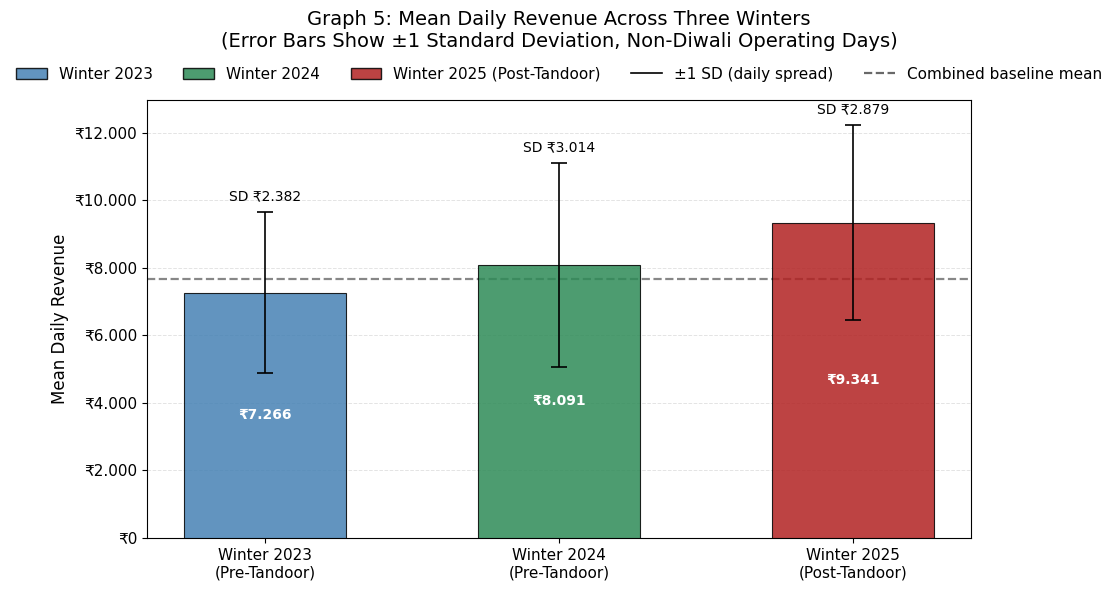


  GRAPH 5 INTERPRETATION

  This chart puts the three winters next to each other as a single number each:
  the average revenue of an operating day, with the thin line on every bar
  showing one standard deviation either side, so the bar is the typical day and
  the line is how much the days moved around it. Diwali days are left out, the
  same baseline used everywhere else in the report.

  The bars step up each winter, from ₹7.266 to
  ₹8.091 to ₹9.341. The first
  step of ₹826 happened before the tandoor, between the two
  baseline winters, so part of the second step of ₹1.250 is simply
  that same climb continuing. The dashed grey line is the pooled baseline
  average, and the post-tandoor bar sits above it.

  The spread needs reading with care, because the error bars and the CV tell
  slightly different stories. In absolute terms Winter 2025 does not have the
  shortest bar: its standard deviation sits between the two baseline winters,
  since a higher average tends to carry a w

In [208]:
# GRAPH 5
# Three winters side by side as mean daily revenue, with ±1 SD error bars and
# the pooled baseline as a reference line.

# descriptive metrics from Sections 3 and 5
g5_metric_2023 = m_23_nd
g5_metric_2024 = m_24_nd
g5_metric_2025 = m_25
g5_baseline_mean = m_comb["mean"]

g5_bar_width  = 0.55
g5_sd_cap     = 6        # error-bar cap size
g5_label_frac = 0.5      # mean label sits at half bar height (tall bars hold it)
g5_sd_gap     = 260      # gap (₹) above an error cap for its SD label
g5_top_pad    = 500      # small headroom (₹) above the SD label of the tallest cap

g5_positions = np.array([0, 1, 2])
g5_labels    = [
    "Winter 2023\n(Pre-Tandoor)",
    "Winter 2024\n(Pre-Tandoor)",
    "Winter 2025\n(Post-Tandoor)",
]
g5_colours = ["steelblue", "seagreen", "firebrick"]

g5_means = [g5_metric_2023["mean"], g5_metric_2024["mean"], g5_metric_2025["mean"]]
g5_sds   = [g5_metric_2023["sd"],   g5_metric_2024["sd"],   g5_metric_2025["sd"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_axisbelow(True)

bars = ax.bar(
    g5_positions, g5_means,
    width=g5_bar_width,
    color=g5_colours,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85,
    yerr=g5_sds,
    capsize=g5_sd_cap,
    error_kw=dict(elinewidth=1.2, ecolor="black", capthick=1.2),
    zorder=3,
)

ax.axhline(
    g5_baseline_mean,
    color="dimgray", linewidth=1.6, linestyle="--", alpha=0.8, zorder=2,
    label="Combined baseline mean  ₹" + fmt(g5_baseline_mean),
)

for bar, mean_val, sd_val in zip(bars, g5_means, g5_sds):
    x_centre = bar.get_x() + bar.get_width() / 2
    ax.text(x_centre, mean_val * g5_label_frac, "₹" + fmt(mean_val),
            ha="center", va="center", fontsize=10,
            color="white", fontweight="bold")
    ax.text(x_centre, mean_val + sd_val + g5_sd_gap, "SD ₹" + fmt(sd_val),
            ha="center", va="bottom", fontsize=10, color="black")

ax.set_title(
    "Graph 5: Mean Daily Revenue Across Three Winters\n"
    "(Error Bars Show ±1 Standard Deviation, Non-Diwali Operating Days)",
    fontsize=14, pad=38,
)
ax.set_ylabel("Mean Daily Revenue", fontsize=12)
ax.set_xticks(g5_positions)
ax.set_xticklabels(g5_labels, fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)

g5_cap_2023 = g5_means[0] + g5_sds[0]
g5_cap_2024 = g5_means[1] + g5_sds[1]
g5_cap_2025 = g5_means[2] + g5_sds[2]
g5_top_cap = max(g5_cap_2023, g5_cap_2024, g5_cap_2025)
ax.set_ylim(bottom=0, top=g5_top_cap + g5_sd_gap + g5_top_pad)

g5_legend = [
    Patch(facecolor="steelblue", edgecolor="black", alpha=0.85, label="Winter 2023"),
    Patch(facecolor="seagreen",  edgecolor="black", alpha=0.85, label="Winter 2024"),
    Patch(facecolor="firebrick", edgecolor="black", alpha=0.85, label="Winter 2025 (Post-Tandoor)"),
    Line2D([0], [0], color="black", linewidth=1.2, label="±1 SD (daily spread)"),
    Line2D([0], [0], color="dimgray", linewidth=1.6, linestyle="--",
           label="Combined baseline mean"),
]
ax.legend(handles=g5_legend, fontsize=11, framealpha=0.92,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          ncol=5, frameon=False)

plt.tight_layout()
plt.savefig("graph5_mean_revenue_errorbars.png", dpi=150, bbox_inches="tight")
plt.show()

g5_step_2324 = g5_metric_2024["mean"] - g5_metric_2023["mean"]
g5_step_2425 = g5_metric_2025["mean"] - g5_metric_2024["mean"]
g5_cv_gap_25 = g5_metric_2025["cv"] - m_comb["cv"]

print()
print("=" * 70)
print("  GRAPH 5 INTERPRETATION")
print("=" * 70)
print(f"""
  This chart puts the three winters next to each other as a single number each:
  the average revenue of an operating day, with the thin line on every bar
  showing one standard deviation either side, so the bar is the typical day and
  the line is how much the days moved around it. Diwali days are left out, the
  same baseline used everywhere else in the report.

  The bars step up each winter, from ₹{fmt(g5_metric_2023['mean'])} to
  ₹{fmt(g5_metric_2024['mean'])} to ₹{fmt(g5_metric_2025['mean'])}. The first
  step of ₹{fmt(g5_step_2324)} happened before the tandoor, between the two
  baseline winters, so part of the second step of ₹{fmt(g5_step_2425)} is simply
  that same climb continuing. The dashed grey line is the pooled baseline
  average, and the post-tandoor bar sits above it.

  The spread needs reading with care, because the error bars and the CV tell
  slightly different stories. In absolute terms Winter 2025 does not have the
  shortest bar: its standard deviation sits between the two baseline winters,
  since a higher average tends to carry a wider absolute spread. Measured
  against its own mean, though, it is the steadiest of the three. Its CV is
  {fmt(g5_metric_2025['cv'], 1)}%, the lowest of the winters and
  {fmt(abs(g5_cv_gap_25), 1)} points below the pooled baseline. So the revenue
  in Winter 2025 came with less relative day-to-day swing than before.

  The formal test of this difference belongs to Section 5, which separates
  Winter 2025 from the baseline and measures the effect size. The bars cannot
  say how much of the rise is the tandoor and how much is the growth that was
  already underway. What the chart shows is a season that is higher on
  average and steadier against its own level than the two before it.
""")

## SECTION 6: EFFECT QUANTIFICATION & PROFITABILITY


In [209]:
# SECTION 6: EFFECT QUANTIFICATION & PROFITABILITY

# PREREQUISITE
# Winter expense totals and the tandoor cost constants, used across the
# sub-sections below.

def get_winter_expenses(year_start):
    """Return monthly expenses for one winter season (Nov-Dec plus Jan-Feb)."""
    nov_dec = monthly_expenses[
        (monthly_expenses["year"] == year_start) &
        (monthly_expenses["month_num"].isin([11, 12]))
    ].copy()
    jan_feb = monthly_expenses[
        (monthly_expenses["year"] == year_start + 1) &
        (monthly_expenses["month_num"].isin([1, 2]))
    ].copy()
    return pd.concat([nov_dec, jan_feb], ignore_index=True)

e2023 = get_winter_expenses(2023)
e2024 = get_winter_expenses(2024)
e2025 = get_winter_expenses(2025)

exp_totals = {
    "2023": e2023[exp_cols].sum(),
    "2024": e2024[exp_cols].sum(),
    "2025": e2025[exp_cols].sum(),
}

# tandoor cost constants, first needed in this section
COAL_KG_PER_DAY      = 10        # mean of the 9-11 kg/day range
COAL_PRICE_PER_KG    = 38        # ₹ per kg
COAL_COST_PER_DAY    = COAL_KG_PER_DAY * COAL_PRICE_PER_KG  # ₹380/day
TANDOOR_CHEF_MONTHLY = 20000     # ₹, embedded in labour_cost from Oct 2025
WINTER_WINDOW_MONTHS = 4         # Nov, Dec, Jan, Feb

print()
print("=" * 70)
print("  SECTION 6: EFFECT QUANTIFICATION & PROFITABILITY")
print("=" * 70)
print("""  Sections 3 to 5 showed what changed and whether it is statistically
  real. This section brings revenue, the tandoor's own running cost, and
  profit into one picture, to answer whether the winter actually earned
  more money once the intervention paid for itself.""")


# 6.1  Revenue Impact Summary

total_change_abs = m_25["total"] - m_24_full["total"]
total_change_pct = total_change_abs / m_24_full["total"] * 100

extra_daily = mean_diff_main
extra_total = mean_diff_main * m_25["n_days"]

print()
print("  6.1  Revenue Impact Summary")
print("  " + "-" * 65)
print("""  Winter 2025 vs the pooled Non-Diwali baseline (Winters 2023+2024).
  All revenue comparisons use operating days only. Diwali days are
  excluded from the baseline for a clean comparison; Winter 2025 contains
  no Diwali days by calendar timing (Section 4.2).""")

print()
print("  TABLE 6.1  Revenue Impact: Winter 2025 vs Pooled Baseline")
print(f"  (Non-Diwali baseline, {m_comb['n_days']} operating days)")
print()
print(f"  {'Metric':<40} {'Baseline':>12} {'Winter 2025':>13} {'Change':>10}")
print("  " + "-" * 78)

rows_61 = [
    ("Mean Daily Revenue",          m_comb["mean"],   m_25["mean"],   "money"),
    ("Median Daily Revenue",        m_comb["median"], m_25["median"], "money"),
    ("Standard Deviation",          m_comb["sd"],     m_25["sd"],     "money"),
    ("CV (Coefficient of Var.)",    m_comb["cv"],     m_25["cv"],     "pct"),
    ("P25 (Bad-day floor)",         m_comb["p25"],    m_25["p25"],    "money"),
    ("P75 (Good-day ceiling)",      m_comb["p75"],    m_25["p75"],    "money"),
]

for label, vbase, v25, typ in rows_61:
    if typ == "pct":
        cb  = fmt(vbase, 1) + "%"
        c25 = fmt(v25, 1) + "%"
        chg = ("+" if v25-vbase >= 0 else "") + fmt(v25-vbase, 1) + "pp"
    else:
        cb  = "₹" + fmt(vbase)
        c25 = "₹" + fmt(v25)
        pct = (v25 - vbase) / vbase * 100 if vbase != 0 else 0
        chg = ("+" if pct >= 0 else "") + fmt(pct, 1) + "%"
    print(f"  {label:<40} {cb:>12} {c25:>13} {chg:>10}")

print("  " + "-" * 78)

print(f"""
  Total winter revenue change, 2024 to 2025: {('+' if total_change_pct >= 0 else '')}{fmt(total_change_pct, 1)}%
  (full winter, year-on-year, both including any Diwali days)

  For Winter 2025, the extra revenue against the pooled baseline is about
  ₹{fmt(extra_daily)} per operating day, or ₹{fmt(extra_total)} in extra revenue
  in total across the {m_25["n_days"]} operating days.

  The CV dropped by {fmt(abs(cv_diff), 1)} percentage points, from {fmt(m_comb['cv'], 1)}% to
  {fmt(m_25['cv'], 1)}%. A lower CV means more predictable cash flow, a gain
  beyond the revenue rise.

  The median rose by {fmt(med_pct, 1)}%, more than the {fmt(mean_pct, 1)}% rise in the
  mean. The improvement was therefore not driven by a handful of exceptionally
  strong days; the typical operating day earns more than before.""")
print()


# 6.2  Tandoor Operating Cost

# fuel is charged on operating days (the tandoor fires only when open); the
# chef salary runs across the four winter months
tandoor_fuel_2025 = m_25["n_days"] * COAL_COST_PER_DAY
tandoor_chef_2025 = TANDOOR_CHEF_MONTHLY * WINTER_WINDOW_MONTHS
tandoor_cost_2025 = tandoor_fuel_2025 + tandoor_chef_2025

print()
print("  6.2  Tandoor Operating Cost")
print("  " + "-" * 70)
print(f"""  The tandoor added operating cost in two places: coal fuel and a
  dedicated chef salary. Both already sit in the monthly_expenses sheet
  (utility_maint and labour_cost). This sub-section isolates the
  tandoor-related portion for transparency.

  Note: coal cost is charged on operating days, not calendar days. The
  tandoor fires only when the restaurant is open. Winter 2025 had
  {m_25['n_days']} operating days, not 120 calendar days.""")

print()
print("  TABLE 6.2  Tandoor Operating Cost: Winter 2025")
print()
print(f"  {'Component':<42} {'Calculation':>18} {'Amount':>14}")
print("  " + "-" * 78)
print(f"  {'Tandoor Fuel (coal)':<42} {str(m_25['n_days'])+' days x ₹'+str(COAL_COST_PER_DAY):>18} {'₹'+fmt(tandoor_fuel_2025):>14}")
print(f"  {'Tandoor Chef Salary':<42} {str(WINTER_WINDOW_MONTHS)+' months x ₹'+fmt(TANDOOR_CHEF_MONTHLY):>18} {'₹'+fmt(tandoor_chef_2025):>14}")
print("  " + "-" * 78)
print(f"  {'Total Tandoor Operating Cost':<42} {'':>18} {'₹'+fmt(tandoor_cost_2025):>14}")
print("  " + "-" * 78)

print(f"""
  Cost basis: coal consumption is {COAL_KG_PER_DAY} kg per operating day (mean of
  the 9-11 kg range) at ₹{COAL_PRICE_PER_KG} per kg, so ₹{COAL_COST_PER_DAY} per operating day.

  The tandoor purchase price (₹20.000 in 2021) is treated as a sunk cost
  and left out. Only marginal operating costs are counted.""")
print()


# 6.3  Net Effect Calculation

net_tandoor_effect = extra_total - tandoor_cost_2025
net_vs_2024        = total_change_abs - tandoor_cost_2025

print()
print("  6.3  Net Effect Calculation")
print("  " + "-" * 70)
print("""  This sub-section answers the owner's direct question: after the
  tandoor's own running cost, what is left? The arithmetic is simple; the
  interpretation needs care.""")

print()
print("  TABLE 6.3  Net Tandoor Effect: Winter 2025")
print()
print(f"  {'Item':<42} {'Amount':>16} {'Notes':>16}")
print("  " + "-" * 78)
print(f"  {'Extra revenue (vs pooled baseline)':<42} {'₹'+fmt(extra_total):>16} {'Section 6.1':>16}")
print(f"  {'Less: Tandoor operating cost':<42} {'₹'+fmt(tandoor_cost_2025):>16} {'Section 6.2':>16}")
print("  " + "-" * 78)
net_label = "Positive" if net_tandoor_effect >= 0 else "Negative"
print(f"  {'Net effect (clean baseline)':<42} {'₹'+fmt(net_tandoor_effect):>16} {net_label:>16}")
print("  " + "-" * 78)

print(f"""
  The tandoor generated ₹{fmt(extra_total)} in extra revenue against a running
  cost of ₹{fmt(tandoor_cost_2025)}, leaving a net of ₹{fmt(net_tandoor_effect)}
  for the winter.

  Assumption: this treats the extra revenue as coming from the tandoor, which
  is an assumption, not a fact. The restaurant may have grown regardless this
  year. Section 5 tests whether the tandoor drove the rise or whether it was
  coincidence. This table only does the arithmetic.

  One further check compares to last winter directly. Winter 2024 had
  {int(w2024['is_diwali'].sum())} Diwali days in the winter window lifting sales,
  Winter 2025 had none, which makes 2024 look stronger than it was:

  Winter 2024 total revenue     : ₹{fmt(m_24_full['total'])}
  Winter 2025 total revenue     : ₹{fmt(m_25['total'])}
  Extra revenue (2024 to 2025)  : ₹{fmt(total_change_abs)}
  Tandoor operating cost        : ₹{fmt(tandoor_cost_2025)}
  Net (2024 comparison)         : ₹{fmt(net_vs_2024)}

  This comparison is unfair because of Diwali, but it is the one the owner
  looks at first. Both are shown; the clean-baseline net (₹{fmt(net_tandoor_effect)})
  is the figure this report treats as primary, because it compares like with
  like.""")
print()


  SECTION 6: EFFECT QUANTIFICATION & PROFITABILITY
  Sections 3 to 5 showed what changed and whether it is statistically
  real. This section brings revenue, the tandoor's own running cost, and
  profit into one picture, to answer whether the winter actually earned
  more money once the intervention paid for itself.

  6.1  Revenue Impact Summary
  -----------------------------------------------------------------
  Winter 2025 vs the pooled Non-Diwali baseline (Winters 2023+2024).
  All revenue comparisons use operating days only. Diwali days are
  excluded from the baseline for a clean comparison; Winter 2025 contains
  no Diwali days by calendar timing (Section 4.2).

  TABLE 6.1  Revenue Impact: Winter 2025 vs Pooled Baseline
  (Non-Diwali baseline, 225 operating days)

  Metric                                       Baseline   Winter 2025     Change
  ------------------------------------------------------------------------------
  Mean Daily Revenue                             ₹7.6

In [210]:
# 6.4  Profitability

# net profit per winter, full winter (Diwali included where applicable),
# built into one dict the table and prose both read from
profit_data = {}

revenue_2023 = m_23_full["total"]
expenses_2023 = exp_totals["2023"]["total_expenses"]
profit_2023 = revenue_2023 - expenses_2023
margin_2023 = profit_2023 / revenue_2023 * 100 if revenue_2023 != 0 else 0
exp_ratio_2023 = expenses_2023 / revenue_2023 * 100 if revenue_2023 != 0 else 0
profit_per_day_2023 = profit_2023 / m_23_full["n_days"] if m_23_full["n_days"] > 0 else 0
profit_data["2023"] = {
    "revenue": revenue_2023, "expenses": expenses_2023,
    "profit": profit_2023, "margin": margin_2023, "exp_ratio": exp_ratio_2023,
    "profit_per_day": profit_per_day_2023, "n_days": m_23_full["n_days"],
}

revenue_2024 = m_24_full["total"]
expenses_2024 = exp_totals["2024"]["total_expenses"]
profit_2024 = revenue_2024 - expenses_2024
margin_2024 = profit_2024 / revenue_2024 * 100 if revenue_2024 != 0 else 0
exp_ratio_2024 = expenses_2024 / revenue_2024 * 100 if revenue_2024 != 0 else 0
profit_per_day_2024 = profit_2024 / m_24_full["n_days"] if m_24_full["n_days"] > 0 else 0
profit_data["2024"] = {
    "revenue": revenue_2024, "expenses": expenses_2024,
    "profit": profit_2024, "margin": margin_2024, "exp_ratio": exp_ratio_2024,
    "profit_per_day": profit_per_day_2024, "n_days": m_24_full["n_days"],
}

revenue_2025 = m_25["total"]
expenses_2025 = exp_totals["2025"]["total_expenses"]
profit_2025 = revenue_2025 - expenses_2025
margin_2025 = profit_2025 / revenue_2025 * 100 if revenue_2025 != 0 else 0
exp_ratio_2025 = expenses_2025 / revenue_2025 * 100 if revenue_2025 != 0 else 0
profit_per_day_2025 = profit_2025 / m_25["n_days"] if m_25["n_days"] > 0 else 0
profit_data["2025"] = {
    "revenue": revenue_2025, "expenses": expenses_2025,
    "profit": profit_2025, "margin": margin_2025, "exp_ratio": exp_ratio_2025,
    "profit_per_day": profit_per_day_2025, "n_days": m_25["n_days"],
}

print()
print("  6.4  Profitability")
print("  " + "-" * 70)
print("""  Did the tandoor make the restaurant more profitable? This compares
  net profit and profit margin across the three winters. All figures are
  pre-income-tax. Profit and margin both fell against 2024: the tandoor
  lifted absolute revenue and steadied it, but its running cost
  compressed the margin.""")

print()
print("  TABLE 6.4  Winter Profitability Comparison")
print()
print(f"  {'Metric':<28} {'Winter 2023':>14} {'Winter 2024':>14} {'Winter 2025':>14}")
print("  " + "-" * 72)

profit_rows = [
    ("Total Winter Revenue",     "revenue",        "money"),
    ("Total Winter Expenses",    "expenses",       "money"),
    ("Net Profit",               "profit",         "money"),
    ("Profit Margin",            "margin",         "pct"),
    ("Expense Ratio",            "exp_ratio",      "pct"),
    ("Profit per Operating Day", "profit_per_day", "money"),
]

for label, key, typ in profit_rows:
    v23 = profit_data["2023"][key]
    v24 = profit_data["2024"][key]
    v25 = profit_data["2025"][key]
    if typ == "money":
        print(f"  {label:<28} {'₹'+fmt(v23):>14} {'₹'+fmt(v24):>14} {'₹'+fmt(v25):>14}")
    else:
        print(f"  {label:<28} {fmt(v23, 1):>13}% {fmt(v24, 1):>13}% {fmt(v25, 1):>13}%")

print("  " + "-" * 72)

profit_change_2324     = profit_data["2024"]["profit"] - profit_data["2023"]["profit"]
profit_change_2324_pct = (profit_change_2324 / profit_data["2023"]["profit"] * 100) if profit_data["2023"]["profit"] != 0 else 0
profit_change_2425     = profit_data["2025"]["profit"] - profit_data["2024"]["profit"]
profit_change_2425_pct = (profit_change_2425 / profit_data["2024"]["profit"] * 100) if profit_data["2024"]["profit"] != 0 else 0
margin_gain_2324       = profit_data["2024"]["margin"] - profit_data["2023"]["margin"]
margin_gain_2425       = profit_data["2025"]["margin"] - profit_data["2024"]["margin"]

print(f"""
  Winter-to-winter profit growth:
    2023 to 2024:  ₹{fmt(profit_change_2324)}  ({('+' if profit_change_2324_pct >= 0 else '')}{fmt(profit_change_2324_pct, 1)}%)
    2024 to 2025:  ₹{fmt(profit_change_2425)}  ({('+' if profit_change_2425_pct >= 0 else '')}{fmt(profit_change_2425_pct, 1)}%)

  Winter-to-winter margin change:
    2023 to 2024:  {('+' if margin_gain_2324 >= 0 else '')}{fmt(margin_gain_2324, 1)} percentage points
    2024 to 2025:  {('+' if margin_gain_2425 >= 0 else '')}{fmt(margin_gain_2425, 1)} percentage points

  Net profit grew from 2023 to 2024 ({('+' if profit_change_2324_pct >= 0 else '')}{fmt(profit_change_2324_pct, 1)}%) but fell from
  2024 to 2025 ({('+' if profit_change_2425_pct >= 0 else '')}{fmt(profit_change_2425_pct, 1)}%) as the tandoor's running cost of
  ₹{fmt(tandoor_cost_2025)} entered the expense base for the first time. The
  margin followed the same path: {fmt(profit_data['2023']['margin'], 1)}% to
  {fmt(profit_data['2024']['margin'], 1)}% to {fmt(profit_data['2025']['margin'], 1)}%.

  This is the trade-off: the tandoor lifted absolute revenue and steadied
  it (lower CV), but the margin fell. Revenue rose with the tandoor;
  profitability did not.

  Note on method: revenue uses the Diwali-adjusted pooled baseline, but
  profitability is compared full-winter, year-by-year. Revenue can be split
  from Diwali day by day; expenses cannot, since they are recorded monthly. So
  margins are kept honest by comparing whole winters, accepting that 2024 still
  carries its Diwali revenue.""")

profit_excl_tandoor = profit_data["2025"]["profit"] + tandoor_cost_2025
tandoor_share_pct   = tandoor_cost_2025 / profit_excl_tandoor * 100
profit_share_pct    = 100 - tandoor_share_pct

print()
print("  Tandoor Cost vs Profit: Winter 2025")
print("  " + "-" * 60)
print(f"  {'Net Profit (after tandoor cost)':<38} {'₹'+fmt(profit_data['2025']['profit']):>12}")
print(f"  {'+ Tandoor Running Cost (Section 6.2)':<38} {'₹'+fmt(tandoor_cost_2025):>12}")
print("  " + "-" * 60)
print(f"  {'= Profit excl. tandoor running cost':<38} {'₹'+fmt(profit_excl_tandoor):>12}")
print("  " + "-" * 60)
print(f"""
  Without coal and chef costs, profit this winter would have been
  ₹{fmt(profit_excl_tandoor)}. Measured against that pre-tandoor profit, the
  tandoor took ₹{fmt(tandoor_cost_2025)} ({fmt(tandoor_share_pct, 1)}%), leaving
  ₹{fmt(profit_data['2025']['profit'])} ({fmt(profit_share_pct, 1)}%) as net profit.

  Assumption: this is bookkeeping, not proof. It treats the extra revenue as
  coming from the tandoor. Section 5 tests whether that assumption holds.""")
print()


# 6.5  Jan-Feb Profitability Deep Dive

# Jan-Feb figures per winter (not pooled) so the scale comparison is fair
jf_e2023 = e2023[e2023['month_num'].isin([1, 2])]
jf_e2024 = e2024[e2024['month_num'].isin([1, 2])]
jf_e2025 = e2025[e2025['month_num'].isin([1, 2])]

jf_rev_2023 = w2023[w2023['month_num'].isin([1, 2])]['revenue'].sum()
jf_rev_2024 = w2024[w2024['month_num'].isin([1, 2])]['revenue'].sum()
jf_rev_2025 = w2025[w2025['month_num'].isin([1, 2])]['revenue'].sum()

jf_exp_2023 = jf_e2023['total_expenses'].sum()
jf_exp_2024 = jf_e2024['total_expenses'].sum()
jf_exp_2025 = jf_e2025['total_expenses'].sum()

jf_profit_2023 = jf_rev_2023 - jf_exp_2023
jf_profit_2024 = jf_rev_2024 - jf_exp_2024
jf_profit_2025 = jf_rev_2025 - jf_exp_2025

jf_margin_2023 = (jf_profit_2023 / jf_rev_2023) * 100 if jf_rev_2023 != 0 else 0
jf_margin_2024 = (jf_profit_2024 / jf_rev_2024) * 100 if jf_rev_2024 != 0 else 0
jf_margin_2025 = (jf_profit_2025 / jf_rev_2025) * 100 if jf_rev_2025 != 0 else 0

jf_days_2023 = len(w2023[w2023['month_num'].isin([1, 2])])
jf_days_2024 = len(w2024[w2024['month_num'].isin([1, 2])])
jf_days_2025 = len(w2025[w2025['month_num'].isin([1, 2])])

print()
print("  6.5  Jan-Feb Profitability Deep Dive")
print("  " + "-" * 70)
print("""  January and February are historically the weakest months, the very
  problem the tandoor was meant to solve. This sub-section isolates profit
  in those two months, comparing each winter on its own (no pooling) for a
  fair scale.""")

print()
print("  TABLE 6.5  Jan-Feb Profitability: Per-Winter Comparison")
print()
print(f"  {'Metric':<28} {'Winter 2023':>14} {'Winter 2024':>14} {'Winter 2025':>14}")
print("  " + "-" * 72)

jf_rows = [
    ("Total Revenue",   jf_rev_2023,    jf_rev_2024,    jf_rev_2025,    "money"),
    ("Total Expenses",  jf_exp_2023,    jf_exp_2024,    jf_exp_2025,    "money"),
    ("Net Profit",      jf_profit_2023, jf_profit_2024, jf_profit_2025, "money"),
    ("Profit Margin",   jf_margin_2023, jf_margin_2024, jf_margin_2025, "pct"),
    ("Operating Days",  jf_days_2023,   jf_days_2024,   jf_days_2025,   "int"),
]

for label, v23, v24, v25, typ in jf_rows:
    if typ == "money":
        print(f"  {label:<28} {'₹'+fmt(v23):>14} {'₹'+fmt(v24):>14} {'₹'+fmt(v25):>14}")
    elif typ == "int":
        print(f"  {label:<28} {v23:>14} {v24:>14} {v25:>14}")
    else:
        print(f"  {label:<28} {fmt(v23, 1):>13}% {fmt(v24, 1):>13}% {fmt(v25, 1):>13}%")

print("  " + "-" * 72)

jf_rev_chg_2425    = (jf_rev_2025 - jf_rev_2024) / jf_rev_2024 * 100
jf_exp_chg_2425    = (jf_exp_2025 - jf_exp_2024) / jf_exp_2024 * 100
jf_profit_chg_2425 = ((jf_profit_2025 - jf_profit_2024) / jf_profit_2024 * 100) if jf_profit_2024 != 0 else 0
jf_margin_chg_2425 = jf_margin_2025 - jf_margin_2024

# tandoor cost in Jan-Feb only
JAN_FEB_MONTHS = 2
jf_tandoor_chef = TANDOOR_CHEF_MONTHLY * JAN_FEB_MONTHS
jf_tandoor_coal = jf_days_2025 * COAL_COST_PER_DAY
jf_tandoor_total = jf_tandoor_chef + jf_tandoor_coal

jf_extra_rev = jf_rev_2025 - jf_rev_2024
jf_net = jf_extra_rev - jf_tandoor_total

print(f"""
  Year-on-year changes (Jan-Feb, 2024 to 2025):
    Revenue change     : {('+' if jf_rev_chg_2425 >= 0 else '')}{fmt(jf_rev_chg_2425, 1)}%
    Expenses change    : {('+' if jf_exp_chg_2425 >= 0 else '')}{fmt(jf_exp_chg_2425, 1)}%
    Net profit change  : {('+' if jf_profit_chg_2425 >= 0 else '')}{fmt(jf_profit_chg_2425, 1)}%
    Margin change      : {('+' if jf_margin_chg_2425 >= 0 else '')}{fmt(jf_margin_chg_2425, 1)} percentage points

  Tandoor cost in Jan-Feb specifically:
    Chef ({JAN_FEB_MONTHS} months x ₹{fmt(TANDOOR_CHEF_MONTHLY)}) : ₹{fmt(jf_tandoor_chef)}
    Coal ({jf_days_2025} days x ₹{COAL_COST_PER_DAY})         : ₹{fmt(jf_tandoor_coal)}
    Total tandoor cost in Jan-Feb   : ₹{fmt(jf_tandoor_total)}

  Extra Jan-Feb revenue (2025 vs 2024) : ₹{fmt(jf_extra_rev)}
  Tandoor cost in Jan-Feb              : ₹{fmt(jf_tandoor_total)}
  Net (extra revenue minus cost)       : ₹{fmt(jf_net)}

  The Jan-Feb margin fell from {fmt(jf_margin_2024, 1)}% (2024) to {fmt(jf_margin_2025, 1)}%
  (2025), a decline of {fmt(abs(jf_margin_chg_2425), 1)} percentage points. Revenue grew
  {('+' if jf_rev_chg_2425 >= 0 else '')}{fmt(jf_rev_chg_2425, 1)}% year-on-year, but expenses grew faster
  ({('+' if jf_exp_chg_2425 >= 0 else '')}{fmt(jf_exp_chg_2425, 1)}%), compressing the margin.

  In the core problem months, measured against the most recent prior winter
  (2024), the tandoor brought ₹{fmt(jf_extra_rev)} in extra revenue against a
  running cost of ₹{fmt(jf_tandoor_total)}, for a net of ₹{fmt(jf_net)}.

  Revenue did rise in Jan-Feb, as Section 5.7 confirms, but the gain did not
  cover the tandoor's running cost. More sales, less profit.""")
print()

print("=" * 82)


  6.4  Profitability
  ----------------------------------------------------------------------
  Did the tandoor make the restaurant more profitable? This compares
  net profit and profit margin across the three winters. All figures are
  pre-income-tax. Profit and margin both fell against 2024: the tandoor
  lifted absolute revenue and steadied it, but its running cost
  compressed the margin.

  TABLE 6.4  Winter Profitability Comparison

  Metric                          Winter 2023    Winter 2024    Winter 2025
  ------------------------------------------------------------------------
  Total Winter Revenue               ₹889.407       ₹977.620     ₹1.092.940
  Total Winter Expenses              ₹755.752       ₹806.310       ₹938.859
  Net Profit                         ₹133.655       ₹171.310       ₹154.081
  Profit Margin                         15,0%          17,5%          14,1%
  Expense Ratio                         85,0%          82,5%          85,9%
  Profit per Operating D

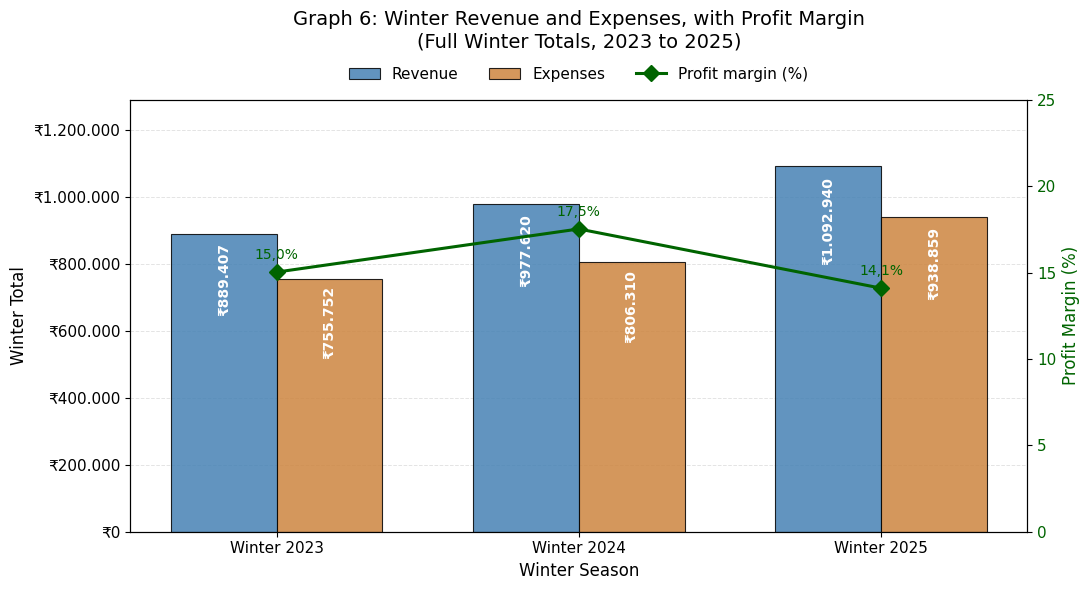


  GRAPH 6 INTERPRETATION

  This chart sets each winter's revenue against its expenses, one pair of bars
  per season, and draws the profit margin as a line on the right-hand scale. The
  blue bar is total revenue, the brown bar next to it is total expenses, and the
  green line is the margin left once expenses were paid. The two need reading
  together, because a taller revenue bar means little if the expense bar grew
  with it.

  Revenue rises in every winter, and Winter 2025 is the tallest revenue bar on
  the chart. Expenses rise alongside it, and in the last winter they rise faster:
  expenses grew by ₹132.549 while revenue grew by
  ₹115.320. Because expenses grew by more than revenue, the gap
  between the two bars, which is the profit, narrowed.

  The green line shows the cost of that. Profit fell from ₹171.310
  in Winter 2024 to ₹154.081 in Winter 2025, and the margin dropped
  3,4 points in the same step. So the season that earned
  the most kept the smallest share of it:

In [211]:
# GRAPH 6
# Winter revenue and expenses side by side per season, with the profit margin
# as a line on a second axis.

# per-winter profitability figures from Section 6.4
g6_winters   = ["2023", "2024", "2025"]
g6_revenue   = [profit_data[w]["revenue"]  for w in g6_winters]
g6_expenses  = [profit_data[w]["expenses"] for w in g6_winters]
g6_margins   = [profit_data[w]["margin"]   for w in g6_winters]

g6_bar_width    = 0.35
g6_money_head   = 1.18   # headroom so the tallest bar clears the legend row
g6_margin_top   = 25     # right-axis ceiling (%), a little above the highest margin
g6_margin_lift  = 0.6    # gap (%) above a margin point for its label
g6_label_frac   = 0.97   # money label sits just inside the top of its bar

g6_positions = np.arange(len(g6_winters))
g6_xlabels   = ["Winter " + w for w in g6_winters]

fig, ax_money = plt.subplots(figsize=(11, 6))
ax_money.set_axisbelow(True)

bars_revenue = ax_money.bar(
    g6_positions - g6_bar_width / 2, g6_revenue,
    width=g6_bar_width, color="steelblue",
    edgecolor="black", linewidth=0.8, alpha=0.85, label="Revenue",
)
bars_expenses = ax_money.bar(
    g6_positions + g6_bar_width / 2, g6_expenses,
    width=g6_bar_width, color="peru",
    edgecolor="black", linewidth=0.8, alpha=0.85, label="Expenses",
)

# winter totals are six-digit, too wide to sit flat, so each value is rotated
# upright and reads down from just inside the top of its bar
for bar_group in (bars_revenue, bars_expenses):
    for bar in bar_group:
        height = bar.get_height()
        ax_money.text(bar.get_x() + bar.get_width() / 2, height * g6_label_frac,
                      "₹" + fmt(height), ha="center", va="top", rotation=90,
                      fontsize=10, color="white", fontweight="bold")

ax_money.set_xlabel("Winter Season", fontsize=12)
ax_money.set_ylabel("Winter Total", fontsize=12)
ax_money.set_xticks(g6_positions)
ax_money.set_xticklabels(g6_xlabels, fontsize=11)
ax_money.yaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax_money.tick_params(axis="y", labelsize=11)
ax_money.set_ylim(0, max(g6_revenue) * g6_money_head)
ax_money.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)

# profit margin needs its own scale, so a second y-axis
ax_margin = ax_money.twinx()
ax_margin.plot(g6_positions, g6_margins, color="darkgreen", marker="D",
               markersize=8, linewidth=2.2, label="Profit margin (%)")
for x_pos, margin_val in zip(g6_positions, g6_margins):
    ax_margin.text(x_pos, margin_val + g6_margin_lift, fmt(margin_val, 1) + "%",
                   ha="center", va="bottom", fontsize=10, color="darkgreen")
ax_margin.set_ylabel("Profit Margin (%)", fontsize=12, color="darkgreen")
ax_margin.tick_params(axis="y", labelsize=11, labelcolor="darkgreen")
ax_margin.set_ylim(0, g6_margin_top)

ax_money.set_title(
    "Graph 6: Winter Revenue and Expenses, with Profit Margin\n"
    "(Full Winter Totals, 2023 to 2025)",
    fontsize=14, pad=38,
)

handles_money,  labels_money  = ax_money.get_legend_handles_labels()
handles_margin, labels_margin = ax_margin.get_legend_handles_labels()
ax_money.legend(handles_money + handles_margin, labels_money + labels_margin,
                fontsize=11, framealpha=0.92,
                loc="lower center", bbox_to_anchor=(0.5, 1.01),
                ncol=3, frameon=False)

plt.tight_layout()
plt.savefig("graph6_revenue_expenses_margin.png", dpi=150, bbox_inches="tight")
plt.show()

# steps the prose needs, from the reused figures
g6_rev_step_2425    = profit_data["2025"]["revenue"]  - profit_data["2024"]["revenue"]
g6_exp_step_2425    = profit_data["2025"]["expenses"] - profit_data["2024"]["expenses"]
g6_profit_2024      = profit_data["2024"]["profit"]
g6_profit_2025      = profit_data["2025"]["profit"]
g6_margin_drop_2425 = profit_data["2024"]["margin"] - profit_data["2025"]["margin"]

print()
print("=" * 70)
print("  GRAPH 6 INTERPRETATION")
print("=" * 70)
print(f"""
  This chart sets each winter's revenue against its expenses, one pair of bars
  per season, and draws the profit margin as a line on the right-hand scale. The
  blue bar is total revenue, the brown bar next to it is total expenses, and the
  green line is the margin left once expenses were paid. The two need reading
  together, because a taller revenue bar means little if the expense bar grew
  with it.

  Revenue rises in every winter, and Winter 2025 is the tallest revenue bar on
  the chart. Expenses rise alongside it, and in the last winter they rise faster:
  expenses grew by ₹{fmt(g6_exp_step_2425)} while revenue grew by
  ₹{fmt(g6_rev_step_2425)}. Because expenses grew by more than revenue, the gap
  between the two bars, which is the profit, narrowed.

  The green line shows the cost of that. Profit fell from ₹{fmt(g6_profit_2024)}
  in Winter 2024 to ₹{fmt(g6_profit_2025)} in Winter 2025, and the margin dropped
  {fmt(g6_margin_drop_2425, 1)} points in the same step. So the season that earned
  the most kept the smallest share of it: the margin fell to its lowest while
  revenue was at its highest.

  The reading here is narrower than the revenue graphs alone would suggest. The
  tandoor raised revenue, which the earlier graphs showed, but total expenses
  rose faster than revenue this winter, so the margin fell. How much of that
  expense rise is the tandoor's own running cost, and how much is the wider cost
  base (food, labour, GST), is separated in Section 6.2, and Section 6.3 shows the
  tandoor's extra revenue still clears that running cost. Whether the margin drop is a
  temporary start-up cost or a lasting drag is not something these three winters
  can settle on their own.
""")

## SECTION 7: SENSITIVITY ANALYSIS


In [212]:
# SECTION 7: SENSITIVITY ANALYSIS

print()
print("=" * 72)
print("  SECTION 7: SENSITIVITY ANALYSIS")
print("=" * 72)
print("""  Sections 5 and 6 established the main result. This section stress-tests
  it: each scenario re-runs the comparison under a different assumption a
  sceptical reader might raise, to see whether the conclusion survives.

  Verdict labels used through this section:
    Robust     the conclusion clearly holds under this scenario. For the
               statistical scenarios both tests stay significant with the
               direction and effect size kept; for the structural scenario the
               effect stays positive across all comparisons; for the
               cost scenario the tandoor still covers its running cost.
    Moderate   the conclusion still holds, but more weakly. The effect shrinks
               or significance becomes less emphatic, or the margin narrows, so
               the result depends more on a favourable assumption.
    Fragile    the conclusion does not hold. The direction reverses or
               significance is lost, the structural effect turns negative, or
               running cost exceeds the extra revenue.
    Benchmark  the original main-analysis result (Sections 5 and 6), the
               reference point the five stress tests are compared against. It
               is not itself a stress test.

  Each sub-section (7.1 to 7.5) ends with one of these labels; Section 7.6
  collects them into a single summary table.""")


# 7.1  Scenario A: Include Closed Days as Zero Revenue

def get_winter_all_days(year_start):
    """All calendar days for one winter (Nov-Dec of year_start plus Jan-Feb of
    year_start+1). Closed days have revenue 0."""
    nov_dec = daily_sales[
        (daily_sales["year"] == year_start) &
        (daily_sales["month_num"].isin([11, 12]))
    ].copy()
    jan_feb = daily_sales[
        (daily_sales["year"] == year_start + 1) &
        (daily_sales["month_num"].isin([1, 2]))
    ].copy()
    df = pd.concat([nov_dec, jan_feb], ignore_index=True)
    df["revenue"] = df["revenue"].fillna(0)
    df["is_diwali"] = False
    if year_start in DIWALI_WINDOWS:
        dw_start, dw_end = DIWALI_WINDOWS[year_start]
        df["is_diwali"] = df["date"].between(dw_start, dw_end)
    return df

w2023_all = get_winter_all_days(2023)
w2024_all = get_winter_all_days(2024)
w2025_all = get_winter_all_days(2025)

w2023_all_nd = w2023_all[~w2023_all["is_diwali"]]
w2024_all_nd = w2024_all[~w2024_all["is_diwali"]]

base_incl_rev = pd.concat(
    [w2023_all_nd["revenue"], w2024_all_nd["revenue"]],
    ignore_index=True
).values
post_incl_rev = w2025_all["revenue"].values

ttest_incl_stat, ttest_incl_pval = stats.ttest_ind(post_incl_rev, base_incl_rev, equal_var=False)
mwu_incl_stat, mwu_incl_pval = stats.mannwhitneyu(post_incl_rev, base_incl_rev, alternative="two-sided")

n_incl_base, n_incl_post = len(base_incl_rev), len(post_incl_rev)
s_incl_base, s_incl_post = np.std(base_incl_rev, ddof=1), np.std(post_incl_rev, ddof=1)
pooled_sd_incl = np.sqrt(
    ((n_incl_base - 1) * s_incl_base**2 + (n_incl_post - 1) * s_incl_post**2)
    / (n_incl_base + n_incl_post - 2)
)
cohens_d_incl = (np.mean(post_incl_rev) - np.mean(base_incl_rev)) / pooled_sd_incl
diff_incl = np.mean(post_incl_rev) - np.mean(base_incl_rev)
pct_incl = diff_incl / np.mean(base_incl_rev) * 100

ttest_incl_pval_str = p_value_str(ttest_incl_pval)
mwu_incl_pval_str = p_value_str(mwu_incl_pval)

print()
print("  7.1  Scenario A: Include Closed Days as Zero Revenue")
print("  " + "-" * 72)
print(f"""  Both baseline (2023+2024 Non-Diwali) and Winter 2025 are expanded to
  include all calendar days. Closed days are scored as ₹0 rather than
  excluded. This lowers both group means and raises variance; the question
  is whether the direction and significance hold.

  Note: all closed days in the dataset are non-holiday closures (staff
  shortages, maintenance, data gaps). No Diwali days fall on closed days.

  Calendar days in window:
    Baseline 2023+2024 combined : {n_incl_base} days  (vs {len(baseline_rev)} Non-Diwali operating days)
    Winter 2025                 : {n_incl_post} days  (vs {len(post_rev)} operating days)

  Mean revenue (inclusive):
    Baseline mean : ₹{fmt(np.mean(base_incl_rev))}  (vs ₹{fmt(m_comb['mean'])} operating-only)
    Winter 2025   : ₹{fmt(np.mean(post_incl_rev))}  (vs ₹{fmt(m_25['mean'])} operating-only)
    Difference    : ₹{fmt(diff_incl)} ({('+' if pct_incl >= 0 else '')}{fmt(pct_incl, 1)}%)
""")

print(f"  {'Test':<28} {'Statistic':>14} {'p-value':>12} {'Result':>13}")
print("  " + "-" * 70)
print(f"  {'Welch t-test':<28} {'t = '+fmt(ttest_incl_stat, 4):>14} {ttest_incl_pval_str:>12} "
      f"{'Yes' if ttest_incl_pval < ALPHA else 'No':>13}")
print(f"  {'Mann-Whitney U':<28} {'U = '+fmt(mwu_incl_stat):>14} {mwu_incl_pval_str:>12} "
      f"{'Yes' if mwu_incl_pval < ALPHA else 'No':>13}")
print(f"  {'Cohen\'s d':<28} {'d = '+fmt(cohens_d_incl, 4):>14} {'-':>12} "
      f"{effect_size_label(cohens_d_incl):>13}")

print(f"""
  Both tests stay significant with closed days included. Cohen's d = {fmt(cohens_d_incl, 3)}
  ({effect_size_label(cohens_d_incl).lower()} effect) is {'smaller' if abs(cohens_d_incl) < abs(cohens_d_main) else 'larger'} than
  the main analysis ({fmt(cohens_d_main, 3)}), which is expected: adding zero-revenue
  days lowers both means and raises variance more in the baseline, since it
  carries more closed-day variation. The direction and significance of the
  main finding hold under this scenario.

  Note: this compares a pooled two-year baseline ({n_incl_base} days) against a
  single-year post period ({n_incl_post} days), so it is a directional robustness
  check, not a strict statistical parallel. It is also a mild test by design:
  only {n_incl_base - len(baseline_rev)} closed days exist in the baseline and
  {n_incl_post - len(post_rev)} in Winter 2025, so scoring them as zero shifts the
  means only slightly.

  Verdict: Robust. Counting closed days as zero barely changes the result; the
  tandoor effect holds in direction, size, and significance.""")
print()


# 7.2  Scenario B: Alternative Baseline (2024-Only)

# pre_24_rev and pre_23_rev are reused from Section 5
ttest_alt = stats.ttest_ind(post_rev, pre_24_rev, equal_var=False)
ttest_alt_stat, ttest_alt_pval = ttest_alt.statistic, ttest_alt.pvalue
mwu_alt_stat, mwu_alt_pval = stats.mannwhitneyu(post_rev, pre_24_rev, alternative="two-sided")

n_alt_base, n_alt_post = len(pre_24_rev), len(post_rev)
s_alt_base, s_alt_post = np.std(pre_24_rev, ddof=1), np.std(post_rev, ddof=1)
pooled_sd_alt = np.sqrt(
    ((n_alt_base - 1) * s_alt_base**2 + (n_alt_post - 1) * s_alt_post**2)
    / (n_alt_base + n_alt_post - 2)
)

cohens_d_alt = (m_25["mean"] - m_24_nd["mean"]) / pooled_sd_alt
diff_alt = m_25["mean"] - m_24_nd["mean"]
pct_alt = diff_alt / m_24_nd["mean"] * 100

# degrees of freedom for the 95% CI, as returned by scipy
df_welch_alt = ttest_alt.df
se_diff_alt = np.sqrt(s_alt_base**2 / n_alt_base + s_alt_post**2 / n_alt_post)
t_crit_alt = stats.t.ppf(1 - ALPHA/2, df=df_welch_alt)
ci_lower_alt = diff_alt - t_crit_alt * se_diff_alt
ci_upper_alt = diff_alt + t_crit_alt * se_diff_alt

# trend-continuation projection from the 2023 to 2024 growth rate
trend_abs = m_24_nd["mean"] - m_23_nd["mean"]
predicted_2025_abs = m_24_nd["mean"] + trend_abs
growth_rate = trend_abs / m_23_nd["mean"]
predicted_increase_rupees = m_24_nd["mean"] * growth_rate
predicted_2025_from_pct_growth = m_24_nd["mean"] + predicted_increase_rupees

ttest_alt_pval_str = p_value_str(ttest_alt_pval)
mwu_alt_pval_str = p_value_str(mwu_alt_pval)
d_category_alt = effect_size_label(cohens_d_alt)

# reduction in observed gap vs the main analysis (mean_diff_main from Section 4.1)
reduction_vs_main = mean_diff_main - diff_alt

print()
print("  7.2  Scenario B: Alternative Baseline (2024-Only)")
print("  " + "-" * 70)
print(f"""  This is the most demanding of the baseline comparisons. If the 2025
  improvement is just the continuation of an existing growth trend
  (2023 to 2024: {('+' if growth_rate*100 >= 0 else '')}{fmt(growth_rate*100, 1)}%),
  comparing Winter 2025 against the higher 2024 baseline should reduce or
  remove significance. If significance and effect size survive, the result
  cannot be explained by trend continuation alone.

  Baseline: Winter 2024 Non-Diwali only (n = {n_alt_base} operating days)
  Post: Winter 2025 (n = {n_alt_post} operating days)

  Means:
    Winter 2024 (baseline) : ₹{fmt(m_24_nd["mean"])}
    Winter 2025            : ₹{fmt(m_25["mean"])}
    Difference             : ₹{fmt(diff_alt)} ({('+' if pct_alt >= 0 else '')}{fmt(pct_alt, 1)}%)

  Comparison to main analysis:
    Main analysis difference  : ₹{fmt(mean_diff_main)} ({('+' if mean_pct >= 0 else '')}{fmt(mean_pct, 1)}%)
    2024-only difference       : ₹{fmt(diff_alt)} ({('+' if pct_alt >= 0 else '')}{fmt(pct_alt, 1)}%)
    Reduction in observed gap  : ₹{fmt(reduction_vs_main)}

  As expected, the gap is smaller against the higher 2024 baseline. The
  question is whether it stays statistically and practically significant.
""")

print(f"  {'Test':<28} {'Statistic':>14} {'p-value':>12} {'Result':>13}")
print("  " + "-" * 70)
print(f"  {'Welch t-test':<28} {'t = '+fmt(ttest_alt_stat, 4):>14} {ttest_alt_pval_str:>12} "
      f"{'Yes' if ttest_alt_pval < ALPHA else 'No':>13}")
print(f"  {'Mann-Whitney U':<28} {'U = '+fmt(mwu_alt_stat):>14} {mwu_alt_pval_str:>12} "
      f"{'Yes' if mwu_alt_pval < ALPHA else 'No':>13}")
print(f"  {'Cohen\'s d':<28} {'d = '+fmt(cohens_d_alt, 4):>14} {'-':>12} {d_category_alt:>13}")
print(f"  {'95% CI (₹ per day)':<28} {'['+fmt(ci_lower_alt)+' - '+fmt(ci_upper_alt)+']':>14}")

print(f"""
  Against the harder 2024-only baseline, both Welch's t-test (p {ttest_alt_pval_str})
  and Mann-Whitney U (p {mwu_alt_pval_str}) stay significant. Cohen's d = {fmt(cohens_d_alt, 3)},
  {d_category_alt.lower()} by Cohen (1988). The effect size is smaller than the main
  analysis (d = {fmt(cohens_d_main, 3)}), as expected against a higher baseline. The 95%
  CI excludes zero: ₹{fmt(ci_lower_alt)} to ₹{fmt(ci_upper_alt)} per operating day.

  This addresses the trend-continuation objection directly. Pure continuation
  of the 2023 to 2024 growth would predict a 2025 mean of ₹{fmt(predicted_2025_abs)}
  if the same absolute increase (₹{fmt(trend_abs)}/day) continues, or
  ₹{fmt(predicted_2025_from_pct_growth)} if the same percentage growth
  ({('+' if growth_rate*100 >= 0 else '')}{fmt(growth_rate*100, 1)}%) continues. The observed Winter 2025 mean of
  ₹{fmt(m_25["mean"])} exceeds both, and the observed gap of ₹{fmt(diff_alt)}/day
  exceeds either extrapolated trend while staying significant.

  Note: these trend predictions are illustrative extrapolations, not formal
  forecasts. They bound the trend-continuation objection rather than predict
  2025 revenue. Restaurant revenue growth usually saturates toward
  market-average rates as the business matures.

  Verdict: Moderate. Against the harder 2024-only baseline the effect shrinks
  and weakens, but stays positive and significant; the result holds, less
  strongly.""")
print()


# 7.3  Scenario C: Exclude Top 5% Outliers

def run_trim_test(base_arr, post_arr, trim_pct):
    """Run Welch t-test and Mann-Whitney on top-trimmed data. Returns a dict of
    raw values; the caller formats them."""
    p_base = np.percentile(base_arr, 100 - trim_pct)
    p_post = np.percentile(post_arr, 100 - trim_pct)
    base_t = base_arr[base_arr <= p_base]
    post_t = post_arr[post_arr <= p_post]
    ttest_stat, ttest_pval = stats.ttest_ind(post_t, base_t, equal_var=False)
    mwu_stat, mwu_pval = stats.mannwhitneyu(post_t, base_t, alternative="two-sided")
    n_b, n_p = len(base_t), len(post_t)
    s_b, s_p = np.std(base_t, ddof=1), np.std(post_t, ddof=1)
    pooled_sd = np.sqrt(((n_b - 1) * s_b**2 + (n_p - 1) * s_p**2) / (n_b + n_p - 2))
    mean_b, mean_p = np.mean(base_t), np.mean(post_t)
    mean_diff = mean_p - mean_b
    cohens_d = mean_diff / pooled_sd
    return {
        "p_base": p_base, "p_post": p_post,
        "n_removed_base": len(base_arr) - n_b,
        "n_removed_post": len(post_arr) - n_p,
        "n_base": n_b, "n_post": n_p,
        "mean_base": mean_b, "mean_post": mean_p,
        "mean_diff": mean_diff,
        "pct_diff": mean_diff / mean_b * 100,
        "ttest_stat": ttest_stat, "mwu_stat": mwu_stat,
        "ttest_pval": ttest_pval, "mwu_pval": mwu_pval,
        "cohens_d": cohens_d,
    }

trim_1 = run_trim_test(baseline_rev, post_rev, 1)
trim_5 = run_trim_test(baseline_rev, post_rev, 5)
trim_10 = run_trim_test(baseline_rev, post_rev, 10)

# significant only if both tests clear alpha at that trim level
sig_1  = "Yes" if (trim_1['ttest_pval']  < ALPHA and trim_1['mwu_pval']  < ALPHA) else "No"
sig_5  = "Yes" if (trim_5['ttest_pval']  < ALPHA and trim_5['mwu_pval']  < ALPHA) else "No"
sig_10 = "Yes" if (trim_10['ttest_pval'] < ALPHA and trim_10['mwu_pval'] < ALPHA) else "No"

# 5% values into plain names so the f-strings stay quote-clean
t5_stat = trim_5["ttest_stat"]
u5_stat = trim_5["mwu_stat"]
d5 = trim_5["cohens_d"]

print()
print("  7.3  Scenario C: Exclude Top 5% Outliers")
print("  " + "-" * 60)
print(f"""  The top 5% of revenue days are excluded from both groups independently.
  This removes catering events, private bookings, and any days that could
  inflate the difference. Each threshold is taken on its own group, not a
  global percentile.

  The 5% threshold removes roughly 1-2 days per winter month across the
  pooled baseline, taken to correspond to catering and private events. To
  check the choice does not drive the result, the analysis is repeated at
  1% and 10%.

  Outlier thresholds:
    Baseline P95    : ₹{fmt(trim_5['p_base'])}  (days above this excluded from baseline)
    Winter 2025 P95 : ₹{fmt(trim_5['p_post'])}  (days above this excluded from W2025)

  Days excluded:
    From baseline    : {trim_5['n_removed_base']} days removed, n = {trim_5['n_base']}
    From Winter 2025 : {trim_5['n_removed_post']} days removed, n = {trim_5['n_post']}

  Trimmed means:
    Baseline (trimmed)    : ₹{fmt(trim_5['mean_base'])}
    Winter 2025 (trimmed) : ₹{fmt(trim_5['mean_post'])}
    Difference            : ₹{fmt(trim_5['mean_diff'])} ({('+' if trim_5['pct_diff'] >= 0 else '')}{fmt(trim_5['pct_diff'], 1)}%)
""")

print(f"  {'Test':<28} {'Statistic':>14} {'p-value':>12} {'Result':>13}")
print("  " + "-" * 70)
print(f"  {'Welch t-test':<28} {'t = '+fmt(t5_stat, 4):>14} {p_value_str(trim_5['ttest_pval']):>12} "
      f"{'Yes' if trim_5['ttest_pval'] < ALPHA else 'No':>13}")
print(f"  {'Mann-Whitney U':<28} {'U = '+fmt(u5_stat):>14} {p_value_str(trim_5['mwu_pval']):>12} "
      f"{'Yes' if trim_5['mwu_pval'] < ALPHA else 'No':>13}")
print(f"  {'Cohen\'s d':<28} {'d = '+fmt(d5, 4):>14} {'-':>12} {effect_size_label(d5):>13}")

print(f"""
  Robustness across trimming levels:

  {'Trim Level':<12} {'Base n':>8} {'Post n':>8} {'Mean Diff':>14} {'Cohen d':>9} {'p (t)':>10} {'p (MW)':>10} {'Sig?':>5}
  {'-'*82}
  {'1% trim':<12} {trim_1['n_base']:>8} {trim_1['n_post']:>8} {'₹'+fmt(trim_1['mean_diff']):>14} {fmt(trim_1['cohens_d'], 4):>9} {p_value_str(trim_1['ttest_pval']):>10} {p_value_str(trim_1['mwu_pval']):>10} {sig_1:>5}
  {'5% trim':<12} {trim_5['n_base']:>8} {trim_5['n_post']:>8} {'₹'+fmt(trim_5['mean_diff']):>14} {fmt(trim_5['cohens_d'], 4):>9} {p_value_str(trim_5['ttest_pval']):>10} {p_value_str(trim_5['mwu_pval']):>10} {sig_5:>5}
  {'10% trim':<12} {trim_10['n_base']:>8} {trim_10['n_post']:>8} {'₹'+fmt(trim_10['mean_diff']):>14} {fmt(trim_10['cohens_d'], 4):>9} {p_value_str(trim_10['ttest_pval']):>10} {p_value_str(trim_10['mwu_pval']):>10} {sig_10:>5}
  {'-'*82}

  The effect size grows with more aggressive trimming (d = {fmt(trim_1['cohens_d'], 3)} at 1%,
  {fmt(trim_5['cohens_d'], 3)} at 5%, {fmt(trim_10['cohens_d'], 3)} at 10%), which means the outliers were
  holding the apparent effect down in the baseline, not inflating it. That is
  the opposite of what a sceptic would predict: if exceptional days drove the
  result, trimming them would shrink the effect. Instead it grows, so the
  tandoor's effect sits across ordinary operating days, not a few high-revenue
  events.

  Verdict: Robust. Removing the highest-revenue days makes the effect stronger,
  not weaker, so the result is not driven by a handful of exceptional days.""")
print()


  SECTION 7: SENSITIVITY ANALYSIS
  Sections 5 and 6 established the main result. This section stress-tests
  it: each scenario re-runs the comparison under a different assumption a
  sceptical reader might raise, to see whether the conclusion survives.

  Verdict labels used through this section:
    Robust     the conclusion clearly holds under this scenario. For the
               statistical scenarios both tests stay significant with the
               direction and effect size kept; for the structural scenario the
               effect stays positive across all comparisons; for the
               cost scenario the tandoor still covers its running cost.
    Moderate   the conclusion still holds, but more weakly. The effect shrinks
               or significance becomes less emphatic, or the margin narrows, so
               the result depends more on a favourable assumption.
    Fragile    the conclusion does not hold. The direction reverses or
               significance is lost,

In [213]:
# 7.4  Scenario D: Diwali-Adjusted Winter 2025

# Diwali day counts as operating days in the winter window (so a 5-day window
# can count fewer if some days were closed or outside the tagged month)
diwali_days_2023 = w2023["is_diwali"].sum()
diwali_days_2024 = w2024["is_diwali"].sum()
avg_diwali_days = (diwali_days_2023 + diwali_days_2024) / 2

# missing Diwali lift for W2025, spread across its operating days
missing_diwali_total   = avg_premium * avg_diwali_days
missing_diwali_per_day = missing_diwali_total / m_25["n_days"]

# Winter 2025 mean with the missing Diwali lift added back
adjusted_mean_2025 = m_25["mean"] + missing_diwali_per_day

# full baseline, Diwali days included
m_base_full = describe_winter(
    pd.concat([w2023, w2024], ignore_index=True),
    "Combined 2023+2024, Full (Diwali included)"
)

# comparison 1 reuses mean_diff_main / mean_pct from Sections 4.1 and 5
diff_raw = m_25["mean"] - m_base_full["mean"]
pct_raw = diff_raw / m_base_full["mean"] * 100
diff_adj = adjusted_mean_2025 - m_base_full["mean"]
pct_adj = diff_adj / m_base_full["mean"] * 100

print()
print("  7.4  Scenario D: Diwali-Adjusted Winter 2025")
print("  " + "-" * 70)
print("""  Winter 2025 had no Diwali days (Diwali fell before 1 November), which
  made it a clean test but also means it missed the Diwali premium both
  baseline winters received. This scenario runs three comparisons and asks
  which is fairest and whether all three point the same way.""")

print()
print("  TABLE 7.4  Three Comparison Methods: Diwali Treatment")
print()
print(f"  {'Comparison':<42} {'Baseline Mean':>14} {'W2025 Mean':>14} {'Difference':>12} {'Change':>10}")
print("  " + "-" * 100)
print(f"  {'1. Main analysis (Non-Diwali vs Non-Diwali)':<42} "
      f"{'₹'+fmt(m_comb['mean']):>13} {'₹'+fmt(m_25['mean']):>14} "
      f"{'₹'+fmt(mean_diff_main):>12} {('+' if mean_pct >= 0 else '')+fmt(mean_pct, 1)+'%':>10}")
print(f"  {'2. Raw (Full baseline vs Raw W2025)':<42} "
      f"{'₹'+fmt(m_base_full['mean']):>14} {'₹'+fmt(m_25['mean']):>14} "
      f"{'₹'+fmt(diff_raw):>12} {('+' if pct_raw >= 0 else '')+fmt(pct_raw, 1)+'%':>10}")
print(f"  {'3. Adjusted (Full baseline vs Adj. W2025)':<42} "
      f"{'₹'+fmt(m_base_full['mean']):>14} {'₹'+fmt(adjusted_mean_2025):>14} "
      f"{'₹'+fmt(diff_adj):>12} {('+' if pct_adj >= 0 else '')+fmt(pct_adj, 1)+'%':>10}")
print("  " + "-" * 100)

print()
print(f"  {'Fairness assessment':<42} {'Label':>22}")
print("  " + "-" * 66)
print(f"  {'1. Main analysis':<42} {'Fair, primary':>22}")
print(f"  {'2. Raw comparison':<42} {'Unfair to W2025':>22}")
print(f"  {'3. Adjusted comparison':<42} {'Fair but hypothetical':>22}")
print("  " + "-" * 66)

print()
print("  Diwali adjustment calculation:")
print("  " + "-" * 48)
print(f"  {'Winter 2023 Diwali days in window':<38} {diwali_days_2023:>8}")
print(f"  {'Winter 2024 Diwali days in window':<38} {diwali_days_2024:>8}")
print(f"  {'Average Diwali days':<38} {fmt(avg_diwali_days, 1):>8}")
print(f"  {'Average Diwali premium (Section 3.3)':<38} {'₹'+fmt(avg_premium):>8}")
print(f"  {'Total missing Diwali lift for W2025':<38} {'₹'+fmt(missing_diwali_total):>8}")
print(f"  {'Spread over '+str(m_25['n_days'])+' operating days':<38} {'₹'+fmt(missing_diwali_per_day)+'/day':>8}")
print("  " + "-" * 48)

print(f"""
  The main analysis (Row 1) is the fairest comparison: both sides exclude
  Diwali days, so neither gets a festival boost. This is the method used
  through Sections 3 to 6, and it yields {('+' if mean_pct >= 0 else '')}{fmt(mean_pct, 1)}%.

  The raw comparison (Row 2) is unfair to Winter 2025: the baseline includes
  Diwali revenue (₹{fmt(m_base_full['mean'])} mean) while Winter 2025 has none
  (₹{fmt(m_25['mean'])} mean). Even so, Winter 2025 still comes out ahead by
  {('+' if pct_raw >= 0 else '')}{fmt(pct_raw, 1)}%. This is the conservative reading.

  The adjusted comparison (Row 3) asks what Winter 2025 would look like with the
  same Diwali boost as the baseline winters. The simulated mean rises to
  ₹{fmt(adjusted_mean_2025)}, and the gap becomes {('+' if pct_adj >= 0 else '')}{fmt(pct_adj, 1)}%, close to
  the main analysis.

  All three point the same way. The {('+' if mean_pct >= 0 else '')}{fmt(mean_pct, 1)}% main analysis sits at
  the upper end of the plausible range because stripping Diwali from the
  baseline removes a festival boost W2025 never had, a methodological choice,
  not an optimistic one.

  Verdict: Robust. Every way of treating Diwali leaves the effect positive,
  including the comparison built to disadvantage Winter 2025.""")
print()


# 7.5  Scenario E: High Coal Cost (11 kg/day)

# base case (10 kg/day) is COAL_KG_PER_DAY from Section 6
COAL_KG_LOW = 9          # best-case consumption
COAL_KG_HIGH = 11        # worst-case consumption

coal_cost_low = COAL_KG_LOW * COAL_PRICE_PER_KG    # ₹342/day
coal_cost_high = COAL_KG_HIGH * COAL_PRICE_PER_KG  # ₹418/day

# running costs by scenario; base case reuses tandoor_fuel_2025,
# tandoor_chef_2025, tandoor_cost_2025 from Section 6.2
tandoor_fuel_low = m_25["n_days"] * coal_cost_low
tandoor_fuel_high = m_25["n_days"] * coal_cost_high

tandoor_cost_low = tandoor_fuel_low + tandoor_chef_2025
tandoor_cost_high = tandoor_fuel_high + tandoor_chef_2025

# profitability by scenario; base case reuses profit_data["2025"]
fuel_diff_high = tandoor_fuel_high - tandoor_fuel_2025
profit_high = profit_data["2025"]["profit"] - fuel_diff_high
margin_high = (profit_high / profit_data["2025"]["revenue"]) * 100
margin_change_high = margin_high - profit_data["2025"]["margin"]

fuel_diff_low = tandoor_fuel_2025 - tandoor_fuel_low
profit_low = profit_data["2025"]["profit"] + fuel_diff_low
margin_low = (profit_low / profit_data["2025"]["revenue"]) * 100

# coverage ratios; extra revenue is the Non-Diwali figure from Section 6.1
coverage_low = extra_total / tandoor_cost_low
coverage_base = extra_total / tandoor_cost_2025
coverage_high = extra_total / tandoor_cost_high

# break-even; observed_daily_gain reuses mean_diff_main (Section 5)
breakeven_daily_high = tandoor_cost_high / m_25["n_days"]
observed_daily_gain = mean_diff_main

print()
print("  7.5  Scenario E: High Coal Cost (11 kg/day)")
print("  " + "-" * 75)
print(f"""  Observed coal use ran from {COAL_KG_LOW} to {COAL_KG_HIGH} kg per operating day, around a mean of
  {COAL_KG_PER_DAY} kg/day (₹{fmt(COAL_COST_PER_DAY)}/day) used in the main analysis. Coal is
  the only estimated tandoor input, since the chef salary is a fixed contracted cost, so
  it is the variable to stress. This takes the worst case ({COAL_KG_HIGH} kg/day); the best
  case ({COAL_KG_LOW} kg/day) is shown for completeness. The narrow cost range
  (₹{fmt(coal_cost_low)} to ₹{fmt(coal_cost_high)}/day) does not materially change the conclusion.

  Cost comparison:
    Low coal cost  ({COAL_KG_LOW} kg/day)  : {m_25["n_days"]} days x ₹{fmt(coal_cost_low)}  = ₹{fmt(tandoor_fuel_low)}
    Base coal cost ({COAL_KG_PER_DAY} kg/day) : {m_25["n_days"]} days x ₹{fmt(COAL_COST_PER_DAY)}  = ₹{fmt(tandoor_fuel_2025)}
    High coal cost ({COAL_KG_HIGH} kg/day) : {m_25["n_days"]} days x ₹{fmt(coal_cost_high)}  = ₹{fmt(tandoor_fuel_high)}
    Additional cost (high vs base)  : +₹{fmt(fuel_diff_high)}

  Total tandoor running cost by scenario:
    Low ({COAL_KG_LOW} kg)   : ₹{fmt(tandoor_fuel_low)} fuel + ₹{fmt(tandoor_chef_2025)} chef = ₹{fmt(tandoor_cost_low)}
    Base ({COAL_KG_PER_DAY} kg) : ₹{fmt(tandoor_fuel_2025)} fuel + ₹{fmt(tandoor_chef_2025)} chef = ₹{fmt(tandoor_cost_2025)}
    High ({COAL_KG_HIGH} kg) : ₹{fmt(tandoor_fuel_high)} fuel + ₹{fmt(tandoor_chef_2025)} chef = ₹{fmt(tandoor_cost_high)}
""")

print(f"  {'Scenario':<14} {'Net Profit':>16} {'Margin':>12} {'Coverage':>14}")
print("  " + "-" * 60)
print(f"  {'Low ('+str(COAL_KG_LOW)+' kg)':<14} {'₹'+fmt(profit_low):>16} {fmt(margin_low, 1)+'%':>12} {fmt(coverage_low, 2)+'x':>14}")
print(f"  {'Base ('+str(COAL_KG_PER_DAY)+' kg)':<14} {'₹'+fmt(profit_data['2025']['profit']):>16} {fmt(profit_data['2025']['margin'], 1)+'%':>12} {fmt(coverage_base, 2)+'x':>14}")
print(f"  {'High ('+str(COAL_KG_HIGH)+' kg)':<14} {'₹'+fmt(profit_high):>16} {fmt(margin_high, 1)+'%':>12} {fmt(coverage_high, 2)+'x':>14}")
print("  " + "-" * 60)

print(f"""
  Break-even (high-coal scenario):
    Break-even daily gain needed    : ₹{fmt(breakeven_daily_high)}/day
    Observed daily gain vs baseline : ₹{fmt(observed_daily_gain)}/day
    Surplus above break-even        : ₹{fmt(observed_daily_gain - breakeven_daily_high)}/day

  The tandoor covers its running cost across the full coal range ({COAL_KG_LOW} to {COAL_KG_HIGH}
  kg/day). Even at the worst case ({COAL_KG_HIGH} kg/day) the coverage ratio is {fmt(coverage_high, 2)}x
  (vs {fmt(coverage_base, 2)}x at base, {fmt(coverage_low, 2)}x at best). The margin compresses by only
  {fmt(abs(margin_change_high), 1)} percentage points under the stress test, and the break-even
  threshold (₹{fmt(breakeven_daily_high)}/day) is cleared by the observed daily gain
  (₹{fmt(observed_daily_gain)}/day).

  Verdict: Robust. Even at worst-case coal use the extra revenue still covers
  the tandoor's running cost with a clear surplus.""")
print()


  7.4  Scenario D: Diwali-Adjusted Winter 2025
  ----------------------------------------------------------------------
  Winter 2025 had no Diwali days (Diwali fell before 1 November), which
  made it a clean test but also means it missed the Diwali premium both
  baseline winters received. This scenario runs three comparisons and asks
  which is fairest and whether all three point the same way.

  TABLE 7.4  Three Comparison Methods: Diwali Treatment

  Comparison                                  Baseline Mean     W2025 Mean   Difference     Change
  ----------------------------------------------------------------------------------------------------
  1. Main analysis (Non-Diwali vs Non-Diwali)        ₹7.684         ₹9.341       ₹1.657     +21,6%
  2. Raw (Full baseline vs Raw W2025)                ₹8.013         ₹9.341       ₹1.328     +16,6%
  3. Adjusted (Full baseline vs Adj. W2025)          ₹8.013         ₹9.682       ₹1.669     +20,8%
  ----------------------------------------

In [214]:
# 7.6  Robustness Summary: All Scenarios

# main-analysis figures reuse Section 5; verdict labels match the per-scenario
# verdicts above
scenarios_summary = [
    ("Main analysis (Sections 5 and 6)",
     mean_diff_main, cohens_d_main, ttest_main_pval, mwu_main_pval, "Benchmark"),
    ("7.1 Closed days as zero (inclusive)",
     diff_incl, cohens_d_incl, ttest_incl_pval, mwu_incl_pval, "Robust"),
    ("7.2 2024-only baseline (conservative)",
     diff_alt, cohens_d_alt, ttest_alt_pval, mwu_alt_pval, "Moderate"),
    ("7.3 Exclude top 5% outliers",
     trim_5["mean_diff"], trim_5["cohens_d"], trim_5["ttest_pval"], trim_5["mwu_pval"], "Robust"),
    ("7.4 Diwali offset (structural, not a test)",
     diff_adj, None, None, None, "Robust"),
    ("7.5 High coal cost (profitability only)",
     None, None, None, None, "Robust"),
]
print()
print("  7.6  Robustness Summary: All Scenarios")
print("  " + "-" * 60)
print(f"""
  TABLE 7.6  Sensitivity Analysis Results: Full Summary
  {'Scenario':<40} {'Mean Diff':>14} {'Cohen d':>9} {'p (t)':>10} {'p (MW)':>10} {'Verdict':>10}
  {'-'*95}""")
for row in scenarios_summary:
    label, diff, d, p_t, p_mw, verdict = row
    diff_str = "₹" + fmt(diff) if diff is not None else "n/a"
    d_str = fmt(d, 3) if d is not None else "n/a"
    pt_str = p_value_str(p_t) if p_t is not None else "n/a"
    pmw_str = p_value_str(p_mw) if p_mw is not None else "n/a"
    print(f"  {label:<40} {diff_str:>14} {d_str:>9} {pt_str:>10} {pmw_str:>10} {verdict:>10}")
print(f"  {'-'*100}")
print(f"""
  Note:
  n/a means not applicable. Scenario 7.4 is a deterministic structural
  adjustment, so no sampling distribution exists. Scenario 7.5 is a
  profitability stress test, not a statistical hypothesis test.
  Scenario 7.4 compares adjusted W2025 against the full baseline (Diwali
  included), which is structurally different from the other rows (Non-Diwali vs
  Non-Diwali). Its ₹{fmt(diff_adj)} mean difference is not directly comparable to
  the main analysis figure of ₹{fmt(mean_diff_main)}.

  Every directional scenario points the same way as the main analysis, and none
  reverses the conclusion. The most demanding scenario, the 2024-only baseline
  that addresses the trend-continuation objection, still returns significant
  results, though the effect weakens to a smaller size (verdict: Moderate). The
  profitability conclusion survives even at maximum coal use. The tandoor result
  holds statistically and economically across the tested assumptions, with the
  2024-only baseline the one scenario where the effect is materially weaker.
  Note: robustness across assumptions does not replace replication across
  winters. All five scenarios still come from the same single post-intervention
  winter. Statistical power to detect sub-group effects (individual months,
  specific day-of-week patterns) stays limited. Winter 2026 data will show
  whether this is a stable effect or a particularly good first winter.""")
print()
print("=" * 82)


  7.6  Robustness Summary: All Scenarios
  ------------------------------------------------------------

  TABLE 7.6  Sensitivity Analysis Results: Full Summary
  Scenario                                      Mean Diff   Cohen d      p (t)     p (MW)    Verdict
  -----------------------------------------------------------------------------------------------
  Main analysis (Sections 5 and 6)                 ₹1.657     0,594    < 0,001    < 0,001  Benchmark
  7.1 Closed days as zero (inclusive)              ₹1.688     0,545    < 0,001    < 0,001     Robust
  7.2 2024-only baseline (conservative)            ₹1.250     0,424     0,0015    < 0,001   Moderate
  7.3 Exclude top 5% outliers                      ₹1.709     0,703    < 0,001    < 0,001     Robust
  7.4 Diwali offset (structural, not a test)         ₹1.669       n/a        n/a        n/a     Robust
  7.5 High coal cost (profitability only)             n/a       n/a        n/a        n/a     Robust
  -----------------------------

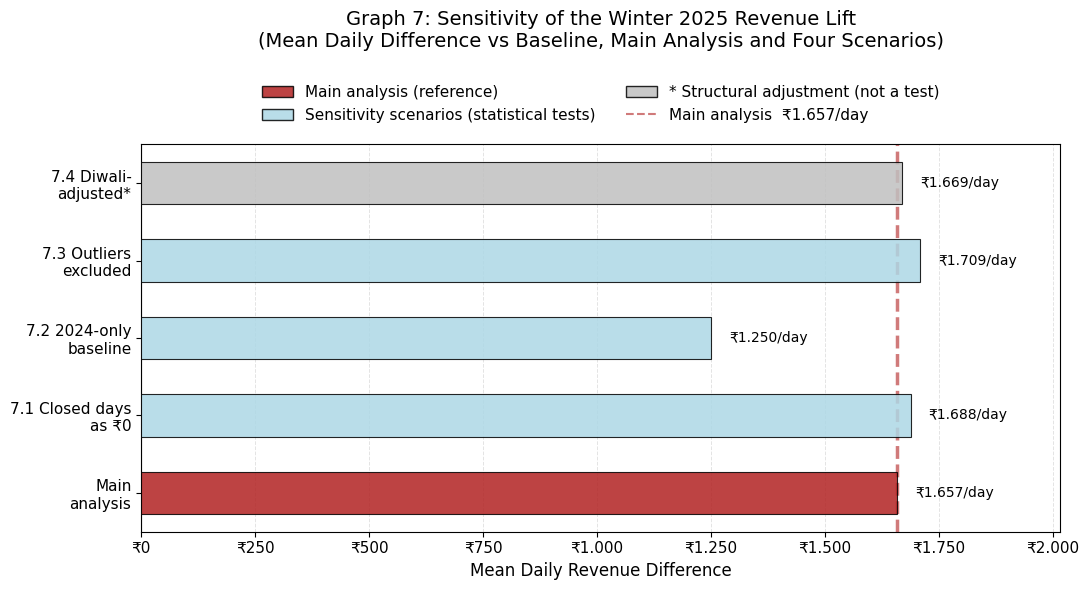


  GRAPH 7 INTERPRETATION

  This chart tests how much the Winter 2025 revenue lift depends on the choices
  made in the main analysis. Each bar re-runs the same comparison under a
  different reasonable assumption and reports the resulting gap between Winter
  2025 and the baseline, in ₹ per operating day. The red bar and the dashed red
  line mark the main analysis, so any scenario can be read as nearer to or
  further from that reference.

  All five bars point the same way and sit close together, between
  ₹1.250 and ₹1.709 per day. The 7.4 bar (silver)
  is a structural Diwali adjustment measured against the full baseline, not a
  like-for-like test, so it sits on this axis for orientation rather than strict
  comparison. None of them crosses zero, which means no reasonable change of
  method makes the lift disappear or reverse. The lift is not an artefact of one
  particular choice of method.

  The most demanding scenario is the 2024-only baseline, which compares Winter
  2025 a

In [215]:
# GRAPH 7
# Per-day revenue difference: main analysis against the four scenarios that
# also give a per-day figure. Horizontal bars because the labels are long.
# 7.5 (high coal) is a profitability test with no per-day figure, so it is
# not plotted.
g7_diff_main = mean_diff_main
g7_diff_incl = diff_incl
g7_diff_alt  = diff_alt
g7_diff_trim = trim_5["mean_diff"]
g7_diff_adj  = diff_adj

g7_bar_height = 0.55
g7_label_gap  = 40      # gap (₹) between a bar end and its value label
g7_ref_alpha  = 0.6
g7_zero_alpha = 0.5
g7_head       = 1.18    # headroom on the right for the value labels

# main is the reference (firebrick); 7.4 is silver because it is a structural
# adjustment, not a test
g7_labels = [
    "Main\nanalysis",
    "7.1 Closed days\nas ₹0",
    "7.2 2024-only\nbaseline",
    "7.3 Outliers\nexcluded",
    "7.4 Diwali-\nadjusted*",
]
g7_diffs   = [g7_diff_main, g7_diff_incl, g7_diff_alt, g7_diff_trim, g7_diff_adj]
g7_colours = ["firebrick", "lightblue", "lightblue", "lightblue", "silver"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_axisbelow(True)

bars = ax.barh(
    g7_labels, g7_diffs,
    color=g7_colours, edgecolor="black", linewidth=0.8,
    height=g7_bar_height, alpha=0.85, zorder=3,
)

ax.axvline(g7_diff_main, color="firebrick", linewidth=2.5, linestyle="--",
           alpha=g7_ref_alpha, zorder=2)
ax.axvline(0, color="gray", linewidth=0.9, alpha=g7_zero_alpha, zorder=2)

for bar, diff_val in zip(bars, g7_diffs):
    ax.text(diff_val + g7_label_gap, bar.get_y() + bar.get_height() / 2,
            "₹" + fmt(diff_val) + "/day",
            ha="left", va="center", fontsize=10, color="black")

ax.set_title(
    "Graph 7: Sensitivity of the Winter 2025 Revenue Lift\n"
    "(Mean Daily Difference vs Baseline, Main Analysis and Four Scenarios)",
    fontsize=14, pad=70,
)
ax.set_xlabel("Mean Daily Revenue Difference", fontsize=12)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.set_xlim(0, max(g7_diffs) * g7_head)
ax.grid(axis="x", alpha=0.35, linestyle="--", linewidth=0.7)

g7_legend = [
    Patch(facecolor="firebrick", edgecolor="black", alpha=0.85, label="Main analysis (reference)"),
    Patch(facecolor="lightblue", edgecolor="black", alpha=0.85, label="Sensitivity scenarios (statistical tests)"),
    Patch(facecolor="silver",    edgecolor="black", alpha=0.85, label="* Structural adjustment (not a test)"),
    Line2D([0], [0], color="firebrick", linewidth=1.5, linestyle="--", alpha=g7_ref_alpha,
           label="Main analysis  ₹" + fmt(g7_diff_main) + "/day"),
]
ax.legend(handles=g7_legend, fontsize=11, framealpha=0.92,
          loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=False)

plt.tight_layout()
plt.savefig("graph7_sensitivity_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

# values the prose needs, from the reused figures
g7_range_low  = min(g7_diffs)
g7_range_high = max(g7_diffs)
g7_alt_gap    = g7_diff_main - g7_diff_alt   # how far the 2024-only scenario pulls down

print()
print("=" * 70)
print("  GRAPH 7 INTERPRETATION")
print("=" * 70)
print(f"""
  This chart tests how much the Winter 2025 revenue lift depends on the choices
  made in the main analysis. Each bar re-runs the same comparison under a
  different reasonable assumption and reports the resulting gap between Winter
  2025 and the baseline, in ₹ per operating day. The red bar and the dashed red
  line mark the main analysis, so any scenario can be read as nearer to or
  further from that reference.

  All five bars point the same way and sit close together, between
  ₹{fmt(g7_range_low)} and ₹{fmt(g7_range_high)} per day. The 7.4 bar (silver)
  is a structural Diwali adjustment measured against the full baseline, not a
  like-for-like test, so it sits on this axis for orientation rather than strict
  comparison. None of them crosses zero, which means no reasonable change of
  method makes the lift disappear or reverse. The lift is not an artefact of one
  particular choice of method.

  The most demanding scenario is the 2024-only baseline, which compares Winter
  2025 against the single strongest prior winter rather than the pooled pair. It
  is the toughest test because it addresses the objection that the restaurant was
  already growing. It gives the smallest gap, ₹{fmt(g7_diff_alt)} per day,
  ₹{fmt(g7_alt_gap)} below the main analysis, but it still stays positive. The
  lift survives even the least generous comparison, though it is smaller under it.

  One scenario is left off this chart on purpose. The high coal cost test
  (Section 7.5) checks whether the tandoor stays worth running under the
  worst-case fuel price, which is a profitability question, not a
  revenue-difference one. It has no per-day figure for this axis, so it is
  reported with the profit results rather than placed on a scale it does not fit.
  Read together, the scenarios shown here indicate the revenue lift is stable;
  whether it pays for itself is the separate question the profit graph handles.
""")

## SECTION 8: WINTER 2026 FORECAST


In [216]:
# SECTION 8: WINTER 2026 FORECAST

# PREREQUISITE
# forecast constants and the organic growth rate, read across 8.1 to 8.6
PROJ_OP_DAYS_2026 = 117    # projected Winter 2026 operating days (same as
                            # Winter 2025 actual; holiday and closure pattern
                            # assumed unchanged)
DIWALI_DAYS_2026  = 5      # Diwali 6-10 Nov 2026, all inside the winter window
summer_months     = [3, 4, 5]

# pre-intervention winter growth, 2023 to 2024 Non-Diwali means (Section 5.2)
observed_organic_growth = (m_24_nd["mean"] - m_23_nd["mean"]) / m_23_nd["mean"]

print()
print("=" * 72)
print("  SECTION 8: WINTER 2026 FORECAST")
print("=" * 72)
print("""  Sections 3 to 7 established what happened, whether it is statistically
  real, and what it cost and earned. This section asks what the restaurant
  can reasonably expect in Winter 2026. It is a single-step-ahead forecast
  from one observed post-intervention winter: no time-series model is fitted
  and no machine learning is used. The method multiplies the most recent
  winter mean by a growth rate, adds a Diwali adjustment, and reports the
  uncertainty plainly.""")


# 8.1a  Forecasting Foundation

# summer operating-day revenue, context only, not a forecast input
mar_may_2025 = daily_sales[
    (daily_sales["year"] == 2025) &
    (daily_sales["month_num"].isin(summer_months)) &
    ~daily_sales["is_closed"]
]
mar_may_2026 = daily_sales[
    (daily_sales["year"] == 2026) &
    (daily_sales["month_num"].isin(summer_months)) &
    ~daily_sales["is_closed"]
]
mar_may_2025_mean = mar_may_2025["revenue"].mean()
mar_may_2026_mean = mar_may_2026["revenue"].mean()
summer_growth_yoy = (mar_may_2026_mean - mar_may_2025_mean) / mar_may_2025_mean * 100

print()
print("  8.1  Forecasting Foundation")
print("  " + "-" * 70)
print(f"""  Winter 2026 is November-December 2026 and January-February 2027. Two
  things set it apart from the three winters already observed:

  (1) Diwali falls on 6-10 November 2026, inside the winter window. Winter
      2025 had no festival days in the window; Winter 2023 had
      {int(w2023['is_diwali'].sum())}. The 2026 forecast must add back the Diwali premium that
      Winter 2025 did not receive.

  (2) The tandoor enters its second winter. The chef is trained, the coal
      supply is established, and the winter menu is known to customers from
      2025, so no structural ramp-up is expected.

  Why summer 2026 data is not the primary growth input: the restaurant has
  run the tandoor year-round since October 2025, but in summer (March to May)
  demand for the winter-specific menu (soya chaap, paneer tikka, tandoori
  aloo) fell through March and had largely gone by mid-April. Only tandoori
  rotis and parathas stayed active, mostly as a substitute for tawa bread.
  Summer and winter are therefore different operating modes of the same
  equipment. Mar-May 2026 growth ({('+' if summer_growth_yoy >= 0 else '')}{fmt(summer_growth_yoy, 1)}% year-on-year) reflects
  general business growth, not the full winter tandoor effect, so using it as
  the growth driver would mix structural and seasonal signals.

  The summer figure is context that the business keeps growing and the
  tandoor runs reliably. For the forecast, the pre-intervention winter growth
  rate ({('+' if observed_organic_growth >= 0 else '')}{fmt(observed_organic_growth*100, 1)}%, 2023 to 2024 Non-Diwali) is the like-for-like
  seasonal comparison, the growth the restaurant reached in winter without the
  incremental winter menu.

  Pre-intervention organic growth (2023 to 2024, Non-Diwali):
    Winter 2023 mean : ₹{fmt(m_23_nd["mean"])}
    Winter 2024 mean : ₹{fmt(m_24_nd["mean"])}
    Growth rate      : {('+' if observed_organic_growth >= 0 else '')}{fmt(observed_organic_growth*100, 1)}%

  Summer 2026 year-on-year growth (reference only, not an input):
    Mar-May 2025 avg : ₹{fmt(mar_may_2025_mean)}
    Mar-May 2026 avg : ₹{fmt(mar_may_2026_mean)}
    Growth           : {('+' if summer_growth_yoy >= 0 else '')}{fmt(summer_growth_yoy, 1)}%

  Projected operating days, Winter 2026 : {PROJ_OP_DAYS_2026}
  (Same as Winter 2025 actual; holiday pattern unchanged.)
""")


# 8.1b  Summer Revenue Context

# summer mean revenue per month and combined, per year
summer_mar = {}
summer_apr = {}
summer_may = {}
summer_comb = {}

summer_2023 = daily_sales[(daily_sales["year"] == 2023) & (daily_sales["month_num"].isin(summer_months)) & ~daily_sales["is_closed"]]
summer_2024 = daily_sales[(daily_sales["year"] == 2024) & (daily_sales["month_num"].isin(summer_months)) & ~daily_sales["is_closed"]]
summer_2025 = daily_sales[(daily_sales["year"] == 2025) & (daily_sales["month_num"].isin(summer_months)) & ~daily_sales["is_closed"]]
summer_2026 = daily_sales[(daily_sales["year"] == 2026) & (daily_sales["month_num"].isin(summer_months)) & ~daily_sales["is_closed"]]

summer_mar[2023] = summer_2023[summer_2023["month_num"] == 3]["revenue"].mean()
summer_apr[2023] = summer_2023[summer_2023["month_num"] == 4]["revenue"].mean()
summer_may[2023] = summer_2023[summer_2023["month_num"] == 5]["revenue"].mean()
summer_comb[2023] = summer_2023["revenue"].mean()

summer_mar[2024] = summer_2024[summer_2024["month_num"] == 3]["revenue"].mean()
summer_apr[2024] = summer_2024[summer_2024["month_num"] == 4]["revenue"].mean()
summer_may[2024] = summer_2024[summer_2024["month_num"] == 5]["revenue"].mean()
summer_comb[2024] = summer_2024["revenue"].mean()

summer_mar[2025] = summer_2025[summer_2025["month_num"] == 3]["revenue"].mean()
summer_apr[2025] = summer_2025[summer_2025["month_num"] == 4]["revenue"].mean()
summer_may[2025] = summer_2025[summer_2025["month_num"] == 5]["revenue"].mean()
summer_comb[2025] = summer_2025["revenue"].mean()

summer_mar[2026] = summer_2026[summer_2026["month_num"] == 3]["revenue"].mean()
summer_apr[2026] = summer_2026[summer_2026["month_num"] == 4]["revenue"].mean()
summer_may[2026] = summer_2026[summer_2026["month_num"] == 5]["revenue"].mean()
summer_comb[2026] = summer_2026["revenue"].mean()

chg_mar_2324 = (summer_mar[2024] - summer_mar[2023]) / summer_mar[2023] * 100
chg_mar_2425 = (summer_mar[2025] - summer_mar[2024]) / summer_mar[2024] * 100
chg_mar_2526 = (summer_mar[2026] - summer_mar[2025]) / summer_mar[2025] * 100
chg_apr_2324 = (summer_apr[2024] - summer_apr[2023]) / summer_apr[2023] * 100
chg_apr_2425 = (summer_apr[2025] - summer_apr[2024]) / summer_apr[2024] * 100
chg_apr_2526 = (summer_apr[2026] - summer_apr[2025]) / summer_apr[2025] * 100
chg_may_2324 = (summer_may[2024] - summer_may[2023]) / summer_may[2023] * 100
chg_may_2425 = (summer_may[2025] - summer_may[2024]) / summer_may[2024] * 100
chg_may_2526 = (summer_may[2026] - summer_may[2025]) / summer_may[2025] * 100
chg_comb_2324 = (summer_comb[2024] - summer_comb[2023]) / summer_comb[2023] * 100
chg_comb_2425 = (summer_comb[2025] - summer_comb[2024]) / summer_comb[2024] * 100
chg_comb_2526 = (summer_comb[2026] - summer_comb[2025]) / summer_comb[2025] * 100

print()
print("  TABLE 8.1  March-May Mean Daily Revenue: Four Comparable Summers")
print()
print(f"  {'Month':<10} {'2023':>11} {'2024':>11} {'2025':>11} {'2026':>11} {'23-24':>9} {'24-25':>9} {'25-26':>9}")
print("  " + "-" * 88)
print(f"  {'March':<10} {'₹'+fmt(summer_mar[2023]):>11} {'₹'+fmt(summer_mar[2024]):>11} {'₹'+fmt(summer_mar[2025]):>11} {'₹'+fmt(summer_mar[2026]):>11} {('+' if chg_mar_2324>=0 else '')+fmt(chg_mar_2324,1)+'%':>9} {('+' if chg_mar_2425>=0 else '')+fmt(chg_mar_2425,1)+'%':>9} {('+' if chg_mar_2526>=0 else '')+fmt(chg_mar_2526,1)+'%':>9}")
print(f"  {'April':<10} {'₹'+fmt(summer_apr[2023]):>11} {'₹'+fmt(summer_apr[2024]):>11} {'₹'+fmt(summer_apr[2025]):>11} {'₹'+fmt(summer_apr[2026]):>11} {('+' if chg_apr_2324>=0 else '')+fmt(chg_apr_2324,1)+'%':>9} {('+' if chg_apr_2425>=0 else '')+fmt(chg_apr_2425,1)+'%':>9} {('+' if chg_apr_2526>=0 else '')+fmt(chg_apr_2526,1)+'%':>9}")
print(f"  {'May':<10} {'₹'+fmt(summer_may[2023]):>11} {'₹'+fmt(summer_may[2024]):>11} {'₹'+fmt(summer_may[2025]):>11} {'₹'+fmt(summer_may[2026]):>11} {('+' if chg_may_2324>=0 else '')+fmt(chg_may_2324,1)+'%':>9} {('+' if chg_may_2425>=0 else '')+fmt(chg_may_2425,1)+'%':>9} {('+' if chg_may_2526>=0 else '')+fmt(chg_may_2526,1)+'%':>9}")
print("  " + "-" * 88)
print(f"  {'Combined':<10} {'₹'+fmt(summer_comb[2023]):>11} {'₹'+fmt(summer_comb[2024]):>11} {'₹'+fmt(summer_comb[2025]):>11} {'₹'+fmt(summer_comb[2026]):>11} {('+' if chg_comb_2324>=0 else '')+fmt(chg_comb_2324,1)+'%':>9} {('+' if chg_comb_2425>=0 else '')+fmt(chg_comb_2425,1)+'%':>9} {('+' if chg_comb_2526>=0 else '')+fmt(chg_comb_2526,1)+'%':>9}")
print("  " + "-" * 88)
print(f"""
  Summer revenue grew across all four years, with combined March-May growth of
  {('+' if chg_comb_2324 >= 0 else '')}{fmt(chg_comb_2324, 1)}% (2023 to 2024), {('+' if chg_comb_2425 >= 0 else '')}{fmt(chg_comb_2425, 1)}% (2024 to 2025) and
  {('+' if chg_comb_2526 >= 0 else '')}{fmt(chg_comb_2526, 1)}% (2025 to 2026), so the business keeps growing outside the
  winter season.

  The tandoor's year-round role (rotis and parathas as a bread substitute)
  appears to add steady revenue even when the winter-specific menu is inactive,
  which supports keeping it running continuously.

  Summer growth rates are structurally different from winter growth, since the
  seasonal drivers (soya chaap, paneer tikka, tandoori aloo) are absent. Using
  summer growth as the Winter 2026 input would understate the seasonal tandoor
  effect, so the pre-intervention winter rate ({('+' if observed_organic_growth >= 0 else '')}{fmt(observed_organic_growth*100, 1)}%) stays the baseline
  for the winter forecast.

  The three summer growth figures ({('+' if chg_comb_2324 >= 0 else '')}{fmt(chg_comb_2324, 1)}%, {('+' if chg_comb_2425 >= 0 else '')}{fmt(chg_comb_2425, 1)}%, {('+' if chg_comb_2526 >= 0 else '')}{fmt(chg_comb_2526, 1)}%) sit in a
  narrow band: the business is not stagnating, and year-round tandoor operation
  has not reduced ordinary operations.""")
print()


# 8.2  Diwali 2026 Adjustment

# avg_premium is the mean Diwali daily lift above the Non-Diwali baseline
# (Section 3.3); spread here across the winter operating period
diwali_lift_total   = avg_premium * DIWALI_DAYS_2026
diwali_lift_per_day = diwali_lift_total / PROJ_OP_DAYS_2026

print()
print("  8.2  Diwali 2026 Adjustment")
print("  " + "-" * 77)
print(f"""  Diwali 2026 falls on 6-10 November, inside the winter window. Winter 2025
  had no festival days, which made it a clean test (Section 4.2) but means its
  mean carries no festival lift. The 2026 forecast adds the Diwali effect back.

  The adjustment uses the average premium from Section 3.3: the mean Diwali-day
  revenue above the Non-Diwali baseline, averaged over the two pre-intervention
  winters (₹{fmt(premium_23)} in 2023, ₹{fmt(premium_24)} in 2024, average ₹{fmt(avg_premium)}).""")

print()
print("  TABLE 8.2  Diwali 2026 Lift Calculation")
print()
print(f"  {'Item':<42} {'Value':>14}")
print("  " + "-" * 58)
print(f"  {'Average Diwali premium per day (Sec. 3.3)':<42} {'₹'+fmt(avg_premium):>14}")
print(f"  {'Diwali days in Winter 2026 window':<42} {DIWALI_DAYS_2026:>14}")
print(f"  {'Total festival lift (premium x days)':<42} {'₹'+fmt(diwali_lift_total):>14}")
print(f"  {'Projected operating days (Winter 2026)':<42} {PROJ_OP_DAYS_2026:>14}")
print(f"  {'Per-day lift (total / operating days)':<42} {'₹'+fmt(diwali_lift_per_day):>14}")
print("  " + "-" * 58)

print(f"""
  The ₹{fmt(diwali_lift_per_day)}/day figure is the average per-day contribution
  of the festival across the winter. It is added to all three forecast scenarios
  as a structural uplift.

  Using the average premium is the central estimate: it sits between the 2023
  observation (₹{fmt(premium_23)}) and the higher 2024 figure (₹{fmt(premium_24)}).
  With only two data points, neither year is privileged, so their mean is the
  defensible choice.

  Note: Diwali 2026 falls Thursday to Monday. Day-of-week effects may shift the
  actual premium slightly relative to prior years, where festival days landed
  differently in the week. This residual uncertainty is carried in the ±1 SD
  forecast band (Section 8.4).""")
print()


  SECTION 8: WINTER 2026 FORECAST
  Sections 3 to 7 established what happened, whether it is statistically
  real, and what it cost and earned. This section asks what the restaurant
  can reasonably expect in Winter 2026. It is a single-step-ahead forecast
  from one observed post-intervention winter: no time-series model is fitted
  and no machine learning is used. The method multiplies the most recent
  winter mean by a growth rate, adds a Diwali adjustment, and reports the
  uncertainty plainly.

  8.1  Forecasting Foundation
  ----------------------------------------------------------------------
  Winter 2026 is November-December 2026 and January-February 2027. Two
  things set it apart from the three winters already observed:

  (1) Diwali falls on 6-10 November 2026, inside the winter window. Winter
      2025 had no festival days in the window; Winter 2023 had
      5. The 2026 forecast must add back the Diwali premium that
      Winter 2025 did not receive.

  (2) The tandoor

In [217]:
# 8.3  Three-Scenario Winter 2026 Forecast

SCENARIO_SD_FRACTION = 0.5   # conservative/optimistic sit half an SD either side

# base forecast from the Winter 2025 mean and the organic growth rate, before
# the Diwali lift
base_expected     = m_25["mean"] * (1 + observed_organic_growth)
base_conservative = m_25["mean"] * (1 + observed_organic_growth) - SCENARIO_SD_FRACTION * m_25["sd"]
base_optimistic   = m_25["mean"] * (1 + observed_organic_growth) + SCENARIO_SD_FRACTION * m_25["sd"]

# Diwali lift added to each scenario (diwali_lift_per_day from Section 8.2)
fc_expected     = base_expected     + diwali_lift_per_day
fc_conservative = base_conservative + diwali_lift_per_day
fc_optimistic   = base_optimistic   + diwali_lift_per_day

# winter totals across the projected operating days
fc_total_expected     = fc_expected     * PROJ_OP_DAYS_2026
fc_total_conservative = fc_conservative * PROJ_OP_DAYS_2026
fc_total_optimistic   = fc_optimistic   * PROJ_OP_DAYS_2026

# change vs the Winter 2025 actual mean
vs_expected     = (fc_expected     - m_25["mean"]) / m_25["mean"] * 100
vs_conservative = (fc_conservative - m_25["mean"]) / m_25["mean"] * 100
vs_optimistic   = (fc_optimistic   - m_25["mean"]) / m_25["mean"] * 100

print()
print("  8.3  Three-Scenario Winter 2026 Forecast")
print("  " + "-" * 78)
print(f"""  The forecast builds up in two steps: start from the Winter 2025 mean,
  apply the pre-intervention winter growth rate, then add the Diwali per-day
  lift from Section 8.2. The conservative and optimistic scenarios sit half a
  standard deviation either side of the expected case, which turns the day-to-day
  spread of Winter 2025 into a plausible range rather than a single number.

    Step 1: Winter 2025 mean               ₹{fmt(m_25["mean"])}
    Step 2: Apply organic growth ({('+' if observed_organic_growth >= 0 else '')}{fmt(observed_organic_growth*100, 1)}%)  +₹{fmt(base_expected - m_25["mean"])}
    Step 3: Add Diwali per-day lift        +₹{fmt(diwali_lift_per_day)}
    Expected daily forecast                ₹{fmt(fc_expected)}
""")

print(f"  TABLE 8.3  Winter 2026 Forecast: Three Scenarios")
print()
print(f"  {'Scenario':<24} {'Daily Mean':>14} {'Winter Total':>18} {'vs W2025':>10}")
print("  " + "-" * 70)
print(f"  {'Conservative':<24} {'₹'+fmt(fc_conservative):>14} {'₹'+fmt(fc_total_conservative):>18} {('+' if vs_conservative>=0 else '')+fmt(vs_conservative,1)+'%':>10}")
print(f"  {'Expected':<24} {'₹'+fmt(fc_expected):>14} {'₹'+fmt(fc_total_expected):>18} {('+' if vs_expected>=0 else '')+fmt(vs_expected,1)+'%':>10}")
print(f"  {'Optimistic':<24} {'₹'+fmt(fc_optimistic):>14} {'₹'+fmt(fc_total_optimistic):>18} {('+' if vs_optimistic>=0 else '')+fmt(vs_optimistic,1)+'%':>10}")
print("  " + "-" * 70)
print(f"  {'W2025 actual (reference)':<24} {'₹'+fmt(m_25['mean']):>14} {'₹'+fmt(m_25['total']):>18} {'-':>10}")
print("  " + "-" * 70)

print(f"""
  The expected case projects ₹{fmt(fc_expected)}/day, a winter total of
  ₹{fmt(fc_total_expected)} ({('+' if vs_expected >= 0 else '')}{fmt(vs_expected, 1)}% on Winter 2025). The range from
  conservative to optimistic is ₹{fmt(fc_conservative)} to ₹{fmt(fc_optimistic)}/day.
  All three scenarios sit above the Winter 2025 actual, because both the growth
  rate and the Diwali lift are positive.

  Historical reference (winter means to date):
    Winter 2023 (Non-Diwali) : ₹{fmt(m_23_nd["mean"])}
    Winter 2024 (Non-Diwali) : ₹{fmt(m_24_nd["mean"])}
    Winter 2025 (actual)     : ₹{fmt(m_25["mean"])}
    Winter 2026 (expected)   : ₹{fmt(fc_expected)}

  The forecast assumes the tandoor effect from Winter 2025 holds and the
  business keeps its organic winter growth. It does not assume a second
  intervention or a menu change. If either happens, the forecast would need
  revising.""")
print()


# 8.4  Forecast Uncertainty

# expected scenario plus/minus one Winter 2025 SD
band_upper = fc_expected + m_25["sd"]
band_lower = fc_expected - m_25["sd"]

print()
print("  8.4  Forecast Uncertainty")
print("  " + "-" * 75)
print(f"""  The main source of uncertainty here is the day-to-day spread. Even if the
  expected daily mean is right, individual days vary widely, so the band below
  uses the Winter 2025 standard deviation (₹{fmt(m_25["sd"])}/day) around the
  expected forecast. It is built on the Winter 2025 spread because that is the
  one post-intervention winter observed; the true 2026 spread may differ.""")

print()
print("  TABLE 8.4  Forecast Daily-Spread Band (Expected Scenario ±1 SD)")
print()
print(f"  {'Bound':<28} {'Daily Revenue':>16}")
print("  " + "-" * 46)
print(f"  {'Upper (expected + 1 SD)':<28} {'₹'+fmt(band_upper):>16}")
print(f"  {'Expected':<28} {'₹'+fmt(fc_expected):>16}")
print(f"  {'Lower (expected - 1 SD)':<28} {'₹'+fmt(band_lower):>16}")
print("  " + "-" * 46)

print(f"""
  About two-thirds of operating days would be expected to fall between
  ₹{fmt(band_lower)} and ₹{fmt(band_upper)} if revenue is roughly normal around the
  mean. The band is wide because daily restaurant revenue is variable, not
  because the forecast is weak; a point forecast alone would hide that spread.

  Note: this band reflects day-to-day variation within a winter, not
  year-to-year forecast error. With only one post-intervention winter, the
  year-level uncertainty cannot be estimated directly and is not claimed here.""")
print()


# 8.5  Projected Tandoor Running Cost, Winter 2026

# coal on projected operating days, chef across the four winter months
proj_tandoor_fuel_2026 = PROJ_OP_DAYS_2026 * COAL_COST_PER_DAY
proj_tandoor_chef_2026 = TANDOOR_CHEF_MONTHLY * WINTER_WINDOW_MONTHS
proj_tandoor_cost_2026 = proj_tandoor_fuel_2026 + proj_tandoor_chef_2026

# expected extra revenue vs Winter 2025, and cost coverage
proj_extra_rev_2026 = (fc_expected - m_25["mean"]) * PROJ_OP_DAYS_2026
proj_coverage_2026  = proj_extra_rev_2026 / proj_tandoor_cost_2026

print()
print("  8.5  Projected Tandoor Running Cost, Winter 2026")
print("  " + "-" * 75)
print(f"""  The tandoor's running cost for Winter 2026 uses the same basis as Section
  6.2: coal on operating days plus the chef salary across the winter months.""")

print()
print("  TABLE 8.5  Projected Tandoor Cost: Winter 2026")
print()
print(f"  {'Component':<40} {'Calculation':>18} {'Amount':>14}")
print("  " + "-" * 76)
print(f"  {'Tandoor Fuel (coal)':<40} {str(PROJ_OP_DAYS_2026)+' days x ₹'+str(COAL_COST_PER_DAY):>18} {'₹'+fmt(proj_tandoor_fuel_2026):>14}")
print(f"  {'Tandoor Chef Salary':<40} {str(WINTER_WINDOW_MONTHS)+' months x ₹'+fmt(TANDOOR_CHEF_MONTHLY):>18} {'₹'+fmt(proj_tandoor_chef_2026):>14}")
print("  " + "-" * 76)
print(f"  {'Total Projected Tandoor Cost':<40} {'':>18} {'₹'+fmt(proj_tandoor_cost_2026):>14}")
print("  " + "-" * 76)

print(f"""
  Break-even check:
  The expected forecast puts extra revenue against Winter 2025 at about
  ₹{fmt(proj_extra_rev_2026)} across the winter, versus a running cost of
  ₹{fmt(proj_tandoor_cost_2026)}, a coverage ratio of {fmt(proj_coverage_2026, 2)}x. On the
  expected path the tandoor covers its 2026 running cost from the year-on-year
  revenue gain alone.

  Note: this compares forecast extra revenue against Winter 2025 with the
  tandoor's own running cost. It is not a full profit forecast, since other
  winter expenses are not projected here. Section 6.4 gives the full-winter
  margin picture for the observed years.""")
print()


  8.3  Three-Scenario Winter 2026 Forecast
  ------------------------------------------------------------------------------
  The forecast builds up in two steps: start from the Winter 2025 mean,
  apply the pre-intervention winter growth rate, then add the Diwali per-day
  lift from Section 8.2. The conservative and optimistic scenarios sit half a
  standard deviation either side of the expected case, which turns the day-to-day
  spread of Winter 2025 into a plausible range rather than a single number.

    Step 1: Winter 2025 mean               ₹9.341
    Step 2: Apply organic growth (+11,4%)  +₹1.062
    Step 3: Add Diwali per-day lift        +₹425
    Expected daily forecast                ₹10.828

  TABLE 8.3  Winter 2026 Forecast: Three Scenarios

  Scenario                     Daily Mean       Winter Total   vs W2025
  ----------------------------------------------------------------------
  Conservative                     ₹9.389         ₹1.098.469      +0,5%
  Expected        

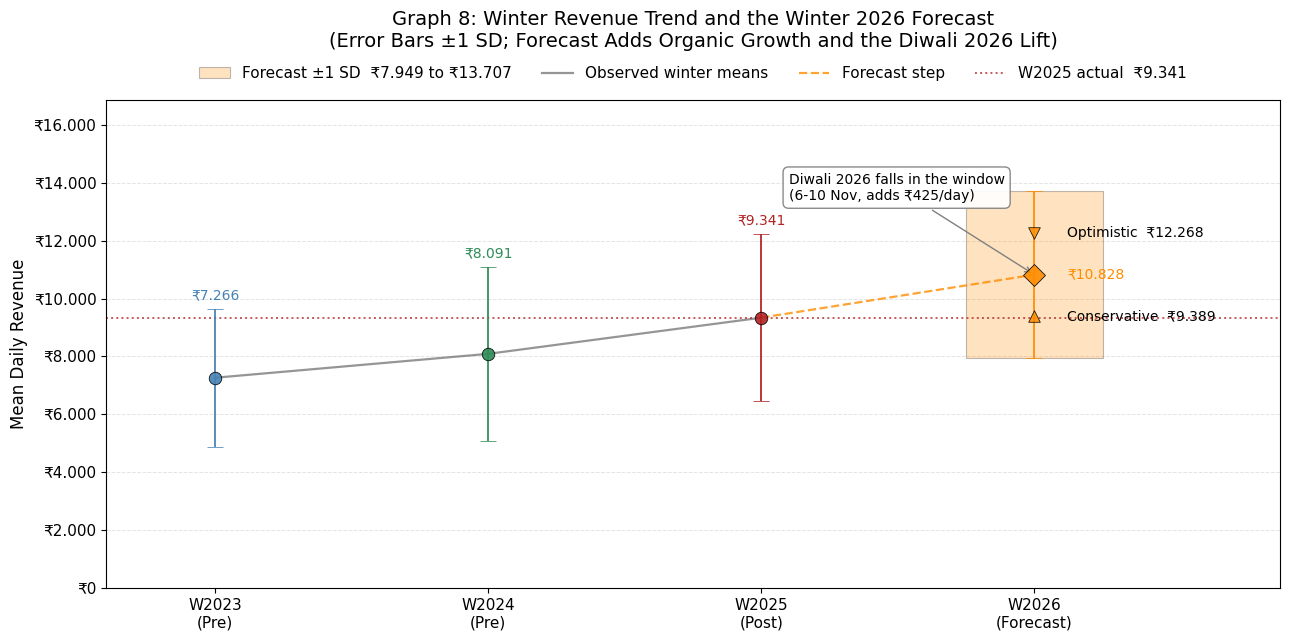


  GRAPH 8 INTERPRETATION

  This chart carries the three observed winters forward into a forecast for
  Winter 2026. The solid line joins the winters that actually happened, each
  with an error bar for its day-to-day spread, and the dashed step continues
  to the forecast point. The forecast is drawn in its own colour so it is not
  mistaken for an observed figure.

  The expected forecast is ₹10.828 per day, ₹1.487
  above the Winter 2025 actual. It is built in plain steps: start from the
  Winter 2025 mean, apply the pre-tandoor winter growth rate, then add the
  Diwali lift, because Diwali 2026 falls inside the winter window and Winter
  2025 had no festival days at all. The upward triangle and downward triangle
  mark the conservative and optimistic scenarios that flank it.

  The shaded band is what to plan cash flow against. It runs from
  ₹7.949 to ₹13.707 per day, a spread of
  ₹5.758, and its lower edge sits below the Winter 2025 actual.
  The band is the expected forecast g

In [218]:
# GRAPH 8
# Three observed winters as a rising line, a dashed step to the Winter 2026
# forecast, and a shaded band for the day-to-day spread, showing the forecast
# as a continuation of the observed trend with its uncertainty alongside.

# observed winter metrics (Sections 3, 5) and forecast figures from Section 8
g8_means    = [m_23_nd["mean"], m_24_nd["mean"], m_25["mean"], fc_expected]
g8_sds      = [m_23_nd["sd"],   m_24_nd["sd"],   m_25["sd"],   m_25["sd"]]
g8_band_low = band_lower
g8_band_high = band_upper
g8_fc_low   = fc_conservative
g8_fc_high  = fc_optimistic
g8_w2025    = m_25["mean"]
g8_diwali   = diwali_lift_per_day

g8_band_halfwidth = 0.25    # half-width (x units) of the shaded forecast band
g8_marker_size    = 9
g8_fc_marker_size = 11
g8_cap            = 6
g8_label_gap      = 230     # gap (₹) above a cap for the point's value label
g8_scenario_gap   = 0.12    # x offset for the conservative/optimistic labels
g8_top_pad        = 1.6     # multiples of SD of headroom above the top scenario

g8_positions = np.array([0, 1, 2, 3])
g8_labels    = ["W2023\n(Pre)", "W2024\n(Pre)", "W2025\n(Post)", "W2026\n(Forecast)"]
# one colour per winter, forecast in its own darkorange
g8_colours   = ["steelblue", "seagreen", "firebrick", "darkorange"]
g8_forecast  = [False, False, False, True]

fig, ax = plt.subplots(figsize=(13, 6.5))   # wide: the forecast note and scenario labels need room
ax.set_axisbelow(True)

# shaded band (expected plus/minus 1 SD) behind everything, at the forecast point only
ax.fill_between(
    [g8_positions[3] - g8_band_halfwidth, g8_positions[3] + g8_band_halfwidth],
    [g8_band_low, g8_band_low], [g8_band_high, g8_band_high],
    color="darkorange", alpha=0.25, edgecolor="black", linewidth=0.8, zorder=1,
    label="Forecast ±1 SD  ₹" + fmt(g8_band_low) + " to ₹" + fmt(g8_band_high),
)

# solid line through the three observed winters, dashed step out to the forecast
ax.plot(g8_positions[:3], g8_means[:3], color="dimgray", linewidth=1.6,
        alpha=0.7, zorder=2, label="Observed winter means")
ax.plot(g8_positions[2:], g8_means[2:], color="darkorange", linewidth=1.6,
        linestyle="--", alpha=0.8, zorder=2, label="Forecast step")

# each winter as a point with its plus/minus 1 SD error bar
for i in range(4):
    marker = "D" if g8_forecast[i] else "o"
    size   = g8_fc_marker_size if g8_forecast[i] else g8_marker_size
    ax.errorbar(g8_positions[i], g8_means[i], yerr=g8_sds[i], fmt=marker,
                color=g8_colours[i], markersize=size, markeredgecolor="black",
                markeredgewidth=0.6, capsize=g8_cap, capthick=1.4,
                elinewidth=1.4, ecolor=g8_colours[i], alpha=0.9, zorder=4)
    if g8_forecast[i]:
        # forecast label sits beside the diamond; the space above is used by the Diwali note
        ax.text(g8_positions[i] + g8_scenario_gap, g8_means[i],
                "₹" + fmt(g8_means[i]), ha="left", va="center",
                fontsize=10, color=g8_colours[i])
    else:
        ax.text(g8_positions[i], g8_means[i] + g8_sds[i] + g8_label_gap,
                "₹" + fmt(g8_means[i]), ha="center", va="bottom",
                fontsize=10, color=g8_colours[i])

# conservative and optimistic scenario markers flanking the expected forecast
ax.scatter(g8_positions[3], g8_fc_low,  marker="^", s=70, color="darkorange",
           edgecolor="black", linewidth=0.6, alpha=0.85, zorder=5)
ax.scatter(g8_positions[3], g8_fc_high, marker="v", s=70, color="darkorange",
           edgecolor="black", linewidth=0.6, alpha=0.85, zorder=5)
ax.text(g8_positions[3] + g8_scenario_gap, g8_fc_low,
        "Conservative  ₹" + fmt(g8_fc_low),
        va="center", fontsize=10, color="black")
ax.text(g8_positions[3] + g8_scenario_gap, g8_fc_high,
        "Optimistic  ₹" + fmt(g8_fc_high),
        va="center", fontsize=10, color="black")

# reference line at the W2025 actual mean, so the forecast reads against it
ax.axhline(g8_w2025, color="firebrick", linewidth=1.4, linestyle=":",
           alpha=0.75, zorder=2,
           label="W2025 actual  ₹" + fmt(g8_w2025))

# Diwali note: the one structural reason W2026 differs from W2025
ax.annotate(
    "Diwali 2026 falls in the window\n(6-10 Nov, adds ₹" + fmt(g8_diwali) + "/day)",
    xy=(g8_positions[3], g8_means[3]),
    xytext=(g8_positions[3] - 0.9, g8_means[3] + 0.9 * m_25["sd"]),
    fontsize=10, color="black",
    arrowprops=dict(arrowstyle="->", color="gray", lw=1.0),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
              edgecolor="gray", alpha=0.92),
)

ax.set_title(
    "Graph 8: Winter Revenue Trend and the Winter 2026 Forecast\n"
    "(Error Bars ±1 SD; Forecast Adds Organic Growth and the Diwali 2026 Lift)",
    fontsize=14, pad=38,
)
ax.set_ylabel("Mean Daily Revenue", fontsize=12)
ax.set_xticks(g8_positions)
ax.set_xticklabels(g8_labels, fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(rupee_axis))
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="y", alpha=0.35, linestyle="--", linewidth=0.7)
ax.set_xlim(-0.4, 3.9)
ax.set_ylim(0, g8_fc_high + g8_top_pad * m_25["sd"])

ax.legend(fontsize=11, framealpha=0.92,
          loc="lower center", bbox_to_anchor=(0.5, 1.01),
          ncol=4, frameon=False)

plt.tight_layout()
plt.savefig("graph8_winter2026_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

# gaps the prose needs, from the reused figures
g8_expected_gain = fc_expected - g8_w2025
g8_cons_gap      = g8_fc_low - g8_w2025
g8_band_span     = g8_band_high - g8_band_low

print()
print("=" * 77)
print("  GRAPH 8 INTERPRETATION")
print("=" *77)
print(f"""
  This chart carries the three observed winters forward into a forecast for
  Winter 2026. The solid line joins the winters that actually happened, each
  with an error bar for its day-to-day spread, and the dashed step continues
  to the forecast point. The forecast is drawn in its own colour so it is not
  mistaken for an observed figure.

  The expected forecast is ₹{fmt(fc_expected)} per day, ₹{fmt(g8_expected_gain)}
  above the Winter 2025 actual. It is built in plain steps: start from the
  Winter 2025 mean, apply the pre-tandoor winter growth rate, then add the
  Diwali lift, because Diwali 2026 falls inside the winter window and Winter
  2025 had no festival days at all. The upward triangle and downward triangle
  mark the conservative and optimistic scenarios that flank it.

  The shaded band is what to plan cash flow against. It runs from
  ₹{fmt(g8_band_low)} to ₹{fmt(g8_band_high)} per day, a spread of
  ₹{fmt(g8_band_span)}, and its lower edge sits below the Winter 2025 actual.
  The band is the expected forecast give or take one standard deviation of
  daily revenue, so it shows how much single days swing around the average,
  not how likely the season as a whole is to come in low. It does not include
  the separate uncertainty that comes from having only one post-tandoor winter
  to learn from; that limitation is in the text below. A manager should hold
  the lower edge as the cautious daily figure and treat the expected value as
  the target.

  The conservative scenario is only ₹{fmt(g8_cons_gap)} above the Winter 2025
  actual. It stays above only because the Diwali lift is near-certain by the
  calendar, while the growth it assumes is deliberately cautious. The forecast
  rests on a single post-tandoor winter, so it is a direction to plan around,
  not a promise. Winter 2026 is the first real test of whether the trend the
  line shows continues.
""")

In [219]:
# 8.6  Forecast Summary and Monitoring Plan

# thresholds are the conservative floor and optimistic ceiling themselves, so
# the decision rule is grounded in the forecast scenarios, not an arbitrary buffer
trigger_low  = fc_conservative
trigger_high = fc_optimistic

# vs-W2025 percentages for the summary table
vs_cons_86 = (fc_conservative - m_25["mean"]) / m_25["mean"] * 100
vs_exp_86  = (fc_expected     - m_25["mean"]) / m_25["mean"] * 100
vs_opt_86  = (fc_optimistic   - m_25["mean"]) / m_25["mean"] * 100

print()
print("  8.6  Forecast Summary and Monitoring Plan")
print("  " + "-" * 75)

print()
print("  TABLE 8.6  Winter 2026 Forecast: Final Summary")
print()
print(f"  {'Scenario':<24} {'Daily Mean':>14} {'Total Revenue':>18} {'vs W2025':>10}")
print("  " + "-" * 75)
print(f"  {'Conservative':<24} {'₹'+fmt(fc_conservative):>14} {'₹'+fmt(fc_total_conservative):>18} {('+' if vs_cons_86>=0 else '')+fmt(vs_cons_86,1)+'%':>10}")
print(f"  {'Expected':<24} {'₹'+fmt(fc_expected):>14} {'₹'+fmt(fc_total_expected):>18} {('+' if vs_exp_86>=0 else '')+fmt(vs_exp_86,1)+'%':>10}")
print(f"  {'Optimistic':<24} {'₹'+fmt(fc_optimistic):>14} {'₹'+fmt(fc_total_optimistic):>18} {('+' if vs_opt_86>=0 else '')+fmt(vs_opt_86,1)+'%':>10}")
print("  " + "-" * 75)
print(f"  {'W2025 actual (reference)':<24} {'₹'+fmt(m_25['mean']):>14} {'₹'+fmt(m_25['total']):>18} {'-':>10}")
print("  " + "-" * 75)

print(f"""
  Forecast totals use {PROJ_OP_DAYS_2026} projected operating days, the same
  count as Winter 2025 actual, so the Total Revenue column is like-for-like.

  Projected tandoor running cost (base case): ₹{fmt(proj_tandoor_cost_2026)}. All
  three scenarios generate enough daily revenue to cover this running cost (see
  the Section 8.5 break-even check). Covering the running cost is not the same
  as improving overall margin, as the profitability results in Sections 6.4 and
  6.5 show.

  Forecast limitations:

  1. Single post-intervention winter. The Winter 2025 mean is the only observed
     data point with the tandoor in full winter operation. One winter cannot
     reliably quantify between-year structural variance. The ±1 SD band
     captures within-season daily variation, not between-season risk.

  2. Organic growth assumption. The {('+' if observed_organic_growth >= 0 else '')}{fmt(observed_organic_growth*100, 1)}% pre-intervention growth
     rate (2023 to 2024) may not continue at the same pace. The summer reference
     ({('+' if summer_growth_yoy >= 0 else '')}{fmt(summer_growth_yoy, 1)}% year-on-year, Mar-May 2025 to 2026) suggests ongoing
     growth, but summer and winter demand profiles differ. If footfall growth
     accelerates, the expected scenario is conservative; if it slows, the
     expected scenario may be optimistic.

  3. Diwali premium stability. The average premium (₹{fmt(avg_premium)}/day) rests
     on two historical observations, 2023 and 2024. Festival revenue is
     sensitive to day-of-week positioning and local marketing; Diwali 2026 falls
     Thursday to Monday, which may differ from prior patterns.

  4. Demand saturation not modelled. The forecast assumes year-two tandoor demand
     keeps growing at the organic rate. If Winter 2025 captured most of the
     latent demand from existing customers, incremental growth in 2026 could be
     lower.

  Monitoring plan:

  The forecast is directly testable against November 2026 data. A two-week
  rolling mean in November 2026, compared against the conservative floor, gives
  the first usable signal.

  Early-review triggers:
    Below plan : daily rolling mean below ₹{fmt(trigger_low)}
                 (below the conservative floor; investigate demand or cost)
    Above plan : daily rolling mean above ₹{fmt(trigger_high)}
                 (above the optimistic ceiling; confirm data and document driver)

  Winter 2026 data will also allow a pooled post-intervention baseline
  (W2025 + W2026), which improves statistical power for any future sub-group
  analysis and reduces the dependence on the single-winter limitation noted in
  Sections 5.8 and 7.6.""")
print()

print("=" * 85)


  8.6  Forecast Summary and Monitoring Plan
  ---------------------------------------------------------------------------

  TABLE 8.6  Winter 2026 Forecast: Final Summary

  Scenario                     Daily Mean      Total Revenue   vs W2025
  ---------------------------------------------------------------------------
  Conservative                     ₹9.389         ₹1.098.469      +0,5%
  Expected                        ₹10.828         ₹1.266.901     +15,9%
  Optimistic                      ₹12.268         ₹1.435.333     +31,3%
  ---------------------------------------------------------------------------
  W2025 actual (reference)         ₹9.341         ₹1.092.940          -
  ---------------------------------------------------------------------------

  Forecast totals use 117 projected operating days, the same
  count as Winter 2025 actual, so the Total Revenue column is like-for-like.

  Projected tandoor running cost (base case): ₹124.460. All
  three scenarios generate enoug

## SECTION 9: CONCLUSION


In [220]:
# SECTION 9: CONCLUSION

print()
print("=" * 80)
print("  SECTION 9: CONCLUSION")
print("=" * 80)
print("""  This section brings the whole analysis to a single decision. It scores
  the tandoor intervention across seven criterion, each with its own evidence
  and a categorical verdict, reads the overall result from the pattern of those
  verdicts, then states the limitations of the study and what the owner should
  do next.""")


# 9.1  Decision Matrix

print()
print("  9.1  Decision Matrix: Seven Evaluation Criterion")
print("  " + "-" * 80)
print("""  The matrix covers seven criterion that together decide whether the
  tandoor was worth it: statistical credibility, economic impact, breadth of
  improvement, operational stability, profitability, forward viability, and
  closure of the seasonal gap. Each has a defined evidence base and a
  categorical verdict. The overall verdict follows from the pattern of the
  seven, not from a weighted average.

  Verdicts are defined as:
    HIT         : evidence clearly supports this criterion
    PARTIAL HIT : clear improvement, but not the full result
    PARTIAL     : moved against the aim, but the outcome is still acceptable
    MISS        : evidence does not support this criterion""")

print()
print("  TABLE 9.1  Intervention Decision Matrix")
print()
print(f"  {'#':<3} {'Criterion':<24} {'Key Evidence':<48} {'Section':>8} {'Verdict':>12}")
print("  " + "-" * 100)

# Row 1: Statistical Significance
row1_evidence = f"p {p_value_str(ttest_main_pval)} (t & MW), d = {fmt(cohens_d_main, 2)}"
print(f"  {'1':<3} {'Statistical Significance':<24} {row1_evidence:<48} {'Sec 5':>8} {'HIT':>12}")

# Row 2: Revenue Impact
row2_evidence = f"+{fmt(mean_pct, 1)}% mean, +₹{fmt(mean_diff_main)}/day"
print(f"  {'2':<3} {'Revenue Impact':<24} {row2_evidence:<48} {'Sec 5-6':>8} {'HIT':>12}")

# Row 3: Jan-Feb Weak Season
jf_p_display = p_value_str(ttest_janfeb_pval)
jf_p_text = jf_p_display if jf_p_display.startswith("<") else "= " + jf_p_display
row3_evidence = f"d = {fmt(cohens_d_janfeb, 2)}, both tests p {jf_p_text}"
print(f"  {'3':<3} {'Jan-Feb Weak Season':<24} {row3_evidence:<48} {'Sec 5.7':>8} {'HIT':>12}")

# Row 4: Revenue Stability (CV change)
row4_evidence = f"CV {fmt(m_comb['cv'], 1)}% to {fmt(m_25['cv'], 1)}% (-{fmt(abs(cv_diff), 1)}pp)"
print(f"  {'4':<3} {'Revenue Stability (CV)':<24} {row4_evidence:<48} {'Sec 4-6':>8} {'HIT':>12}")

# Row 5: Profit Margin (fell 2024 to 2025 on tandoor running cost; no improvement, but not a loss)
row5_evidence = f"Margin {fmt(profit_data['2024']['margin'], 1)}% to {fmt(profit_data['2025']['margin'], 1)}% ({('+' if margin_gain_2425>=0 else '')}{fmt(margin_gain_2425, 1)}pp)"
print(f"  {'5':<3} {'Profit Margin':<24} {row5_evidence:<48} {'Sec 6':>8} {'PARTIAL':>12}")

# Row 6: Winter 2026 Viability
row6_evidence = f"Exp. ₹{fmt(fc_expected)}/day, all 3 scenarios cover costs"
print(f"  {'6':<3} {'Winter 2026 Viability':<24} {row6_evidence:<48} {'Sec 8':>8} {'HIT':>12}")

# Row 7: Seasonal Gap Closure (narrowed but not closed; clear improvement, incomplete)
row7_evidence = f"Gap {fmt(gap_pooled, 1)}% to {fmt(gap_2025, 1)}% (-{fmt(abs(gap_narrowing), 1)}pp)"
print(f"  {'7':<3} {'Seasonal Gap Closure':<24} {row7_evidence:<48} {'Sec 4.5':>8} {'PARTIAL HIT':>12}")

print("  " + "-" * 100)

# count verdicts for the summary line
verdicts = ["HIT", "HIT", "HIT", "HIT", "PARTIAL", "HIT", "PARTIAL HIT"]
hits         = verdicts.count("HIT")
partial_hits = verdicts.count("PARTIAL HIT")
partials     = verdicts.count("PARTIAL")
misses       = verdicts.count("MISS")

print(f"""
  Summary: {hits} HIT, {partial_hits} PARTIAL HIT, {partials} PARTIAL, {misses} MISS

  Overall verdict: PARTIAL HIT.

  Five of seven criterion return a HIT, all on the revenue and stability
  side: the rise is significant, medium in size, holds in January-February,
  steadies the day-to-day swing, and the 2026 forecast covers its costs. The
  other two fall on the profit side, and they are not the same. The seasonal
  gap narrowed but did not close, so it is a partial hit. The profit margin did
  not rise against last year, so it is a plain partial, though not a miss.

  Profit margin is a partial rather than a miss. Net profit fell and the margin
  dropped by {fmt(abs(margin_gain_2425), 1)} percentage points as the tandoor's
  running cost (₹{fmt(tandoor_cost_2025)} for Winter 2025) entered the expense
  base for the first time. The margin went the wrong way, so it is not a hit of
  any kind. But the business still made money overall, so it is not a miss
  either.

  The seasonal gap is the partial hit. Before the tandoor, winter ran
  {fmt(gap_pooled, 1)}% below the rest of the year (Section 4.5); in Winter 2025
  that gap narrowed to {fmt(gap_2025, 1)}%, a drop of {fmt(abs(gap_narrowing), 1)}
  percentage points. The gap moved the right way and the weakest days rose most,
  but the winter is still well below the rest of the year, so the problem is
  smaller, not solved.

  Whether the trade-off is acceptable depends on the owner's priorities: if
  stable, higher revenue was the goal (as stated when activating the tandoor),
  the intervention succeeded; if keeping the pre-tandoor margin was the goal, it
  has not yet done so.""")
print()


# 9.2  Limitations

print()
print("  9.2  Limitations")
print("  " + "-" * 75)
print(f"""  The findings should be read with three limitations in mind.

  One post-intervention winter. Winter 2025 is a single season (n = 1). The
  tests measure a real difference in daily revenue, but one winter cannot
  separate the tandoor from a year that may have been strong for other reasons.
  A second post-intervention winter would raise n from 1 to 2 and allow a
  firmer statement.

  The rise might not be all tandoor. Section 7 shows the jump in Winter 2025 is
  bigger than the normal year-to-year growth, so it is not just the usual climb.
  But we cannot be sure the tandoor food is the only reason. The tandoor sat at
  the entrance where people passing by could see it, so some of the rise may
  come from the new counter catching attention, not the food itself. Other
  business or local market changes that year, which this study did not track,
  could also have played a part. So the tandoor is likely the main reason, but
  with one winter we cannot say it is the only one.

  The net figure rests on an assumption. The net effect of ₹{fmt(net_tandoor_effect)}
  treats the extra revenue as the tandoor's. Given the test results this is
  reasonable, but it is the same assumption named in Section 6 carried into the
  final number, not a measured fact.""")
print()


# 9.3  Recommendations

print()
print("  9.3  Recommendations")
print("  " + "-" * 80)
print(f"""  Three steps follow from the analysis.

  Keep the tandoor running and watch the margin. Across the full winter, the
  business still made a profit. The margin fell this year mainly because the
  tandoor's running cost, the coal and the chef's salary, was added to the
  expenses for the first time. This cost stays in future winters, so the margin
  will not recover on the cost side. What can lift it is revenue: Winter 2025
  was the tandoor's first season, and as more customers get used to it, revenue
  may grow while the running cost stays about the same. Check in Winter 2026
  whether the margin rises for that reason, once the tandoor is established
  rather than new.

  Test the forecast against reality. Winter 2026 is projected at about
  ₹{fmt(fc_expected)} per day. Compare a two-week rolling mean in November 2026
  against that figure early, so a shortfall is caught in weeks rather than at
  season end.

  Re-run this study after Winter 2026. A second post-intervention winter would
  move the analysis from n = 1 to n = 2, test whether the Jan-Feb weak season
  improves on the profit side once activation costs fall away, and confirm or
  revise the seasonal-gap result.""")
print()

print("=" * 80)


  SECTION 9: CONCLUSION
  This section brings the whole analysis to a single decision. It scores
  the tandoor intervention across seven criterion, each with its own evidence
  and a categorical verdict, reads the overall result from the pattern of those
  verdicts, then states the limitations of the study and what the owner should
  do next.

  9.1  Decision Matrix: Seven Evaluation Criterion
  --------------------------------------------------------------------------------
  The matrix covers seven criterion that together decide whether the
  tandoor was worth it: statistical credibility, economic impact, breadth of
  improvement, operational stability, profitability, forward viability, and
  closure of the seasonal gap. Each has a defined evidence base and a
  categorical verdict. The overall verdict follows from the pattern of the
  seven, not from a weighted average.

  Verdicts are defined as:
    HIT         : evidence clearly supports this criterion
    PARTIAL HIT : clear imp